# 中国期货：1亿元本金与单品种敞口上限

使用2026-09-07的v2审核数据、1亿元人民币、16%风险目标，比较carry、breakout、50/50 mixed和六档敞口设计：无上限、10%、20%、30%、3/N、min(50%,3/N)，共18组原生System。

本报告聚焦敞口限制、逐品种贡献、容量和区间统计。早期本金与数据版本对照已归档。波动率下限从本目录的独立配置CSV读取。当前1亿元结果、参数与图表保留。

历史流动性区间和5%低波动筛选均属于事后研究。数据说明见[数据审理](chinese_futures_data_review.ipynb)，风险匹配与40% carry见[专题报告](carry40_breakout_comparison.ipynb)。

In [102]:
%matplotlib inline
import gc
import hashlib
import logging
import time
import warnings
from copy import deepcopy
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits

from syscore.constants import arg_not_supplied
from syscore.dateutils import BUSINESS_DAYS_IN_YEAR
from sysdata.config.configdata import Config
from sysdata.data_blob import dataBlob
from sysdata.sim.db_futures_sim_data import dbFuturesSimData, use_sim_classes
from sysobjects.adjusted_prices import futuresAdjustedPrices
from sysobjects.multiple_prices import futuresMultiplePrices
from syslogging.logger import get_logger

get_logger('carry_breakout_portfolio_research')
logging.getLogger().setLevel(logging.WARNING)
threadpool_limits(limits=1)
PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/'sysdata').is_dir() and (p/'examples/chinese_futures').is_dir())
RESEARCH_CONFIG = PROJECT/'examples/chinese_futures/config'
AS_OF = '2026-09-07'
CUTOFF = pd.Timestamp(AS_OF) + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
AUDIT_ROOT = PROJECT / 'private/research_runs/carry_breakout_native_2026-09-07'
RUN_ROOT = AUDIT_ROOT / 'portfolio_capital_100m'
RUN_ROOT.mkdir(parents=True, exist_ok=True)
(RUN_ROOT / 'figures').mkdir(exist_ok=True)
DATA_ROOT = AUDIT_ROOT / 'v2_inputs'
WORK_PARQUET = DATA_ROOT / 'parquet'
CAPITAL = 100_000_000.
ANNUAL_DAYS = BUSINESS_DAYS_IN_YEAR
VOL_TARGET = 16.
CASES = ['carry', 'breakout', 'mixed']
CAPS = {'unlimited': None, 'cap10': .10, 'cap20': .20, 'cap30': .30,
        'equal3': '3/N', 'bounded3': 'min(50%,3/N)'}
CAP_LABELS = {'unlimited': '无上限', 'cap10': '10% 上限', 'cap20': '20% 上限',
              'cap30': '30% 上限', 'equal3': '3/N', 'bounded3': 'min(50%,3/N)'}
mapping = pd.read_csv(PROJECT / 'sysdata/tushare/config/futures_instruments.csv')
instruments = sorted(mapping.loc[mapping.StitchMode.eq('stitch'), 'Instrument'])
assert len(instruments) == 95
VOL_FLOOR_POINTS = pd.read_csv(RESEARCH_CONFIG/'vol_floor_points.csv', index_col='Instrument').vol_floor_points.to_dict()
assert np.isclose(VOL_FLOOR_POINTS['DCE_FB'], 4.25)
plt.style.use('default')
plt.rcParams.update({'figure.dpi':100, 'axes.grid':True, 'grid.alpha':.22,
                     'legend.frameon':False, 'font.size':10})
from matplotlib import font_manager
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for name in ['Arial Unicode MS','PingFang SC','Heiti TC','STHeiti']:
    if name in available_fonts:
        plt.rcParams['font.family'] = name
        break
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',30)
pd.set_option('display.float_format','{:,.4f}'.format)
print('固定截止日', AS_OF, '；每组资金', f'{CAPITAL:,.0f}', '人民币；18 组原生组合。')
assert (DATA_ROOT/'volume_diagnostics.parquet').is_file(), '需要2026-09-07冻结输入；准备方法见本目录README。'

固定截止日 2026-09-07 ；每组资金 100,000,000 人民币；18 组原生组合。


## 1. 数据入口与历史边界

日常更新调用 `update_tushare_futures()`，单品种补取传入代码和日期。它完成 Tushare 单合约日线入 Parquet、合约信息入 MongoDB、日历核验、multiple prices 和加法复权价格更新。

本报告读取已保存的更新与审理结果。每个活跃区间独立计算波动率、carry 和 breakout 并重新预热；区间之间保持空仓。已结束区间在最后有成交报价处平仓，保留费用与边界证据。这是明确的历史研究假设。

表中的 `carry_missing_days` 表示：已有该日 PRICE 报价，但 CARRY 报价、合约标识或期限组合不足以计算有效 carry 的观察日数。交易所休市日不计入这个数量。它会影响三组策略共同的当日资格，具体日期及合约证据保存在数据审理结果中。

In [69]:
trading_windows = pd.read_csv(DATA_ROOT/'trading_windows.csv', parse_dates=['Start','End'])
trading_windows = trading_windows.dropna(subset=['Start','End']).copy()
review = pd.read_csv(DATA_ROOT/'instrument_review.csv')
assert set(trading_windows.Instrument).issubset(instruments)
assert trading_windows.End.le(pd.Timestamp(AS_OF)).all()
display(review)
display(trading_windows)
print('已审核活跃区间', len(trading_windows), '；原始单合约与旧结果保存在恢复副本中。')
# 固定输入内容；运行结束再次核对，防止研究期间混入新版本。
input_files = sorted(WORK_PARQUET.rglob('*.parquet'))
input_files += [DATA_ROOT/name for name in ['rollconfig.csv','trading_windows.csv',
                'instrument_review.csv','volume_diagnostics.parquet','episode_boundaries.csv']]
input_hashes = {str(path):hashlib.sha256(path.read_bytes()).hexdigest() for path in input_files}
pd.Series(input_hashes,name='sha256').to_csv(RUN_ROOT/'frozen_input_hashes.csv',index_label='path')

,Instrument,Description,Status,Intervals,ObservedRows,UsableRows,RemovedRows,PriceStart,PriceEnd,Start,End,WholeHeldMedian,TailHeldMedian,ZeroVolumeFraction,CarryZeroOrMissingFraction,RollStatus,BeforeWeakSelectedDays,WeakSelectedDays,RelativeBelow1pctDays,HeldPriorADVP05,ProductWeakExcludedRows,SelectedContractWeakExcludedRows,InactiveObservedRows
0,CFFEX_IC,中金所中证五百股指,保留单段历史,1,2751,2751,0,2015-05-18,2026-09-07,2015-05-18,2026-09-07,"43,404.0000","47,848.5000",0.0000,0.0331,逐品种检查后保留已审核链,0,0,0,"3,748.7250",0,0,0
1,CFFEX_IF,中金所沪深三百股指,保留单段历史,1,3961,3961,0,2010-05-19,2026-09-07,2010-05-19,2026-09-07,"71,487.0000","40,289.5000",0.0000,0.0323,逐品种检查后保留已审核链,0,0,0,"6,018.8375",0,0,0
2,CFFEX_IH,中金所上证五十股指,保留单段历史,1,2751,2751,0,2015-05-18,2026-09-07,2015-05-18,2026-09-07,"26,385.0000","18,559.0000",0.0000,0.0331,逐品种检查后保留已审核链,0,0,0,"2,380.6500",0,0,0
3,CFFEX_IM,中金所中证一千股指,保留单段历史,1,982,982,0,2022-08-19,2026-09-07,2022-08-19,2026-09-07,"51,572.5000","68,842.5000",0.0000,0.0458,逐品种检查后保留已审核链,0,0,0,"11,633.6275",0,0,0
4,CFFEX_T,中金所十年期国债,保留单段历史,1,2683,2683,0,2015-08-21,2026-09-07,2015-08-21,2026-09-07,"51,740.0000","81,225.5000",0.0000,0.0011,逐品种检查后保留已审核链,0,0,0,"12,586.2650",0,0,0
5,CFFEX_TF,中金所五年期国债,保留单段历史,1,3113,3113,0,2013-11-21,2026-09-07,2013-11-21,2026-09-07,"17,874.0000","63,213.0000",0.0000,0.0206,逐品种检查后保留已审核链,0,0,0,"1,816.9200",0,0,0
6,CFFEX_TL,中金所三十年期国债,保留单段历史,1,798,798,0,2023-05-26,2026-09-07,2023-05-26,2026-09-07,"62,744.5000","96,190.5000",0.0000,0.0000,逐品种检查后保留已审核链,0,0,0,"10,322.7200",0,0,0
7,CFFEX_TS,中金所两年期国债,保留单段历史,1,1888,1768,120,2018-11-27,2026-09-07,2019-05-29,2026-09-07,"21,668.5000","34,370.0000",0.0000,0.0434,逐品种检查后保留已审核链,0,0,0,"3,552.7625",0,120,120
8,CZCE_AP,郑商所苹果,保留单段历史,1,2020,2020,0,2018-05-16,2026-09-07,2018-05-16,2026-09-07,"33,715.0000","26,354.5000",0.0000,0.0099,逐品种检查后保留已审核链,0,0,24,"2,277.9350",0,0,0
9,CZCE_CF,郑商所棉花,保留单段历史,1,5258,5258,0,2005-01-18,2026-09-07,2005-01-18,2026-09-07,"134,954.5000","289,455.5000",0.0000,0.0011,v2已修复,64,0,11,"2,288.1600",0,0,0


,Instrument,Start,End,Reason,ReviewDate
0,CFFEX_IC,2015-05-18,2026-09-07,已审核可用历史,2026-09-07
1,CFFEX_IF,2010-05-19,2026-09-07,已审核可用历史,2026-09-07
2,CFFEX_IH,2015-05-18,2026-09-07,已审核可用历史,2026-09-07
3,CFFEX_IM,2022-08-19,2026-09-07,已审核可用历史,2026-09-07
4,CFFEX_T,2015-08-21,2026-09-07,已审核可用历史,2026-09-07
...,...,...,...,...,...
105,SHFE_SN,2015-07-16,2026-09-07,修正持有月份后按同合约滞后20观察成交量重新审理；全历史事后政策,2026-09-07
106,SHFE_SP,2019-06-13,2026-09-07,修正持有月份后按同合约滞后20观察成交量重新审理；全历史事后政策,2026-09-07
107,SHFE_SS,2020-02-14,2026-09-07,修正持有月份后按同合约滞后20观察成交量重新审理；全历史事后政策,2026-09-07
108,SHFE_WR,2009-09-14,2010-10-11,独立原生价格片段；真实正成交起止；无可靠换月重叠处保留资格空白,2026-09-07


已审核活跃区间 108 ；原始单合约与旧结果保存在恢复副本中。


## 2. 固定参数与区间内预热

周期、固定 scalars、价格点波动率下限及成本沿用上一轮。IDM 使用周收益、每周扩展历史估计、指数窗口 25 周和至少 20 周观察，清理相关性并将负相关截到零；平滑 125 个业务日，最大 2.5。

每个审核区间使用独立原生 System 计算七条规则和波动率。N 使用同日共同合格品种数；没有合格品种时保持现金。实际资金、成交延迟、整手和 buffer 均通过原生账户计算。

将单品种名义敞口除以总资本，再除以 1/N，得到每份等额资本的名义倍数。将这个倍数限制为 3，对应上限 3/N：N=1、5、20 时，单品种上限分别为 300%、60%、15%。因此，N 较少时仍可能高度集中。min(50%,3/N) 将单品种上限再限制到 50%；N≥6 时两种设计完全相同。

这些上限规定名义金额。各品种风险仍由波动率、信号、等风险权重和 IDM 共同决定；同样的名义金额可能对应不同的价格风险。六档参数在读取研究结果前固定，通过共同期间及五年分段比较。

In [70]:
from sysdata.sim.db_futures_sim_data import use_sim_classes
from systems.basesystem import System
from systems.accounts.accounts_stage import Account
from systems.portfolio import Portfolios
from systems.positionsizing import PositionSizing
from systems.rawdata import RawData
from systems.forecast_combine import ForecastCombine
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecasting import Rules
from systems.system_cache import output, diagnostic
from systems.provided.rules.carry import carry
from systems.provided.rules.breakout import breakout
from sysquant.estimators.vol import mixed_vol_calc

class ResearchData(dbFuturesSimData):
    def __init__(self, windows=arg_not_supplied, end=None):
        self.cutoff = CUTOFF if end is None else pd.Timestamp(end)
        selected = trading_windows if windows is arg_not_supplied else windows
        super().__init__(data=dataBlob(class_list=list(use_sim_classes.values()),
                         parquet_store_path=str(WORK_PARQUET), log_name='portfolio_data',
                         csv_data_paths={'csvRollParametersData':str(DATA_ROOT),
                                         'csvFuturesInstrumentData':str(PROJECT/'data/futures/csvconfig')}),
                         trading_windows=arg_not_supplied if selected is None else selected)

    def get_backadjusted_futures_price(self, instrument_code):
        return futuresAdjustedPrices(super().get_backadjusted_futures_price(instrument_code).loc[:self.cutoff].copy())

    def get_multiple_prices_from_start_date(self, instrument_code, start_date):
        return futuresMultiplePrices(super().get_multiple_prices_from_start_date(instrument_code, start_date).loc[:self.cutoff].copy())

def warmed_breakout(price, lookback=80):
    return breakout(price, lookback=lookback).where(price.notna().cumsum() >= int(np.ceil(lookback / 2)))

class WindowRawData(RawData):
    @output()
    def daily_returns_volatility(self, instrument_code):
        return super().daily_returns_volatility(instrument_code).clip(lower=self.config.vol_floor_points[instrument_code])

RULES = {
    'carry10': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 10}},
    'carry30': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 30}},
    'carry60': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 60}},
    'carry125': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 125}},
    'breakout40': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 40}},
    'breakout80': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 80}},
    'breakout160': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 160}},
}
SCALARS = {'carry10': 27.815707053556984, 'carry30': 28.384062881349813,
           'carry60': 28.40072429176199, 'carry125': 29.366474500729886,
           'breakout40': .7036929411910525, 'breakout80': .726260784624834, 'breakout160': .7388310187414805}
WEIGHTS = {
    'carry': {'carry10': .25, 'carry30': .25, 'carry60': .25, 'carry125': .25},
    'breakout': {'breakout40': 1/3, 'breakout80': 1/3, 'breakout160': 1/3},
    'mixed': {'carry10': .125, 'carry30': .125, 'carry60': .125, 'carry125': .125,
              'breakout40': 1/6, 'breakout80': 1/6, 'breakout160': 1/6},
}
BASE_CONFIG = {
    'forecast_scalars': SCALARS, 'forecast_cap': 20., 'forecast_div_multiplier': 1.,
    'use_forecast_scale_estimates': False, 'use_forecast_weight_estimates': False,
    'use_forecast_div_mult_estimates': False, 'forecast_weight_ewma_span': 1,
    'forecast_post_ceiling_cost_SR': 999999,
    'notional_trading_capital': CAPITAL, 'percentage_vol_target': VOL_TARGET, 'base_currency': 'CNH',
    'capital_multiplier': {'func': 'syscore.capital.full_compounding'},
    'instrument_div_multiplier': 1., 'instrument_weight_ewma_span': 1,
    'use_instrument_weight_estimates': False, 'use_instrument_div_mult_estimates': True,
    'instrument_correlation_estimate': {
        'func': 'sysquant.estimators.correlation_over_time.correlation_over_time_for_returns',
        'frequency': 'W', 'date_method': 'expanding', 'interval_frequency': 'W',
        'using_exponent': True, 'ew_lookback': 25, 'min_periods': 20,
        'cleaning': True, 'rollyears': 20, 'floor_at_zero': True, 'forward_fill_price_index': True,
    },
    'instrument_div_mult_estimate': {
        'func': 'sysquant.estimators.diversification_multipliers.diversification_multiplier_from_list',
        'ewma_span': 125, 'dm_max': 2.5,
    },
    'buffer_method': 'forecast', 'buffer_size': .10, 'buffer_trade_to_edge': True,
    'use_SR_costs': False, 'vol_normalise_currency_costs': False, 'multiply_roll_costs_by': .5,
    'volatility_calculation': {
        'func': 'sysquant.estimators.vol.mixed_vol_calc',
        'name_returns_attr_in_rawdata': 'daily_returns', 'multiplier_to_get_daily_vol': 1.,
        'days': 35, 'min_periods': 10, 'slow_vol_years': 20,
        'proportion_of_slow_vol': .35, 'vol_abs_min': 0., 'backfill': False,
    },
}
BASE_CONFIG['vol_floor_points'] = deepcopy(VOL_FLOOR_POINTS)
assert all(np.isclose(sum(w.values()), 1) for w in WEIGHTS.values())
display(pd.DataFrame(WEIGHTS).fillna(0).join(pd.Series(SCALARS, name='scalar')))

,carry,breakout,mixed,scalar
carry10,0.2500,0.0000,0.1250,27.8157
carry30,0.2500,0.0000,0.1250,28.3841
carry60,0.2500,0.0000,0.1250,28.4007
carry125,0.2500,0.0000,0.1250,29.3665
breakout40,0.0000,0.3333,0.1667,0.7037
breakout80,0.0000,0.3333,0.1667,0.7263
breakout160,0.0000,0.3333,0.1667,0.7388


In [71]:
# 每个审核区间使用独立的原生数据、波动率与规则阶段，恢复后重新预热。
data = ResearchData()
raw_data = ResearchData(windows=None)
metadata = raw_data.get_all_instrument_data_as_df().reindex(instruments)
market, raw_rule_frames, coverage_rows, window_rows = {}, {}, [], []
for code in instruments:
    complete = pd.DataFrame(raw_data.get_multiple_prices(code)).resample('B').last()
    full_index = complete.index
    pieces, forecasts = [], []
    intervals = trading_windows.loc[trading_windows.Instrument.eq(code)]
    for number, (_, window) in enumerate(intervals.iterrows(), 1):
        one_window = pd.DataFrame([window])
        cfg = Config(deepcopy(BASE_CONFIG))
        cfg.instruments = [code]
        cfg.trading_rules = deepcopy(RULES)
        local = System([WindowRawData(), Rules()], ResearchData(windows=one_window), cfg)
        multiple = pd.DataFrame(local.data.get_multiple_prices(code)).resample('B').last()
        if multiple.PRICE.count() == 0:
            local.data.data.close()
            continue
        adjusted = local.rawdata.get_daily_prices(code)
        returns = local.rawdata.daily_returns(code)
        raw_vol = mixed_vol_calc(returns, days=35, min_periods=10, slow_vol_years=20,
                                  proportion_of_slow_vol=.35, vol_abs_min=0., backfill=False)
        used_vol = local.rawdata.daily_returns_volatility(code)
        pd.testing.assert_series_equal(used_vol, raw_vol.clip(lower=VOL_FLOOR_POINTS[code]), check_names=False)
        price = multiple.PRICE.ffill()
        observed = multiple.PRICE.notna()
        valid_carry = (multiple.PRICE.notna() & multiple.CARRY.notna()
                       & multiple.PRICE_CONTRACT.notna() & multiple.CARRY_CONTRACT.notna()
                       & multiple.PRICE_CONTRACT.ne(multiple.CARRY_CONTRACT))
        # 交易所休市日沿用区间内的上一输入，实际缺失 carry 的报价日仍标记缺失。
        carry_available = valid_carry.where(observed).ffill().fillna(False).astype(bool)
        piece = pd.DataFrame({'price':price, 'adjusted_price':adjusted, 'returns':returns,
                    'observed':observed, 'raw_vol_points':raw_vol, 'used_vol_points':used_vol,
                    'raw_vol_pct':100*raw_vol/price.abs()*np.sqrt(ANNUAL_DAYS),
                    'used_vol_pct':100*used_vol/price.abs()*np.sqrt(ANNUAL_DAYS),
                    'carry_available':carry_available, 'window':number})
        raw = pd.concat({name:local.rules.get_raw_forecast(code,name) for name in RULES},axis=1)
        pieces.append(piece)
        forecasts.append(raw)
        window_rows.append({'instrument':code,'window':number,'start':piece.index.min(),
            'end':piece.index.max(),'observed_days':int(observed.sum()),
            'first_all_rules':raw.dropna().index.min(),'first_vol':raw_vol.first_valid_index()})
        local.data.data.close()
    columns = ['price','adjusted_price','returns','observed','raw_vol_points','used_vol_points',
               'raw_vol_pct','used_vol_pct','carry_available','window']
    frame = pd.concat(pieces).reindex(full_index) if pieces else pd.DataFrame(index=full_index,columns=columns)
    frame[['observed','carry_available']] = frame[['observed','carry_available']].fillna(False).astype(bool)
    market[code] = frame
    raw_rule_frames[code] = pd.concat(forecasts).reindex(full_index) if forecasts else pd.DataFrame(index=full_index,columns=RULES,dtype=float)
    sample_vol = pd.to_numeric(frame.loc[frame.observed,'raw_vol_pct']).dropna()
    cost = data.get_raw_cost_data(code)
    decision = '低波动剔除' if len(sample_vol) and sample_vol.median()<5 else '纳入候选'
    if intervals.empty:
        decision = '无活跃区间'
    elif len(sample_vol)==0 or not np.isfinite(sample_vol).all():
        decision = '数据不足'
    coverage_rows.append({'instrument':code,'description':metadata.loc[code,'Description'],
        'first':frame.adjusted_price.first_valid_index(),'last':frame.adjusted_price.last_valid_index(),
        'observed_days':int(frame.observed.sum()),'stored_price_days':int(complete.PRICE.count()),
        'windows':len(intervals),'raw_vol_median_pct':sample_vol.median(),
        'vol_floor_points':VOL_FLOOR_POINTS[code], 'point_size':metadata.loc[code,'Pointsize'],
        'currency':metadata.loc[code,'Currency'],'carry_missing_days':int((frame.observed & ~frame.carry_available).sum()),
        'slippage_points':cost.price_slippage,'commission_per_contract':cost.value_of_block_commission,
        'commission_bps':cost.percentage_cost*10_000,'commission_per_trade':cost.value_of_pertrade_commission,
        'decision':decision})
coverage = pd.DataFrame(coverage_rows).set_index('instrument')
window_check = pd.DataFrame(window_rows)
screened = coverage.index[coverage.decision.eq('纳入候选')].tolist()
excluded_low_vol = coverage.index[coverage.decision.eq('低波动剔除')].tolist()
window_check.to_csv(RUN_ROOT/'window_warmup.csv',index=False)
display(coverage)
display(window_check)
print('原生读取与区间内规则计算完成；价格差和预热均在各区间内计算。')

,description,first,last,observed_days,stored_price_days,windows,raw_vol_median_pct,vol_floor_points,point_size,currency,carry_missing_days,slippage_points,commission_per_contract,commission_bps,commission_per_trade,decision
instrument,,,,,,,,,,,,,,,,
CFFEX_IC,中金所中证五百股指,2015-05-18,2026-09-07,2751,2751,1,23.2592,27.4950,200.0000,CNH,91,0.1000,0.0000,0.0000,0,纳入候选
CFFEX_IF,中金所沪深三百股指,2010-05-19,2026-09-07,3961,3961,1,18.9065,8.7025,300.0000,CNH,128,0.1000,0.0000,0.0000,0,纳入候选
CFFEX_IH,中金所上证五十股指,2015-05-18,2026-09-07,2751,2751,1,18.0899,9.2794,300.0000,CNH,91,0.1000,0.0000,0.0000,0,纳入候选
CFFEX_IM,中金所中证一千股指,2022-08-19,2026-09-07,982,982,1,20.4338,22.4575,200.0000,CNH,45,0.1000,0.0000,0.0000,0,纳入候选
CFFEX_T,中金所十年期国债,2015-08-21,2026-09-07,2683,2683,1,3.1184,0.2985,"10,000.0000",CNH,0,0.0025,0.0000,0.0000,0,低波动剔除
CFFEX_TF,中金所五年期国债,2013-11-21,2026-09-07,3113,3113,1,2.1720,0.2874,"10,000.0000",CNH,0,0.0025,0.0000,0.0000,0,低波动剔除
CFFEX_TL,中金所三十年期国债,2023-05-26,2026-09-07,798,798,1,5.5705,0.3025,"10,000.0000",CNH,0,0.0050,0.0000,0.0000,0,纳入候选
CFFEX_TS,中金所两年期国债,2019-05-29,2026-09-07,1768,1888,1,0.7716,0.3125,"20,000.0000",CNH,0,0.0010,0.0000,0.0000,0,低波动剔除
CZCE_AP,郑商所苹果,2018-05-16,2026-09-07,2020,2020,1,23.7019,29.9969,10.0000,CNH,5,0.5000,0.0000,0.0000,0,纳入候选


,instrument,window,start,end,observed_days,first_all_rules,first_vol
0,CFFEX_IC,1,2015-05-18,2026-09-07,2751,2015-10-13,2015-06-01
1,CFFEX_IF,1,2010-05-19,2026-09-07,3961,2010-10-19,2010-06-02
2,CFFEX_IH,1,2015-05-18,2026-09-07,2751,2015-10-13,2015-06-01
3,CFFEX_IM,1,2022-08-19,2026-09-07,982,2023-01-13,2022-09-02
4,CFFEX_T,1,2015-08-21,2026-09-07,2683,2016-01-18,2015-09-04
...,...,...,...,...,...,...,...
103,SHFE_SN,1,2015-07-16,2026-09-07,2709,2015-12-10,2015-07-30
104,SHFE_SP,1,2019-06-13,2026-09-07,1758,2019-11-06,2019-06-27
105,SHFE_SS,1,2020-02-14,2026-09-07,1595,2020-07-09,2020-02-28
106,SHFE_WR,1,2009-09-14,2010-10-11,256,2010-02-08,2009-09-28


原生读取与区间内规则计算完成；价格差和预热均在各区间内计算。


In [72]:
INDEX = pd.bdate_range(min(f.index.min() for f in market.values()), pd.Timestamp(AS_OF))
eligibility = pd.DataFrame(False,index=INDEX,columns=screened)
boundary_rows = []
for code in screened:
    f = market[code]
    ready = raw_rule_frames[code].notna().all(axis=1)
    valid = ready & f.carry_available & f.used_vol_points.gt(0) & f.price.gt(0) & f.window.notna()
    eligibility[code] = valid.reindex(INDEX).fillna(False)
    for number in f.window.dropna().unique():
        segment = f.loc[f.window.eq(number)]
        last_quote = segment.index[segment.observed].max()
        if last_quote < pd.Timestamp(AS_OF):
            exit_decision = INDEX[INDEX < last_quote].max()
            eligibility.loc[(INDEX >= exit_decision) & (INDEX <= segment.index.max()),code] = False
            boundary_rows.append({'instrument':code,'window':number,
                                  'exit_decision':exit_decision,'last_fill':last_quote})
transition_rows = []
for row in mapping.dropna(subset=['Predecessor']).itertuples():
    predecessor, successor = row.Predecessor, row.Instrument
    if predecessor in screened and successor in screened and eligibility[successor].any():
        entry = eligibility.index[eligibility[successor]][0]
        eligibility.loc[eligibility.index >= entry,predecessor] = False
        transition_rows.append({'predecessor':predecessor,'successor':successor,'entry':entry})
eligible_codes = [c for c in screened if eligibility[c].any()]
coverage.loc[list(set(screened)-set(eligible_codes)),'decision'] = '数据不足'
eligibility = eligibility[eligible_codes]
daily_weights = eligibility.astype(float).div(eligibility.sum(axis=1).replace(0,np.nan),axis=0).fillna(0.)
daily_n = eligibility.sum(axis=1)
cap_series = {
    'unlimited':pd.Series(np.inf,index=INDEX),
    'cap10':pd.Series(.10,index=INDEX),'cap20':pd.Series(.20,index=INDEX),'cap30':pd.Series(.30,index=INDEX),
    'equal3':3/daily_n.replace(0,np.nan), 'bounded3':(3/daily_n.replace(0,np.nan)).clip(upper=.5),
}
cap_series = {name:series.where(daily_n.gt(0),0.) for name,series in cap_series.items()}
coverage['eligible_decision_days'] = eligibility.sum().reindex(coverage.index).fillna(0).astype(int)
coverage.loc[eligible_codes,'decision'] = '纳入'
assert np.allclose(daily_weights.sum(axis=1).loc[daily_n.gt(0)],1.)
assert daily_weights.loc[daily_n.eq(0)].eq(0).all().all()
coverage.to_csv(RUN_ROOT/'universe.csv')
daily_weights.to_parquet(RUN_ROOT/'daily_weights.parquet')
pd.DataFrame(cap_series).to_parquet(RUN_ROOT/'daily_limits.parquet')
boundaries = pd.DataFrame(boundary_rows)
boundaries.to_csv(RUN_ROOT/'interval_exits.csv',index=False)
transitions = pd.DataFrame(transition_rows)
display(coverage.groupby('decision').size().to_frame('品种数'))
display(boundaries)
display(transitions)

,品种数
decision,
低波动剔除,3
无活跃区间,2
纳入,90


,instrument,window,exit_decision,last_fill
0,CZCE_ER,1.0000,2013-01-17,2013-01-18
1,CZCE_LR,1.0000,2015-01-14,2015-01-15
2,CZCE_LR,2.0000,2019-03-11,2019-03-12
3,CZCE_ME,1.0000,2015-01-15,2015-01-16
4,CZCE_RI,1.0000,2014-09-18,2014-09-19
5,CZCE_RO,1.0000,2013-01-15,2013-01-16
6,CZCE_RS,1.0000,2013-09-09,2013-09-10
7,CZCE_RS,2.0000,2014-10-15,2014-10-16
8,CZCE_RS,3.0000,2015-08-31,2015-09-01
9,CZCE_RS,4.0000,2019-09-13,2019-09-16


,predecessor,successor,entry
0,CZCE_ME,CZCE_MA,2015-10-12
1,CZCE_RO,CZCE_OI,2014-02-18
2,CZCE_ER,CZCE_RI,2014-03-27
3,CZCE_WS,CZCE_WH,2013-11-13
4,CZCE_TC,CZCE_ZC,2017-01-24
5,DCE_FB_OLD,DCE_FB,2020-04-28


In [73]:
# 每个品种的纳入依据与数据不足原因。
coverage['valid_carry_days'] = [int((market[c].carry_available.fillna(False).astype(bool) & market[c].observed.fillna(False).astype(bool)).sum()) for c in coverage.index]
coverage['reason'] = ''
for code in coverage.index:
    row = coverage.loc[code]
    if row.decision == '低波动剔除':
        reason = f'全历史原始年化波动率中位数 {row.raw_vol_median_pct:.2f}% < 5%'
    elif row.decision == '无活跃区间':
        reason = '原始成交量与合约链审理后，没有保留可交易的连续区间'
    elif row.decision == '数据不足':
        reason = (f'有效价格 {row.observed_days} 日、有效 carry {row.valid_carry_days} 日；'
                  '没有同时满足波动率估计、七条规则预热和当日 carry 输入的日期')
    else:
        reason = f'共同可计算决策日 {row.eligible_decision_days}'
        if row.eligible_decision_days < 252:
            reason += '；短样本参与回测'
        reason += f'；{int(row.windows)} 个独立审核区间，各自预热并核验退出'
    coverage.loc[code,'reason'] = reason
coverage.to_csv(RUN_ROOT/'universe.csv')
display(coverage.loc[coverage.decision.ne('纳入'),['decision','raw_vol_median_pct','observed_days','valid_carry_days','reason']])
display(coverage.loc[coverage.decision.eq('纳入') & coverage.eligible_decision_days.lt(252),['eligible_decision_days','reason']])

,decision,raw_vol_median_pct,observed_days,valid_carry_days,reason
instrument,,,,,
CFFEX_T,低波动剔除,3.1184,2683,2683,全历史原始年化波动率中位数 3.12% < 5%
CFFEX_TF,低波动剔除,2.1720,3113,3113,全历史原始年化波动率中位数 2.17% < 5%
CFFEX_TS,低波动剔除,0.7716,1768,1768,全历史原始年化波动率中位数 0.77% < 5%
CZCE_JR,无活跃区间,NaN,0,0,原始成交量与合约链审理后，没有保留可交易的连续区间
CZCE_PM,无活跃区间,NaN,0,0,原始成交量与合约链审理后，没有保留可交易的连续区间


,eligible_decision_days,reason
instrument,,
CZCE_LR,36,共同可计算决策日 36；短样本参与回测；2 个独立审核区间，各自预热并核验退出
CZCE_PL,191,共同可计算决策日 191；短样本参与回测；1 个独立审核区间，各自预热并核验退出
CZCE_RI,121,共同可计算决策日 121；短样本参与回测；1 个独立审核区间，各自预热并核验退出
CZCE_RS,27,共同可计算决策日 27；短样本参与回测；4 个独立审核区间，各自预热并核验退出
DCE_BB,153,共同可计算决策日 153；短样本参与回测；1 个独立审核区间，各自预热并核验退出
DCE_BZ,201,共同可计算决策日 201；短样本参与回测；1 个独立审核区间，各自预热并核验退出
GFEX_PD,96,共同可计算决策日 96；短样本参与回测；1 个独立审核区间，各自预热并核验退出
GFEX_PS,207,共同可计算决策日 207；短样本参与回测；1 个独立审核区间，各自预热并核验退出
GFEX_PT,96,共同可计算决策日 96；短样本参与回测；1 个独立审核区间，各自预热并核验退出


In [74]:
# 组合读取各区间独立算出的原生信号，18 组共享相同的信号输入。
class ReportRules(Rules):
    @output()
    def get_raw_forecast(self, instrument_code, rule_variation_name):
        return raw_rule_frames[instrument_code][rule_variation_name].loc[:CUTOFF].copy()

class ReportRawData(RawData):
    @output()
    def get_daily_prices(self, instrument_code):
        series = market[instrument_code].adjusted_price.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_returns(self, instrument_code):
        series = market[instrument_code].returns.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_returns_volatility(self, instrument_code):
        series = market[instrument_code].used_vol_points.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_denominator_price(self, instrument_code):
        series = market[instrument_code].price.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

class ReportPositionSizing(PositionSizing):
    @output()
    def get_subsystem_position(self, instrument_code):
        dates = self.config.dated_weights.loc[:CUTOFF].index
        position = super().get_subsystem_position(instrument_code).reindex(dates).ffill()
        allowed = self.config.dated_weights[instrument_code].reindex(dates).fillna(0).gt(0)
        return position.where(allowed, 0.).fillna(0.)

    @output()
    def get_buffers_for_subsystem_position(self, instrument_code):
        bounds = super().get_buffers_for_subsystem_position(instrument_code)
        allowed = self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0)
        return bounds.where(allowed, 0.).fillna(0.)

class ReportPortfolio(Portfolios):
    @output()
    def get_instrument_weights(self):
        codes = self.parent.get_instrument_list()
        weights = self.config.dated_weights[codes].loc[:CUTOFF].copy()
        return weights.div(weights.sum(axis=1).replace(0,np.nan), axis=0).fillna(0.)

    @diagnostic()
    def get_estimated_instrument_diversification_multiplier(self):
        reference = self.config.reference_idm
        if reference is None:
            return super().get_estimated_instrument_diversification_multiplier()
        return reference.reindex(self.get_instrument_weights().index).ffill().copy()

    @diagnostic()
    def contract_limit(self, instrument_code, actual=False):
        dates = self.get_instrument_weights().index
        price = self.parent.rawdata.daily_denominator_price(instrument_code).reindex(dates).ffill()
        fx = self.parent.positionSize.get_fx_rate(instrument_code).reindex(dates).ffill()
        point = self.parent.rawdata.get_value_of_block_price_move(instrument_code)
        capital = CAPITAL * self.capital_multiplier().reindex(dates).ffill() if actual else CAPITAL
        maximum = np.floor(self.config.exposure_cap.reindex(dates).fillna(0.) * capital / (price.abs() * point * fx))
        return maximum.clip(lower=0).fillna(0.)

    @output()
    def get_notional_position(self, instrument_code):
        dates = self.get_instrument_weights().index
        position = super().get_notional_position(instrument_code).reindex(dates).ffill()
        allowed = self.config.dated_weights[instrument_code].reindex(dates).fillna(0).gt(0)
        position = position.where(allowed, 0.).fillna(0.)
        if self.config.exposure_cap is not None:
            bound = self.contract_limit(instrument_code)
            position = position.clip(-bound, bound)
        return position

    @output()
    def get_buffers_for_position(self, instrument_code):
        bounds = super().get_buffers_for_position(instrument_code)
        allowed = self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0)
        bounds = bounds.where(allowed, 0.)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code)
            bounds = bounds.clip(lower=-limit, upper=limit, axis=0)
        return bounds.fillna(0.)

    @output()
    def get_actual_position(self, instrument_code):
        position = super().get_actual_position(instrument_code)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code, actual=True)
            position = position.clip(-limit, limit)
        return position

    @output()
    def get_actual_buffers_for_position(self, instrument_code):
        bounds = super().get_actual_buffers_for_position(instrument_code)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code, actual=True)
            bounds = bounds.clip(lower=-limit, upper=limit, axis=0)
        return bounds

BASE_CONFIG['dated_weights'] = daily_weights.copy()
BASE_CONFIG['instruments'] = eligible_codes.copy()
BASE_CONFIG['instrument_weights'] = {code: 1/len(eligible_codes) for code in eligible_codes}
BASE_CONFIG['exposure_cap'] = None
BASE_CONFIG['reference_idm'] = None
print('共同合格品种：', len(eligible_codes), '；逐日风险预算与敞口约束阶段已就绪。')

共同合格品种： 90 ；逐日风险预算与敞口约束阶段已就绪。


## 4. 代表品种与限额检查

螺纹钢检查普通市场；两年国债验证低波动剔除；纤维板验证波动率下限；晚籼稻检查恢复后的短历史；旧纤维板和甲醇 ME／MA 检查空白区间及前身接续。先核对延迟持仓、整手限额、buffer 和原生现金账户，再运行全部组合。

In [75]:
assert coverage.loc['CFFEX_TS','decision'] == '低波动剔除'
assert np.isclose(VOL_FLOOR_POINTS['DCE_FB'], 4.25)
assert coverage.loc['CZCE_LR','decision'] in ['数据不足', '低波动剔除', '纳入', '无活跃区间']
pilot_codes = [c for c in ['SHFE_RB','DCE_FB','DCE_FB_OLD','CZCE_LR','CZCE_ME','CZCE_MA'] if c in eligible_codes]
pilot_rows = []
for cap_name in ['unlimited','cap10','bounded3']:
    config = Config(deepcopy(BASE_CONFIG))
    config.instruments = pilot_codes
    config.instrument_weights = {code: 1/len(pilot_codes) for code in pilot_codes}
    config.trading_rules = deepcopy(RULES)
    config.forecast_weights = deepcopy(WEIGHTS['mixed'])
    config.exposure_cap = None if cap_name=='unlimited' else cap_series[cap_name].copy()
    with redirect_stdout(StringIO()), warnings.catch_warnings(record=True) as pilot_warnings:
        pilot = System([Account(), ReportPortfolio(), ReportPositionSizing(), ReportRawData(),
                        ForecastCombine(), ForecastScaleCap(), ReportRules()], ResearchData(), config)
        account = pilot.accounts.portfolio_with_multiplier(delayfill=True, roundpositions=True)
    total_pnl = []
    for code in pilot_codes:
        curve = pilot.accounts.pandl_for_instrument_with_multiplier(code, delayfill=True, roundpositions=True)
        target = pilot.accounts.get_buffered_position_with_multiplier(code, roundpositions=True)
        held = curve.pandl_calculator_with_costs.positions.fillna(0)
        np.testing.assert_allclose(held, target.shift(1).fillna(0))
        assert np.allclose(target, target.round())
        total_pnl.append(curve.as_ts.reindex(account.index).fillna(0))
        if CAPS[cap_name] is not None:
            limit = pilot.portfolio.contract_limit(code, actual=True)
            assert (target.abs() <= limit + 1e-8).all()
            fixed = pilot.accounts.get_buffered_position(code, roundpositions=True)
            assert (fixed.abs() <= pilot.portfolio.contract_limit(code) + 1e-8).all()
        else:
            native = Portfolios.get_notional_position.__wrapped__(pilot.portfolio, code)
            result = pilot.portfolio.get_notional_position(code).reindex(native.index)
            active = daily_weights[code].reindex(native.index).fillna(0).gt(0)
            np.testing.assert_allclose(result[active], native[active], equal_nan=True)
        capital = pilot.accounts.get_actual_capital().reindex(held.index)
        quote = pilot.rawdata.daily_denominator_price(code).reindex(held.index).ffill()
        ratio = (held * quote * metadata.loc[code,'Pointsize']).abs() / capital
        pilot_rows.append({'cap': cap_name, 'instrument': code, 'max_exposure_pct': 100*ratio.max(),
                           'last_native_multiplier': pilot.accounts.capital_multiplier().iloc[-1]})
    np.testing.assert_allclose(pd.concat(total_pnl,axis=1).sum(axis=1), account.as_ts.fillna(0), atol=1e-6)
    assert pilot.accounts.capital_multiplier().gt(0).all()
    pilot.data.data.close()
display(pd.DataFrame(pilot_rows))
print('试运行通过：成交延迟、整手、固定及复利限额、原生仓位与现金归因。')

,cap,instrument,max_exposure_pct,last_native_multiplier
0,unlimited,SHFE_RB,247.2885,2.5186
1,unlimited,DCE_FB,153.9611,2.5186
2,unlimited,DCE_FB_OLD,49.0062,2.5186
3,unlimited,CZCE_LR,51.0263,2.5186
4,unlimited,CZCE_ME,127.8595,2.5186
5,unlimited,CZCE_MA,64.4764,2.5186
6,cap10,SHFE_RB,10.5605,1.2046
7,cap10,DCE_FB,10.5715,1.2046
8,cap10,DCE_FB_OLD,12.8623,1.2046
9,cap10,CZCE_LR,6.4572,1.2046


试运行通过：成交延迟、整手、固定及复利限额、原生仓位与现金归因。


## 5. 十八组独立组合

每组策略先运行无上限分支并保存 IDM，其他五档使用相同信号、权重和 IDM。限制释放的预算留在现金中。逐日核对缓冲后目标、延迟持仓及现金盈亏。IDM 使用的子账户也遵守历史资格，空白区间和重新预热期间持仓为零。

In [76]:
portfolio_frames, instrument_frames, forecast_frames, idm_references = {}, {}, {}, {}
run_rows, warning_rows = [], []
for case in CASES:
    for cap_name, cap in CAPS.items():
        started = time.monotonic()
        print(f'Start {case} / {cap_name}', flush=True)
        config = Config(deepcopy(BASE_CONFIG))
        config.forecast_weights = deepcopy(WEIGHTS[case])
        config.trading_rules = {name: deepcopy(RULES[name]) for name in WEIGHTS[case]}
        config.exposure_cap = None if cap_name=='unlimited' else cap_series[cap_name].copy()
        config.reference_idm = None if cap_name == 'unlimited' else idm_references[case].copy()
        try:
            with redirect_stdout(StringIO()), warnings.catch_warnings(record=True) as caught:
                system = System([Account(), ReportPortfolio(), ReportPositionSizing(), ReportRawData(),
                                 ForecastCombine(), ForecastScaleCap(), ReportRules()], ResearchData(), config)
                assert set(system.rules.trading_rules()) == set(WEIGHTS[case])
                account = system.accounts.portfolio_with_multiplier(delayfill=True, roundpositions=True)
                idx = pd.DatetimeIndex(account.index)
                multiplier = system.accounts.capital_multiplier().reindex(idx).ffill()
                actual_capital = system.accounts.get_actual_capital().reindex(idx).ffill()
                idm = system.portfolio.get_instrument_diversification_multiplier().reindex(idx).ffill()
                if cap_name == 'unlimited':
                    idm_references[case] = idm.copy()
                else:
                    pd.testing.assert_series_equal(idm, idm_references[case])
                pnl_parts, cost_parts, exposure_parts = [], [], []
                for code in eligible_codes:
                    curve = system.accounts.pandl_for_instrument_with_multiplier(code, delayfill=True, roundpositions=True)
                    target = system.accounts.get_buffered_position_with_multiplier(code, roundpositions=True).reindex(idx).ffill().fillna(0.)
                    held = curve.pandl_calculator_with_costs.positions.reindex(idx).ffill().fillna(0.)
                    np.testing.assert_allclose(held, target.shift(1).fillna(0.))
                    if cap is not None:
                        bound = system.portfolio.contract_limit(code, actual=True).reindex(idx).fillna(0.)
                        assert (target.abs() <= bound + 1e-8).all()
                    quote = system.rawdata.daily_denominator_price(code).reindex(idx).ffill()
                    fx = system.positionSize.get_fx_rate(code).reindex(idx).ffill()
                    unit_value = quote.abs() * metadata.loc[code,'Pointsize'] * fx
                    allowed_held = config.dated_weights[code].reindex(idx).fillna(0).gt(0).shift(1).fillna(False)
                    assert held.loc[~allowed_held].eq(0).all()
                    net = curve.as_ts.reindex(idx).fillna(0.)
                    costs = curve.costs.as_ts.reindex(idx).fillna(0.)
                    exposure = (held * unit_value).abs().fillna(0.)
                    leverage = exposure / actual_capital.where(actual_capital > 0)
                    part = pd.DataFrame({'held': held, 'target': target, 'leverage': leverage,
                                         'net_cnh': net, 'cost_cnh': costs,
                                         'traded_notional_cnh': (held.diff().fillna(held).abs()*unit_value).fillna(0.)})
                    period = market[code].index
                    evidence_dates = idx[net.ne(0) | costs.ne(0) | held.ne(0)]
                    evidence_end = max(period.max(),evidence_dates.max()) if len(evidence_dates) else period.max()
                    instrument_frames[(case,cap_name,code)] = part.loc[period.min():evidence_end].copy()
                    pnl_parts.append(net); cost_parts.append(costs); exposure_parts.append(exposure)
                    if cap_name == 'unlimited':
                        subsystem = system.accounts.pandl_for_subsystem(code)
                        subsystem_held = subsystem.pandl_calculator_with_costs.positions
                        allowed_subsystem = eligibility[code].reindex(subsystem_held.index).fillna(False).shift(1).fillna(False)
                        assert subsystem_held.fillna(0).loc[~allowed_subsystem].eq(0).all()
                        subsystem_gross = subsystem.gross.as_ts
                        for _, segment in market[code].groupby('window'):
                            start = segment.index.min()
                            if start in subsystem_gross.index:
                                assert np.isclose(subsystem_gross.at[start],0.,atol=1e-8)
                    if cap_name == 'unlimited':
                        forecast_frames[(case,code)] = system.combForecast.get_combined_forecast(code).where(market[code].window.notna()).copy()
                np.testing.assert_allclose(pd.concat(pnl_parts,axis=1).sum(axis=1), account.as_ts.reindex(idx).fillna(0.), atol=1e-5)
                np.testing.assert_allclose(pd.concat(cost_parts,axis=1).sum(axis=1), account.costs.as_ts.reindex(idx).fillna(0.), atol=1e-5)
                frame = pd.DataFrame({
                    'net_pct': account.percent.as_ts, 'net_cnh': account.as_ts,
                    'cost_cnh': account.costs.as_ts.reindex(idx).fillna(0.),
                    'cost_pct': account.costs.percent.as_ts.reindex(idx).fillna(0.),
                    'capital_cnh': actual_capital, 'multiplier': multiplier, 'idm': idm,
                    'gross_leverage': pd.concat(exposure_parts,axis=1).sum(axis=1) / actual_capital,
                    'eligible_instruments': daily_n.reindex(idx).fillna(0),
                    'decision_cap': cap_series[cap_name].reindex(idx),
                    'universe_changed': daily_n.diff().fillna(0).ne(0).reindex(idx).fillna(False),
                }, index=idx)
                active = frame.gross_leverage.fillna(0).gt(0).cummax()
                failed = active & (frame.multiplier.le(0) | frame.capital_cnh.le(0)
                                    | ~np.isfinite(frame[['net_pct','capital_cnh','multiplier']]).all(axis=1))
                failure_date = frame.index[failed].min()
                frame['normal'] = active & frame.capital_cnh.gt(0)
                if pd.notna(failure_date):
                    frame.loc[frame.index >= failure_date,'normal'] = False
                frame['drawdown_pct'] = 100*(multiplier/multiplier.cummax().clip(lower=1.)-1.)
                portfolio_frames[(case,cap_name)] = frame
                frame.to_parquet(RUN_ROOT / (case + '_' + cap_name + '_portfolio.parquet'))
            for warning in caught:
                warning_rows.append({'case':case,'cap':cap_name,'message':str(warning.message)})
            run_rows.append({'case':case,'cap':cap_name,'status':'ok','failure_date':failure_date,
                             'instruments':len(eligible_codes),'seconds':time.monotonic()-started,'error':''})
        except Exception as error:
            run_rows.append({'case':case,'cap':cap_name,'status':'error','failure_date':pd.NaT,
                             'instruments':len(eligible_codes),'seconds':time.monotonic()-started,'error':str(error)})
            raise
        finally:
            system.data.data.close()
        del system, account
        gc.collect()
        print(f'Finished {case} / {cap_name}: {time.monotonic()-started:.1f}s', flush=True)
run_receipt = pd.DataFrame(run_rows).set_index(['case','cap'])
warning_receipt = pd.DataFrame(warning_rows).drop_duplicates()
display(run_receipt)
display(warning_receipt)
assert len(portfolio_frames) == 18
assert len(instrument_frames) == 18*len(eligible_codes)

Start carry / unlimited
Finished carry / unlimited: 78.1s
Start carry / cap10
Finished carry / cap10: 32.4s
Start carry / cap20
Finished carry / cap20: 33.0s
Start carry / cap30
Finished carry / cap30: 33.0s
Start carry / equal3
Finished carry / equal3: 33.0s
Start carry / bounded3
Finished carry / bounded3: 32.9s
Start breakout / unlimited
Finished breakout / unlimited: 78.1s
Start breakout / cap10
Finished breakout / cap10: 31.6s
Start breakout / cap20
Finished breakout / cap20: 32.1s
Start breakout / cap30
Finished breakout / cap30: 32.2s
Start breakout / equal3
Finished breakout / equal3: 32.1s
Start breakout / bounded3
Finished breakout / bounded3: 31.9s
Start mixed / unlimited
Finished mixed / unlimited: 82.1s
Start mixed / cap10
Finished mixed / cap10: 35.6s
Start mixed / cap20
Finished mixed / cap20: 35.8s
Start mixed / cap30
Finished mixed / cap30: 36.0s
Start mixed / equal3
Finished mixed / equal3: 36.0s
Start mixed / bounded3
Finished mixed / bounded3: 36.1s


status failure_date  instruments  seconds error
case     cap                                                      
carry    unlimited     ok          NaT           90  77.5689      
         cap10         ok          NaT           90  32.1021      
         cap20         ok          NaT           90  32.6654      
         cap30         ok          NaT           90  32.6071      
         equal3        ok          NaT           90  32.6624      
         bounded3      ok          NaT           90  32.4887      
breakout unlimited     ok          NaT           90  77.5081      
         cap10         ok          NaT           90  31.1417      
         cap20         ok          NaT           90  31.6235      
         cap30         ok          NaT           90  31.7445      
         equal3        ok          NaT           90  31.6639      
         bounded3      ok          NaT           90  31.4743      
mixed    unlimited     ok          NaT           90  81.5385      
         cap10         ok          NaT           90  35.2414      
         cap20         ok          NaT           90  35.3420      
         cap30         ok          NaT           90  35.5337      
         equal3        ok          NaT           90  35.6155      
         bounded3      ok          NaT           90  35.6765

""


## 6. 资金与统计口径

原生全复利乘数 $m_t$ 由固定资金账户的日收益连乘得到。收盘后的决策资金为初始资金乘 $m_t$；原生估值和日收益分母为初始资金乘 $m_{t-1}$。次日延迟成交后，价格和资金变化可能产生估值超限。

资金乘数增长率、乘数峰值回撤和现金净值分别列出。现金净值为初始资金加累计净现金盈亏，现金增长与回撤直接按该路径计算。年化平均收益采用日净现金盈亏除原生实际资金后的日收益。换手按延迟持仓增减的名义金额计算；换月两腿的成交量占比另列。

“数量变化日”指 $N_t$ 与前一日不同。订单统计按当日决策对齐，实际成交换手按下一业务日对齐；这些统计记录同日发生的交易活动。

## 6. 组合横向比较

收益统计使用原生全复利账户的每日净收益；资金增长与回撤使用原生资本乘数。成本以资金百分比年化，换手以单边成交名义金额除以当日原生资金。尾部指标为最差 5% 日收益的平均值。

完整历史从各账户首次实际持仓开始。共同期间取十八组正常有效日期的交集；固定五年分段使用日历年份 1995–1999、2000–2004，依此类推，首尾保留可用部分。业务日中的节假日沿用原生账户口径。

原生资本乘数由固定资金组合的收益生成，复利持仓通过它调整规模。实际现金盈亏会受到整手取整、buffer 和原生估算换月成本的影响，因此另外列出“初始资金＋累计实际现金盈亏”的现金净值及回撤。敞口分母继续使用原生 get_actual_capital()。换手统计持仓调整的单边名义金额，换月成本按原生估计单独计入。

In [103]:
common_dates = None
for frame in portfolio_frames.values():
    dates = frame.index[frame.normal]
    common_dates = dates if common_dates is None else common_dates.intersection(dates)
summary_rows, failure_events = [], []
for (case, cap_name), frame in portfolio_frames.items():
    turnover = pd.Series(0., index=frame.index)
    for code in eligible_codes:
        turnover = turnover.add(instrument_frames[(case,cap_name,code)].traded_notional_cnh, fill_value=0.)
    frame['turnover'] = turnover / frame.capital_cnh
    frame['cash_nav_multiple'] = 1 + frame.net_cnh.fillna(0).cumsum()/CAPITAL
    periods = [('完整历史', frame.index[frame.normal]), ('共同期间', common_dates)]
    for year in range(1990, 2030, 5):
        selected = frame.index[frame.normal & (frame.index.year >= year) & (frame.index.year < year+5)]
        if len(selected):
            periods.append((f'{year}–{year+4}', selected))
    for label, selected in periods:
        if len(selected) == 0:
            continue
        f = frame.loc[selected]
        r = f.net_pct
        baseline = frame.multiplier.shift(1).reindex(selected).iloc[0]
        if not np.isfinite(baseline):
            baseline = 1.
        relative_fund = f.multiplier / baseline
        cash_start = frame.cash_nav_multiple.shift(1).reindex(selected).iloc[0]
        if not np.isfinite(cash_start):
            cash_start = 1.
        relative_cash = f.cash_nav_multiple / cash_start
        dd = 100*(relative_fund/relative_fund.cummax().clip(lower=1.)-1.)
        tail = r.nsmallest(max(1,int(np.ceil(.05*len(r)))))
        summary_rows.append(dict(strategy=case, cap=cap_name, period=label,
            start=selected.min(), end=selected.max(), days=len(r),
            net_sharpe=np.sqrt(ANNUAL_DAYS)*r.mean()/r.std() if r.std()>0 else np.nan,
            annual_return_pct=ANNUAL_DAYS*r.mean(), annual_vol_pct=np.sqrt(ANNUAL_DAYS)*r.std(),
            native_multiplier_cagr_pct=100*(relative_fund.iloc[-1]**(ANNUAL_DAYS/len(r))-1),
            capital_multiple=relative_fund.iloc[-1],
            cash_nav_growth=relative_cash.iloc[-1],
            cash_nav_max_drawdown_pct=100*(relative_cash/relative_cash.cummax().clip(lower=1.)-1).min(),
            max_drawdown_pct=dd.min(),
            worst_day_pct=r.min(), worst_5pct_mean=tail.mean(),
            annual_cost_pct=-ANNUAL_DAYS*f.cost_pct.mean(),
            annual_turnover=ANNUAL_DAYS*f.turnover.mean(),
            gross_leverage_median=f.gross_leverage.median(), gross_leverage_p95=f.gross_leverage.quantile(.95),
            gross_leverage_max=f.gross_leverage.max(),
            universe_change_days=int(f.universe_changed.sum()),
            turnover_after_universe_change=f.loc[frame.universe_changed.shift(1).reindex(f.index).fillna(False),'turnover'].sum()))
    failed_at = run_receipt.loc[(case,cap_name),'failure_date']
    if pd.notna(failed_at):
        evidence = frame.loc[failed_at].to_dict()
        failure_events.append(dict(strategy=case, cap=cap_name, date=failed_at, **evidence))
summary = pd.DataFrame(summary_rows).set_index(['strategy','cap','period'])
failure_events = pd.DataFrame(failure_events)
summary.to_csv(RUN_ROOT/'portfolio_statistics.csv')
failure_events.to_csv(RUN_ROOT/'account_failure_events.csv',index=False)
run_receipt.to_csv(RUN_ROOT/'portfolio_run_receipt.csv')
metric_labels = {'start':'起点','end':'终点','days':'业务日',
    'net_sharpe':'净Sharpe','annual_return_pct':'年化平均收益%',
    'annual_vol_pct':'年化波动率%','cash_nav_growth':'现金净值增长倍数',
    'cash_nav_max_drawdown_pct':'现金最大回撤%','capital_multiple':'原生乘数增长倍数',
    'max_drawdown_pct':'乘数最大回撤%','worst_day_pct':'最差单日%',
    'worst_5pct_mean':'最差5%日均值%','annual_cost_pct':'年化成本%',
    'gross_leverage_p95':'总名义杠杆P95'}
shown = list(metric_labels)
for period in ['完整历史','共同期间']:
    display(Markdown('**'+period+'**'))
    display(summary.xs(period,level='period')[shown].rename(columns=metric_labels).round(3))
five_year_summary = summary.loc['mixed'].reset_index().loc[lambda x:~x.period.isin(['完整历史','共同期间'])]
display(five_year_summary[['cap','period','net_sharpe','annual_return_pct','annual_vol_pct',
    'cash_nav_max_drawdown_pct','worst_5pct_mean','annual_cost_pct']].rename(columns=metric_labels).round(3))
display(failure_events)

**完整历史**

起点         终点   业务日  净Sharpe  年化平均收益%  年化波动率%  \
strategy cap                                                               
carry    unlimited 1995-09-06 2026-09-07  8089   1.1500  18.9960 16.5230   
         cap10     1995-09-06 2026-09-07  8089   0.9510   7.3910  7.7740   
         cap20     1995-09-06 2026-09-07  8089   1.0230   9.9310  9.7100   
         cap30     1995-09-06 2026-09-07  8089   1.0290  11.3420 11.0250   
         equal3    1995-09-06 2026-09-07  8089   1.1790  15.1060 12.8130   
         bounded3  1995-09-06 2026-09-07  8089   1.0510  11.2640 10.7150   
breakout unlimited 1995-09-06 2026-09-07  8089   1.3490  17.4050 12.9000   
         cap10     1995-09-06 2026-09-07  8089   0.9410   8.1900  8.7070   
         cap20     1995-09-06 2026-09-07  8089   1.1050  11.0490  9.9960   
         cap30     1995-09-06 2026-09-07  8089   1.2060  12.9880 10.7680   
         equal3    1995-09-06 2026-09-07  8089   1.2810  15.7030 12.2630   
         bounded3  1995-09-06 2026-09-07  8089   1.2450  14.0240 11.2610   
mixed    unlimited 1995-09-06 2026-09-07  8089   1.5700  18.2290 11.6100   
         cap10     1995-09-06 2026-09-07  8089   1.2070   7.8670  6.5210   
         cap20     1995-09-06 2026-09-07  8089   1.3380  10.5810  7.9050   
         cap30     1995-09-06 2026-09-07  8089   1.4200  12.5090  8.8090   
         equal3    1995-09-06 2026-09-07  8089   1.5190  15.8570 10.4410   
         bounded3  1995-09-06 2026-09-07  8089   1.4600  13.2220  9.0530   

                    现金净值增长倍数  现金最大回撤%  原生乘数增长倍数  乘数最大回撤%   最差单日%  最差5%日均值%  \
strategy cap                                                                 
carry    unlimited  271.0180 -39.6070  274.4770 -40.4730 -8.0130   -2.3350   
         cap10        9.5080 -21.9980    9.6290 -21.5380 -4.2290   -1.1500   
         cap20       20.3670 -25.7580   20.6550 -25.6140 -4.8160   -1.3830   
         cap30       30.3670 -30.1340   30.7940 -29.8410 -5.5030   -1.5690   
         equal3      94.3290 -27.2940   95.7140 -27.3780 -5.4260   -1.7920   
         bounded3    29.6890 -27.2170   30.1280 -27.3780 -5.1560   -1.5370   
breakout unlimited  194.7460 -19.4430  194.2220 -19.3240 -5.5770   -1.8380   
         cap10       11.8210 -17.2820   11.7720 -17.4340 -5.2190   -1.3020   
         cap20       28.3300 -17.3220   28.2360 -17.4830 -5.5790   -1.4680   
         cap30       51.4390 -17.3280   51.3060 -17.4830 -5.5740   -1.5660   
         equal3     117.2860 -17.7100  117.8150 -17.4320 -5.4970   -1.7570   
         bounded3    70.4960 -17.7010   70.7900 -17.4320 -5.4970   -1.6200   
mixed    unlimited  263.3170 -20.3980  265.4530 -20.4310 -5.1100   -1.5890   
         cap10       11.3220 -14.1810   11.4080 -14.2730 -4.2480   -0.9430   
         cap20       25.9600 -14.2810   26.1810 -14.2820 -4.3310   -1.1100   
         cap30       46.6810 -14.2850   47.0720 -14.3050 -4.3340   -1.2250   
         equal3     130.0710 -16.8730  131.9910 -16.8440 -4.6810   -1.4370   
         bounded3    58.2590 -16.7910   59.1030 -16.8440 -4.0220   -1.2620   

                    年化成本%  总名义杠杆P95  
strategy cap                         
carry    unlimited 0.8040    4.0950  
         cap10     0.1920    2.2430  
         cap20     0.3200    2.7190  
         cap30     0.4220    2.9000  
         equal3    0.4200    2.5070  
         bounded3  0.3530    2.3140  
breakout unlimited 0.5840    2.3660  
         cap10     0.2480    1.6760  
         cap20     0.3630    1.8430  
         cap30     0.4360    1.9640  
         equal3    0.4960    2.0020  
         bounded3  0.4500    1.9440  
mixed    unlimited 0.5570    2.6900  
         cap10     0.1820    1.6670  
         cap20     0.2920    1.9880  
         cap30     0.3680    2.2350  
         equal3    0.3910    2.0740  
         bounded3  0.3440    1.9400

**共同期间**

起点         终点   业务日  净Sharpe  年化平均收益%  年化波动率%  \
strategy cap                                                               
carry    unlimited 1995-09-06 2026-09-07  8089   1.1500  18.9960 16.5230   
         cap10     1995-09-06 2026-09-07  8089   0.9510   7.3910  7.7740   
         cap20     1995-09-06 2026-09-07  8089   1.0230   9.9310  9.7100   
         cap30     1995-09-06 2026-09-07  8089   1.0290  11.3420 11.0250   
         equal3    1995-09-06 2026-09-07  8089   1.1790  15.1060 12.8130   
         bounded3  1995-09-06 2026-09-07  8089   1.0510  11.2640 10.7150   
breakout unlimited 1995-09-06 2026-09-07  8089   1.3490  17.4050 12.9000   
         cap10     1995-09-06 2026-09-07  8089   0.9410   8.1900  8.7070   
         cap20     1995-09-06 2026-09-07  8089   1.1050  11.0490  9.9960   
         cap30     1995-09-06 2026-09-07  8089   1.2060  12.9880 10.7680   
         equal3    1995-09-06 2026-09-07  8089   1.2810  15.7030 12.2630   
         bounded3  1995-09-06 2026-09-07  8089   1.2450  14.0240 11.2610   
mixed    unlimited 1995-09-06 2026-09-07  8089   1.5700  18.2290 11.6100   
         cap10     1995-09-06 2026-09-07  8089   1.2070   7.8670  6.5210   
         cap20     1995-09-06 2026-09-07  8089   1.3380  10.5810  7.9050   
         cap30     1995-09-06 2026-09-07  8089   1.4200  12.5090  8.8090   
         equal3    1995-09-06 2026-09-07  8089   1.5190  15.8570 10.4410   
         bounded3  1995-09-06 2026-09-07  8089   1.4600  13.2220  9.0530   

                    现金净值增长倍数  现金最大回撤%  原生乘数增长倍数  乘数最大回撤%   最差单日%  最差5%日均值%  \
strategy cap                                                                 
carry    unlimited  271.0180 -39.6070  274.4770 -40.4730 -8.0130   -2.3350   
         cap10        9.5080 -21.9980    9.6290 -21.5380 -4.2290   -1.1500   
         cap20       20.3670 -25.7580   20.6550 -25.6140 -4.8160   -1.3830   
         cap30       30.3670 -30.1340   30.7940 -29.8410 -5.5030   -1.5690   
         equal3      94.3290 -27.2940   95.7140 -27.3780 -5.4260   -1.7920   
         bounded3    29.6890 -27.2170   30.1280 -27.3780 -5.1560   -1.5370   
breakout unlimited  194.7460 -19.4430  194.2220 -19.3240 -5.5770   -1.8380   
         cap10       11.8210 -17.2820   11.7720 -17.4340 -5.2190   -1.3020   
         cap20       28.3300 -17.3220   28.2360 -17.4830 -5.5790   -1.4680   
         cap30       51.4390 -17.3280   51.3060 -17.4830 -5.5740   -1.5660   
         equal3     117.2860 -17.7100  117.8150 -17.4320 -5.4970   -1.7570   
         bounded3    70.4960 -17.7010   70.7900 -17.4320 -5.4970   -1.6200   
mixed    unlimited  263.3170 -20.3980  265.4530 -20.4310 -5.1100   -1.5890   
         cap10       11.3220 -14.1810   11.4080 -14.2730 -4.2480   -0.9430   
         cap20       25.9600 -14.2810   26.1810 -14.2820 -4.3310   -1.1100   
         cap30       46.6810 -14.2850   47.0720 -14.3050 -4.3340   -1.2250   
         equal3     130.0710 -16.8730  131.9910 -16.8440 -4.6810   -1.4370   
         bounded3    58.2590 -16.7910   59.1030 -16.8440 -4.0220   -1.2620   

                    年化成本%  总名义杠杆P95  
strategy cap                         
carry    unlimited 0.8040    4.0950  
         cap10     0.1920    2.2430  
         cap20     0.3200    2.7190  
         cap30     0.4220    2.9000  
         equal3    0.4200    2.5070  
         bounded3  0.3530    2.3140  
breakout unlimited 0.5840    2.3660  
         cap10     0.2480    1.6760  
         cap20     0.3630    1.8430  
         cap30     0.4360    1.9640  
         equal3    0.4960    2.0020  
         bounded3  0.4500    1.9440  
mixed    unlimited 0.5570    2.6900  
         cap10     0.1820    1.6670  
         cap20     0.2920    1.9880  
         cap30     0.3680    2.2350  
         equal3    0.3910    2.0740  
         bounded3  0.3440    1.9400

,cap,period,净Sharpe,年化平均收益%,年化波动率%,现金最大回撤%,最差5%日均值%,年化成本%
2,unlimited,1995–1999,1.9710,28.6400,14.5310,-12.9140,-1.9620,0.3340
3,unlimited,2000–2004,1.6520,22.5930,13.6800,-20.3980,-1.8880,0.9150
4,unlimited,2005–2009,1.4760,19.4310,13.1620,-16.2300,-1.7460,0.8890
5,unlimited,2010–2014,1.8970,21.1390,11.1430,-9.5760,-1.3700,0.6430
6,unlimited,2015–2019,1.3690,11.0330,8.0600,-7.7760,-1.0640,0.4080
7,unlimited,2020–2024,1.2380,11.7950,9.5270,-14.2790,-1.4130,0.2250
8,unlimited,2025–2029,1.1090,6.7920,6.1240,-4.5300,-0.9390,0.2510
11,cap10,1995–1999,0.9210,0.7540,0.8190,-1.9090,-0.1300,0.0160
12,cap10,2000–2004,1.3150,3.4460,2.6210,-5.4750,-0.3700,0.0970
13,cap10,2005–2009,1.0550,6.1130,5.7920,-8.1070,-0.8290,0.1580


""


## 任意区间：资金曲线与年化收益

只改起止日期即可，默认查看 mixed、20%上限；`case` 可选 carry / breakout / mixed，`cap` 可选 unlimited / cap10 / cap20 / cap30 / equal3 / bounded3。

这是**截取已有回测**：保留区间开始前的信号、资本和持仓，以首笔区间盈亏之前的资金归一为1，首日收益计入统计。资金曲线分别展示实际现金净值与原生复利乘数，它们会因整手、buffer和费用而不同。

年化平均净收益 = 256 × 日净收益均值；CAGR =（期末资金 / 期初资金）^(256 / 业务日数) − 1。两者不能混用。现金净值为初始本金加累计现金盈亏；普通对数只适用于全程正值资金。年度表保留首尾不完整年度，2026年标注为截至9月7日的未完整年度。

重开notebook后，执行导入参数单元格与下方函数定义即可调用示例；内存中没有回测时，函数自动读取本轮已保存的Parquet结果。

In [78]:
def period_data(frame, start, end):
    """截取既有回测；返回区间曲线和统计，首日盈亏计入。"""
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    if pd.isna(start) or pd.isna(end) or start > end:
        raise ValueError('请提供有效的起止日期，且开始日期不能晚于结束日期。')
    active_dates = frame.index[frame.normal]
    if len(active_dates) == 0:
        raise ValueError('此账户没有有效回测数据。')
    f = frame.loc[max(start, active_dates[0]):end].copy()
    if f.empty or not f.normal.any():
        raise ValueError('所选区间没有有效回测数据，请调整日期。')
    cash_before = frame.cash_nav_multiple.shift(1).loc[f.index[0]]
    native_before = frame.multiplier.shift(1).loc[f.index[0]]
    if f.index[0] == frame.index[0]:
        cash_before, native_before = 1., 1.
    curves = pd.DataFrame({
        'cash_nav': f.cash_nav_multiple / cash_before if cash_before > 0 else np.nan,
        'native_multiplier': f.multiplier / native_before if native_before > 0 else np.nan,
        'daily_net_pct': f.net_pct,
    }, index=f.index)
    n = len(f)
    stats = {'实际开始': f.index[0], '实际结束': f.index[-1], '业务日数': n,
             '年化平均净收益%': ANNUAL_DAYS * f.net_pct.mean() if np.isfinite(f.net_pct).all() else np.nan,
             '账户全程正常': bool(f.normal.all())}
    for column, label in [('cash_nav', '现金净值'), ('native_multiplier', '原生乘数')]:
        values = curves[column]
        valid = np.isfinite(values).all()
        stats[label + '累计收益%'] = 100 * (values.iloc[-1] - 1) if valid else np.nan
        stats[label + 'CAGR%'] = 100 * (values.iloc[-1] ** (ANNUAL_DAYS / n) - 1) if valid and values.gt(0).all() else np.nan
        stats[label + '最大回撤%'] = 100 * (values / values.cummax().clip(lower=1.) - 1).min() if valid else np.nan
    return curves, pd.Series(stats)


def plot_funds(curves, title):
    """资金倍数同时画线性与普通对数；不对非正值取对数。"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    names = {'cash_nav': '现金净值', 'native_multiplier': '原生乘数'}
    baseline_date = curves.index[0] - pd.offsets.BDay(1)
    funds = curves[list(names)]
    funds = pd.concat([pd.DataFrame(1., index=[baseline_date], columns=funds.columns), funds])
    skipped = []
    for column, label in names.items():
        axes[0].plot(funds.index, funds[column], label=label, lw=1.1)
        values = funds[column]
        if np.isfinite(values).all() and values.gt(0).all():
            axes[1].plot(funds.index, values, label=label, lw=1.1)
        else:
            skipped.append(label)
    for axis, scale in zip(axes, ['linear', 'log']):
        axis.set_yscale(scale)
        axis.set_title('线性坐标' if scale == 'linear' else '普通对数坐标')
        axis.set_ylabel('相对区间开始前的资金倍数')
        if axis.lines:
            axis.legend()
    if skipped:
        axes[1].text(.02, .03, '未画普通对数：' + '、'.join(skipped) + '含非正值或缺失值',
                     transform=axes[1].transAxes, fontsize=9)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def show_period(start, end, case='mixed', cap='cap20'):
    """示例：curves, stats = show_period('2021-01-01', '2025-12-31')。"""
    key = (case, cap)
    if case not in CASES or cap not in CAPS:
        raise ValueError('case可选carry/breakout/mixed；cap可选：' + ', '.join(CAPS))
    frame = globals().get('portfolio_frames', {}).get(key)
    if frame is None:
        path = RUN_ROOT / f'{case}_{cap}_portfolio.parquet'
        if not path.exists():
            raise ValueError('尚无此组合的保存结果，请先运行回测。')
        frame = pd.read_parquet(path)
        frame['cash_nav_multiple'] = 1 + frame.net_cnh.fillna(0).cumsum()/CAPITAL
    curves, stats = period_data(frame, start, end)
    display(stats.to_frame('区间统计'))
    fig = plot_funds(curves, f'{case} · {CAP_LABELS[cap]} · {stats["实际开始"]:%Y-%m-%d}至{stats["实际结束"]:%Y-%m-%d}')
    plt.show()
    plt.close(fig)
    return curves, stats

In [104]:
# 仅比较当前1亿元组合的年度与预设期间。
period_specs = [('2016–2020','2016-01-01','2020-12-31'),
                ('2021–2025','2021-01-01','2025-12-31'),
                ('2022–2025','2022-01-01','2025-12-31'),
                ('2021至截止日','2021-01-01',AS_OF),
                ('2026年至今（未完整年度）','2026-01-01',AS_OF)]
annual_rows, period_rows = [], []
for (case,cap),frame in portfolio_frames.items():
    for year in sorted(set(frame.index[frame.normal].year)):
        start,end = f'{year}-01-01',f'{year}-12-31'
        _,stats = period_data(frame,start,end)
        incomplete = stats['业务日数']!=len(pd.bdate_range(start,end))
        annual_rows.append(dict(strategy=case,cap=cap,year=year,
            年度说明='未完整年度' if incomplete else '完整年度',**stats.to_dict()))
    for label,start,end in period_specs:
        _,stats = period_data(frame,start,end)
        period_rows.append(dict(strategy=case,cap=cap,initial_capital_cnh=CAPITAL,period=label,**stats.to_dict()))
annual_statistics = pd.DataFrame(annual_rows)
period_statistics = pd.DataFrame(period_rows)
annual_statistics.to_csv(RUN_ROOT/'annual_statistics.csv',index=False)
period_statistics.to_csv(RUN_ROOT/'period_statistics.csv',index=False)
display(annual_statistics.pivot(index=['year','年度说明'],columns=['strategy','cap'],values='年化平均净收益%').round(2))
display(period_statistics.pivot(index=['strategy','cap'],columns='period',values='年化平均净收益%').round(2))

strategy       carry                                             breakout  \
cap        unlimited   cap10    cap20    cap30  equal3 bounded3 unlimited   
year 年度说明                                                                   
1995 未完整年度   23.2600  1.1100   3.6900   5.5100 23.2600   8.3400   11.9900   
1996 完整年度    18.8800  0.9800   2.8400   4.3100 18.5100   7.7600   18.0600   
1997 完整年度    53.4700  0.5100   2.6700   4.8900 53.4700   9.0200   34.4700   
1998 完整年度    62.0000  1.3800   4.3800   7.4900 58.0500  14.0000   30.5600   
1999 完整年度    11.0900  0.1300   0.3600   1.5200 10.5200   4.6600    7.9600   
2000 完整年度    -5.3500  0.2100   0.2200  -0.3400 -1.1200  -1.6900   -1.4500   
2001 完整年度    87.1600  7.9300  19.2200  29.8800 59.2900  50.0200   43.6300   
2002 完整年度    -6.3300 -1.0500  -1.6100  -3.2000 -6.4700  -5.7600   15.3600   
2003 完整年度     7.7700 -0.2500   1.6400   2.8300  6.3400   6.3300   38.2100   
2004 完整年度    33.6100  2.8900   7.9200  13.1500 18.8900  18.8900   16.4700   
2005 完整年度    36.7200  7.0300  14.7300  21.6700 25.6700  25.6700   23.3000   
2006 完整年度    19.3200  7.4200  12.3500  15.6400 15.8700  15.8600   36.0800   
2007 完整年度     5.1100  3.0900   3.3900  -0.3700 -0.5400  -0.5300   18.3400   
2008 完整年度    12.3700 -9.2200  -0.2900   7.3900 -0.5500  -0.5500   41.1000   
2009 完整年度   -18.9400 -4.8900 -10.3100 -14.6100 -9.9500  -9.9500   16.1100   
2010 完整年度    -1.7900  5.2800   4.7600   2.4500  5.4300   5.4300   15.2500   
2011 完整年度    32.2600 14.3300  22.4700  28.2500 18.7100  18.6900   12.7800   
2012 完整年度    11.7300  5.7400   9.0200  10.3200  7.7500   7.7600    8.5500   
2013 完整年度    39.0400 20.1700  32.7600  36.9100 26.5900  26.5800   18.7500   
2014 完整年度    35.9200 20.7200  31.1500  33.9700 22.8800  22.8800   35.4700   
2015 完整年度    15.7900 17.2400  16.6600  16.1700 16.8500  16.8400   15.3300   
2016 完整年度    15.5300 15.5200  15.8900  15.5500 13.4300  13.4300   25.8400   
2017 完整年度    28.2500 26.9200  28.3500  28.2500 25.4600  25.4700   -0.1700   
2018 完整年度     0.6900  1.3700   0.9200   0.6800  1.7300   1.7400    2.2600   
2019 完整年度     9.0000  8.4400   8.8400   9.0000  7.5600   7.5600   -2.1300   
2020 完整年度    35.2000 34.9700  35.3600  35.2000 27.2300  27.2300   32.7600   
2021 完整年度    17.3600 16.0600  17.3200  17.3500 14.0700  14.0600   16.4100   
2022 完整年度    12.3300 11.5000  12.2300  12.3400 10.0700  10.0800    5.5400   
2023 完整年度    -0.4400  0.1900  -0.1900  -0.4400  1.0500   1.0400   -7.0900   
2024 完整年度     4.2900  4.4100   4.2900   4.2800  5.3400   5.3200    3.7600   
2025 完整年度     6.7500  7.0400   6.7500   6.7500  6.3600   6.3500    7.7800   
2026 未完整年度    3.9100  4.1000   3.9000   3.8900  3.5500   3.5400    9.0300   

strategy                                                mixed                  \
cap          cap10   cap20   cap30  equal3 bounded3 unlimited   cap10   cap20   
year 年度说明                                                                       
1995 未完整年度  1.9500  5.4800  8.7400 11.9900  15.2400   16.3000  1.8400  5.9100   
1996 完整年度   0.9100  1.0900  2.6100 18.0600   5.4100   18.7500  0.6400  1.1900   
1997 完整年度   0.2700  3.6600  7.3100 34.4700  14.5700   42.7200  0.3400  3.3100   
1998 完整年度   0.8100  3.2300  5.9100 29.0800  11.5600   46.7400  1.3700  4.3600   
1999 完整年度   1.2600  3.2000  5.5400  7.0500   7.4200   10.3200  0.3100  1.7500   
2000 完整年度  -0.7700 -0.8500 -0.5300 -0.3000  -0.1700   -3.3600 -0.2000 -0.5100   
2001 完整年度   6.0000 15.1700 24.2500 42.5100  38.9700   62.6300  7.4700 18.5300   
2002 完整年度   2.2100  4.5700  5.8400 10.1500  10.2300    4.4900 -0.1100 -0.3900   
2003 完整年度   4.1900 10.3100 17.9700 32.8000  32.8000   22.5600  2.7200  7.2600   
2004 完整年度   5.6800  8.9300 11.5200 15.2100  15.2100   26.5300  7.3300 13.9600   
2005 完整年度   8.0300 15.0900 20.6400 21.5600  21.5600   30.1800  8.1100 15.0800   
2006 完整年度   9.6300 20.4700 31.3500 32.5100  32.5200   28.1600  7.2900 13.8300   
2007 完整年度   4.4600  9.7300 14.2700 13.6000  13.5900   10.2300  3.5800  4.8900   
2008 完整年

period              2016–2020  2021–2025  2021至截止日  2022–2025  2026年至今（未完整年度）
strategy cap                                                                 
breakout bounded3     11.1100     4.3700    4.9200     1.6900          8.9200
         cap10        11.6000     5.2000    5.6500     2.5100          8.8800
         cap20        11.7300     5.2900    5.7400     2.5100          9.0400
         cap30        11.7300     5.2900    5.7400     2.5100          9.0300
         equal3       11.1100     4.3700    4.9200     1.6900          8.9100
         unlimited    11.7400     5.2900    5.7400     2.5100          9.0300
carry    bounded3     15.0800     7.3700    6.9100     5.7000          3.5400
         cap10        17.4500     7.8400    7.3900     5.7800          4.1000
         cap20        17.8800     8.0800    7.5800     5.7700          3.9000
         cap30        17.7400     8.0600    7.5600     5.7300          3.8900
         equal3       15.0800     7.3800    6.9200     5.7000          3.5500
         unlimited    17.7400     8.0600    7.5600     5.7300          3.9100
mixed    bounded3     13.5400     5.9400    5.9900     3.7900          6.3200
         cap10        14.5200     6.4200    6.4400     3.9500          6.5500
         cap20        14.5600     6.5500    6.5500     3.9500          6.5400
         cap30        14.5500     6.5400    6.5400     3.9400          6.5500
         equal3       13.5400     5.9400    5.9900     3.7900          6.3200
         unlimited    14.5500     6.5400    6.5400     3.9400          6.5400

,区间统计
实际开始,2021-01-01 00:00:00
实际结束,2025-12-31 00:00:00
业务日数,1304
年化平均净收益%,6.5483
账户全程正常,True
现金净值累计收益%,37.2927
现金净值CAGR%,6.4199
现金净值最大回撤%,-14.2813
原生乘数累计收益%,37.3993
原生乘数CAGR%,6.4361


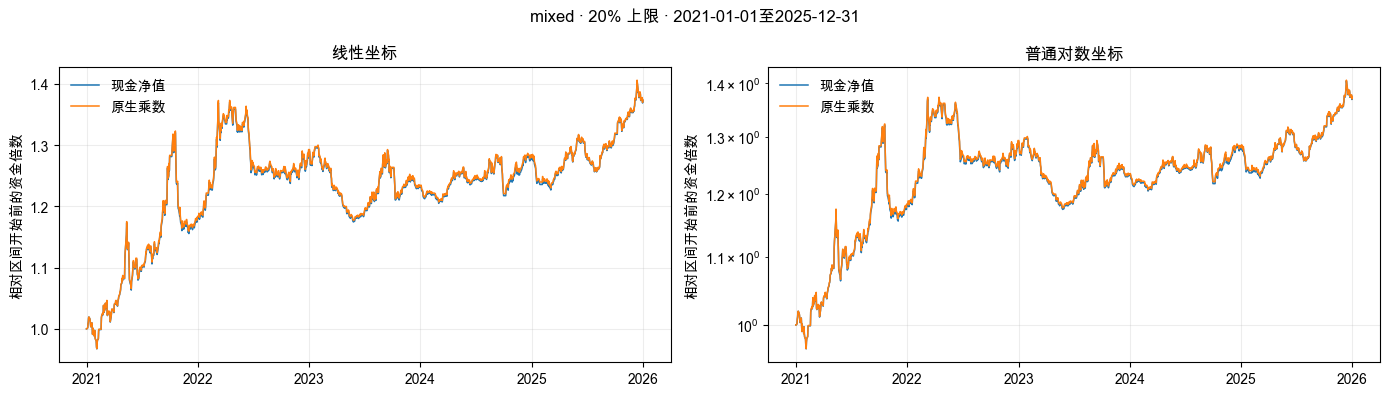

In [80]:
# 一行改日期即可；函数返回曲线和统计，便于继续分析。
curves, stats = show_period('2021-01-01', '2025-12-31')
fig = plot_funds(curves, 'mixed · 20%上限 · 2021–2025 · 初始本金1亿元')
fig.savefig(RUN_ROOT/'figures/period_example_2021_2025.png', bbox_inches='tight')
plt.close(fig)


## 7. 单品种名义敞口与收益贡献

敞口比值 = |延迟成交后的持仓手数| × 未复权价格 × 合约乘数 × 汇率 ÷ 原生组合实际资金。分位数使用正常账户期间的有效持仓日；持仓日占比以该品种已有报价日为分母。每档上限同时报告下单约束和每日估值超限。

已结束的连续历史在最后有效收盘平仓，并计入成本。平仓决策放在上一业务日，这是已知历史边界的事后假设。前身与后继历史的接续日期单列，信号完成预热后参与风险预算。

In [81]:
exposure_rows, extreme_rows = [], []
for (case,cap_name,code), part in instrument_frames.items():
    port = portfolio_frames[(case,cap_name)]
    normal = port.normal.reindex(part.index).fillna(False)
    observed = market[code].observed.reindex(part.index).fillna(False)
    valid = normal & observed
    holding = valid & part.held.ne(0)
    x = part.loc[holding,'leverage']
    limit = cap_series[cap_name].reindex(part.index)
    over = x.gt(limit.reindex(x.index)+1e-10) if cap_name!='unlimited' else pd.Series(False,index=x.index)
    decision_ratio = (part.target.abs()*market[code].price.reindex(part.index)*metadata.loc[code,'Pointsize']
                      /(CAPITAL*port.multiplier.reindex(part.index)))
    violations = int(decision_ratio.loc[normal].gt(limit.loc[normal]+1e-10).sum()) if cap_name!='unlimited' else 0
    assert violations == 0
    worst = x.idxmax() if len(x) else pd.NaT
    exposure_rows.append(dict(strategy=case,cap=cap_name,instrument=code,days=int(valid.sum()),
        trade_status='有持仓' if len(x) else '无交易',holding_days=int(holding.sum()),holding_fraction=holding.sum()/valid.sum() if valid.any() else 0.,
        median=x.median(),p95=x.quantile(.95),maximum=x.max(),worst_date=worst,
        over_limit_days=int(over.sum()),over_limit_fraction=over.mean() if len(x) else 0.,
        over_5x_days=int(x.gt(5).sum()),order_violations=violations,order_maximum=decision_ratio.loc[normal].max(),
        net_contribution_cnh=part.loc[normal,'net_cnh'].sum(),
        total_cost_cnh=-part.loc[normal,'cost_cnh'].sum()))
    part['daily_contribution_pct'] = 100*part.net_cnh/port.capital_cnh.reindex(part.index)
    if pd.notna(worst):
        f = market[code]
        forecast = forecast_frames[(case,code)].reindex(part.index).ffill()
        contract_history = data.get_multiple_prices(code).resample('B').last().ffill()
        extreme_rows.append(dict(strategy=case,cap=cap_name,instrument=code,date=worst,
            price_contract=contract_history.PRICE_CONTRACT.loc[worst],
            previous_contract=contract_history.PRICE_CONTRACT.shift(1).loc[worst],
            previous_forward=contract_history.FORWARD.shift(1).loc[worst],
            ratio=x.loc[worst],limit=limit.loc[worst],eligible_instruments=port.at[worst,'eligible_instruments'],point_size=metadata.loc[code,'Pointsize'],fx=1.,price=f.price.reindex(part.index).loc[worst],
            held=part.at[worst,'held'],target=part.at[worst,'target'],
            capital_cnh=port.at[worst,'capital_cnh'],
            decision_capital_cnh=CAPITAL*port.at[worst,'multiplier'],forecast=forecast.loc[worst],
            raw_vol_pct=f.raw_vol_pct.reindex(part.index).loc[worst],
            used_vol_pct=f.used_vol_pct.reindex(part.index).loc[worst],idm=port.at[worst,'idm'],
            previous_price=f.price.shift(1).reindex(part.index).loc[worst],
            previous_capital_cnh=port.capital_cnh.shift(1).loc[worst]))
exposure = pd.DataFrame(exposure_rows).set_index(['strategy','cap','instrument']).sort_index()
extremes = pd.DataFrame(extreme_rows).set_index(['strategy','cap','instrument']).sort_index()
exposure.to_csv(RUN_ROOT/'instrument_exposure.csv')
extremes.to_csv(RUN_ROOT/'extreme_exposure_days.csv')
for case in CASES:
    for cap_name in CAPS:
        pd.concat({code:instrument_frames[(case,cap_name,code)] for code in eligible_codes},
                  names=['instrument','date']).to_parquet(RUN_ROOT/f'{case}_{cap_name}_instruments.parquet')
        expected = portfolio_frames[(case,cap_name)].loc[lambda f:f.normal,'net_cnh'].sum()
        actual = exposure.loc[(case,cap_name),'net_contribution_cnh'].sum()
        np.testing.assert_allclose(actual, expected, atol=1e-5)
display(exposure.loc[('mixed','unlimited')].sort_values('maximum',ascending=False).head(20))
display(extremes.loc[('mixed','unlimited')].sort_values('ratio',ascending=False).head(15))
display(exposure.groupby(['strategy','cap'])[['over_limit_days','total_cost_cnh','net_contribution_cnh']].sum())

,days,trade_status,holding_days,holding_fraction,median,p95,maximum,worst_date,over_limit_days,over_limit_fraction,over_5x_days,order_violations,order_maximum,net_contribution_cnh,total_cost_cnh
instrument,,,,,,,,,,,,,,,
SHFE_CU,7527,有持仓,7510,0.9977,0.0367,1.1289,2.4364,1996-03-04,0,0.0000,0,0,2.3890,"1,415,732,975.2543","10,788,424.7457"
SHFE_AL,7002,有持仓,6802,0.9714,0.0841,0.7932,2.0553,1998-05-25,0,0.0000,0,0,2.0628,"1,591,238,809.5771","23,727,365.4229"
DCE_C,5225,有持仓,5126,0.9811,0.0875,0.5155,1.1214,2006-10-10,0,0.0000,0,0,1.0975,"-498,843,586.8689","34,448,636.8689"
CZCE_WT,2238,有持仓,1878,0.8391,0.4634,0.8100,1.0256,2000-05-09,0,0.0000,0,0,1.0187,"508,192,227.8366","65,968,672.1634"
CZCE_CF,5258,有持仓,5151,0.9797,0.0477,0.4687,0.8356,2007-05-15,0,0.0000,0,0,0.8469,"807,071,505.3226","13,573,494.6774"
DCE_M,6221,有持仓,6122,0.9841,0.0476,0.3396,0.8293,2002-02-28,0,0.0000,0,0,0.8176,"45,965,368.9786","12,659,421.0214"
DCE_A,6695,有持仓,6596,0.9852,0.0852,0.4735,0.7530,2003-05-21,0,0.0000,0,0,0.7554,"-244,439,222.6403","13,517,492.6403"
CZCE_WS,2357,有持仓,2166,0.9190,0.2398,0.5313,0.7106,2005-02-21,0,0.0000,0,0,0.7026,"115,125,429.1063","51,226,340.8937"
SHFE_RU,6639,有持仓,6175,0.9301,0.0323,0.2405,0.6492,2003-02-14,0,0.0000,0,0,0.6194,"306,577,492.3641","9,043,007.6359"


,date,price_contract,previous_contract,previous_forward,ratio,limit,eligible_instruments,point_size,fx,price,held,target,capital_cnh,decision_capital_cnh,forecast,raw_vol_pct,used_vol_pct,idm,previous_price,previous_capital_cnh
instrument,,,,,,,,,,,,,,,,,,,,
SHFE_CU,1996-03-04,19960500,19960500,"25,700.0000",2.4364,inf,1,5.0000,1.0000,"26,220.0000","-2,031.0000","-1,390.0000","109,285,874.8785","104,168,727.7162",-8.9445,11.1149,11.1149,1.2224,"25,710.0000","109,286,475.9541"
SHFE_AL,1998-05-25,19980700,19980700,"13,750.0000",2.0553,inf,2,5.0000,1.0000,"13,730.0000","-6,087.0000","-6,087.0000","203,313,174.2777","207,367,442.2859",-14.0564,7.1399,7.1399,1.2387,"13,780.0000","204,691,155.1340"
DCE_C,2006-10-10,20070100,20070100,"1,417.0000",1.1214,inf,8,10.0000,1.0000,"1,364.0000","-171,174.0000","-107,639.0000","2,082,132,841.4073","2,011,660,712.9904",-14.2804,8.6797,8.6797,2.0729,"1,335.0000","2,066,023,744.3689"
CZCE_WT,2000-05-09,20000700,20000700,"1,060.0000",1.0256,inf,4,10.0000,1.0000,"1,052.0000","-34,580.0000","-33,672.0000","354,710,957.7486","354,469,222.2309",-14.2147,11.1999,11.1999,1.8391,"1,045.0000","364,150,092.2909"
CZCE_CF,2007-05-15,20070900,20070900,"13,745.0000",0.8356,inf,10,5.0000,1.0000,"13,370.0000","-25,065.0000","-23,174.0000","2,005,191,213.9309","2,030,586,008.1895",-16.8792,8.5549,8.5549,2.2815,"13,550.0000","2,033,291,969.7730"
DCE_M,2002-02-28,20020500,20020500,"1,700.0000",0.8293,inf,5,10.0000,1.0000,"1,633.0000","-29,009.0000","-26,639.0000","571,210,748.6901","563,335,537.4992",-14.9498,10.8403,10.8403,1.6401,"1,610.0000","573,332,293.1744"
DCE_A,2003-05-21,20030900,20030900,"2,445.0000",0.7530,inf,6,10.0000,1.0000,"2,755.0000","18,118.0000","18,118.0000","662,886,351.0730","670,969,288.9391",14.5532,10.5276,10.5276,2.1225,"2,743.0000","662,296,840.6551"
CZCE_WS,2005-02-21,20050900,20050900,"1,654.0000",0.7106,inf,7,10.0000,1.0000,"1,685.0000","-45,600.0000","-39,969.0000","1,081,259,549.2707","1,053,707,920.6328",-15.7659,12.5441,12.5441,2.0922,"1,652.0000","1,075,588,733.5467"
SHFE_RU,2003-02-14,20030500,20030500,"12,450.0000",0.6492,inf,6,10.0000,1.0000,"14,150.0000","3,187.0000","2,703.0000","694,631,638.2587","715,182,942.4185",16.0473,17.3061,17.3061,2.0358,"13,500.0000","684,012,818.0672"


over_limit_days     total_cost_cnh  net_contribution_cnh
strategy cap                                                                
breakout bounded3               403   249,986,296.3402    6,949,568,233.6598
         cap10                  133    39,458,603.9322    1,082,130,291.0678
         cap20                  160   104,698,111.0466    2,732,967,258.9534
         cap30                   77   195,327,793.6699    5,043,917,541.3301
         equal3                 423   418,656,719.4094   11,628,605,140.5906
         unlimited                0   751,975,221.9735   19,374,570,928.0265
carry    bounded3              3436    75,635,936.4113    2,868,936,613.5887
         cap10                  886    22,392,927.1413      850,780,517.8587
         cap20                  684    59,400,233.7654    1,936,705,096.2346
         cap30                  546    97,971,991.9945    2,936,651,623.0055
         equal3                3487   246,317,875.6521    9,332,921,879.3479
         unlimited                0 1,014,048,989.2698   27,001,826,225.7302
mixed    bounded3               991   141,625,773.4073    5,725,851,091.5927
         cap10                  272    25,461,433.1898    1,032,175,071.8102
         cap20                  223    69,526,821.2856    2,495,984,073.7144
         cap30                  160   132,697,446.4844    4,568,113,318.5156
         equal3                 994   320,026,685.7267   12,907,143,874.2733
         unlimited                0   788,978,495.7730   26,231,733,654.2270

In [82]:
# 成交容量是原生成交假设的事后诊断。
# 订单/20日均量表示该笔订单占已知日成交量的比例；
# 持仓/20日均量以100%成交参与率折算为天数，零量和未知量分别保留。
# 使用同一张合约过去20个原始日线观察的成交量，零成交日保留。
volume_evidence = pd.read_parquet(DATA_ROOT/'volume_diagnostics.parquet')
capacity_rows, capacity_extreme_rows = [], []
for (case,cap_name,code), part in instrument_frames.items():
    port = portfolio_frames[(case,cap_name)]
    volume = volume_evidence.xs(code,level='instrument')
    prior = volume.contract_volume_prior_mean20.reindex(part.index)
    chain = volume.price_contract.reindex(part.index).ffill()
    rolled = chain.ne(chain.shift(1)) & chain.notna() & chain.shift(1).notna()
    # 列出仓位调整和连续合约模型隐含的换月两腿。
    adjustment = (part.target-part.held).abs()
    new_order = adjustment.where(~rolled,part.target.abs())
    old_exit = part.held.abs().where(rolled,0.)
    old_volume = volume.contract_volume_prior_mean20.shift(1).reindex(part.index)
    fraction = pd.concat([new_order/prior.where(prior.gt(0)),
                           old_exit/old_volume.where(old_volume.gt(0))],axis=1).max(axis=1)
    unknown = (new_order.gt(0) & ~prior.gt(0)) | (old_exit.gt(0) & ~old_volume.gt(0))
    fraction = fraction.mask(unknown)
    valid = market[code].observed.reindex(part.index).fillna(False) & port.normal.reindex(part.index).fillna(False)
    trade = valid & (new_order+old_exit).gt(0)
    holding = valid & part.held.ne(0)
    days_to_exit = part.held.abs()/prior.where(prior.gt(0))
    part['known_volume20'] = prior
    part['order_volume_fraction'] = fraction
    part['position_volume_days'] = days_to_exit
    part['daily_contribution_pct'] = 100*part.net_cnh/port.capital_cnh.reindex(part.index)
    n_changed = daily_n.diff().fillna(0).ne(0).reindex(part.index).fillna(False)
    measured = days_to_exit.loc[holding].dropna()
    if len(measured):
        peak = measured.idxmax()
        capacity_extreme_rows.append(dict(strategy=case,cap=cap_name,instrument=code,date=peak,
            holding_volume_days=measured.loc[peak],held=part.at[peak,'held'],
            lagged_volume20=prior.loc[peak],price_contract=chain.loc[peak],
            price=market[code].price.reindex(part.index).loc[peak],capital_cnh=port.at[peak,'capital_cnh'],
            target=part.at[peak,'target'],window=market[code].window.reindex(part.index).loc[peak]))
    capacity_rows.append({'strategy':case,'cap':cap_name,'instrument':code,
        'order_days':int(trade.sum()),'orders_on_n_change':int((trade & n_changed).sum()),
        'contracts_on_n_change':float((new_order+old_exit).loc[trade & n_changed].sum()),'implicit_roll_days':int((valid & rolled & (new_order+old_exit).gt(0)).sum()),
        'order_over_1pct_days':int((trade & fraction.gt(.01)).sum()),
        'order_over_5pct_days':int((trade & fraction.gt(.05)).sum()),
        'order_over_10pct_days':int((trade & fraction.gt(.10)).sum()),
        'zero_or_unknown_order_volume_days':int((trade & unknown).sum()),
        'zero_order_volume_days':int((trade & ((new_order.gt(0) & prior.eq(0)) | (old_exit.gt(0) & old_volume.eq(0)))).sum()),
        'unknown_order_volume_days':int((trade & ((new_order.gt(0) & prior.isna()) | (old_exit.gt(0) & old_volume.isna()))).sum()),
        'known_order_volume_days':int((trade & fraction.notna()).sum()),
        'known_holding_volume_days':int((holding & days_to_exit.notna()).sum()),
        'order_fraction_p95':fraction.loc[trade].quantile(.95),
        'holding_volume_days_p95':days_to_exit.loc[holding].quantile(.95),
        'holding_volume_days_max':days_to_exit.loc[holding].max()})
capacity = pd.DataFrame(capacity_rows).set_index(['strategy','cap','instrument']).sort_index()
capacity.to_csv(RUN_ROOT/'capacity_diagnostics.csv')
capacity_extremes = pd.DataFrame(capacity_extreme_rows)
capacity_extremes.to_csv(RUN_ROOT/'capacity_extremes.csv',index=False)
display(capacity_extremes.loc[capacity_extremes.strategy.eq('mixed') & capacity_extremes.cap.eq('bounded3')].sort_values('holding_volume_days',ascending=False).head(10))
display(capacity.loc[('mixed','bounded3')].sort_values('holding_volume_days_max',ascending=False).head(20))
print('容量表保留零成交日，按换月两腿中较高的成交量占比统计；执行仍采用原生账户假设。')
# 保存带容量、日收益贡献字段的逐品种结果。
for case in CASES:
    for cap_name in CAPS:
        pd.concat({code:instrument_frames[(case,cap_name,code)] for code in eligible_codes},
                  names=['instrument','date']).to_parquet(RUN_ROOT/f'{case}_{cap_name}_instruments.parquet')


,strategy,cap,instrument,date,holding_volume_days,held,lagged_volume20,price_contract,price,capital_cnh,target,window
1606,mixed,bounded3,SHFE_BU,2014-11-17,"1,306.7857","-3,659.0000",2.8000,20150600,"3,836.0000","1,792,229,241.5903","-3,834.0000",1.0000
1564,mixed,bounded3,CZCE_WT,2005-12-28,947.1698,"-10,040.0000",10.6000,20060100,"1,380.0000","510,340,805.9912","-10,046.0000",1.0000
1568,mixed,bounded3,DCE_BB,2015-09-01,718.7179,"-2,803.0000",3.9000,20160100,94.8000,"2,061,059,002.3441","-2,790.0000",1.0000
1574,mixed,bounded3,DCE_FB,2025-12-29,544.4947,"-18,050.0000",33.1500,20260100,"1,274.0000","5,659,166,574.1251","-18,050.0000",3.0000
1553,mixed,bounded3,CZCE_RS,2013-09-06,391.0448,"2,620.0000",6.7000,20131100,"5,160.0000","1,329,804,030.2512",0.0000,1.0000
1562,mixed,bounded3,CZCE_WH,2020-09-01,191.5816,"-3,755.0000",19.6000,20210100,"2,623.0000","3,666,163,057.2793",0.0000,3.0000
1567,mixed,bounded3,DCE_B,2005-10-31,93.3566,"-1,335.0000",14.3000,20060300,"2,690.0000","488,068,348.1174","-1,335.0000",1.0000
1538,mixed,bounded3,CZCE_CY,2019-05-10,89.8895,"-1,627.0000",18.1000,20190500,"23,000.0000","3,098,987,322.5703",-714.0000,1.0000
1587,mixed,bounded3,DCE_RR,2024-04-25,45.9836,"-5,610.0000",122.0000,20240600,"3,512.0000","5,135,698,526.3617","-5,610.0000",1.0000
1546,mixed,bounded3,CZCE_PK,2022-09-15,42.1422,"-4,741.0000",112.5000,20221100,"9,988.0000","5,130,795,236.4007","-4,741.0000",1.0000


,order_days,orders_on_n_change,contracts_on_n_change,implicit_roll_days,order_over_1pct_days,order_over_5pct_days,order_over_10pct_days,zero_or_unknown_order_volume_days,zero_order_volume_days,unknown_order_volume_days,known_order_volume_days,known_holding_volume_days,order_fraction_p95,holding_volume_days_p95,holding_volume_days_max
instrument,,,,,,,,,,,,,,,
SHFE_BU,1483,252,"127,449.0000",36,120,43,34,0,0,0,1483,2875,0.0188,0.3831,"1,306.7857"
CZCE_WT,649,106,"637,010.0000",30,457,309,254,0,0,0,649,1878,49.2572,89.5926,947.1698
DCE_BB,65,9,977.0000,2,62,46,33,0,0,0,65,143,0.7027,11.4114,718.7179
DCE_FB,789,122,"513,782.0000",38,753,645,567,0,0,0,789,1343,4.8493,45.7460,544.4947
CZCE_RS,16,7,"30,297.0000",0,16,15,13,0,0,0,16,18,362.1105,84.1518,391.0448
CZCE_WH,482,130,"281,324.0000",16,435,292,207,0,0,0,482,1217,24.1636,24.4475,191.5816
DCE_B,1119,201,"120,545.0000",28,466,222,157,5,0,5,1114,2292,0.4339,4.9154,93.3566
CZCE_CY,953,234,"154,772.0000",24,553,244,154,0,0,0,953,1757,0.3421,3.0138,89.8895
DCE_RR,223,39,"232,332.0000",73,186,168,159,0,0,0,223,1516,4.9190,7.4039,45.9836


容量表保留零成交日，按换月两腿中较高的成交量占比统计；执行仍采用原生账户假设。


## 当前本金下的整手约束与预热

逐日检查限额是否容纳至少一手，再检查股指与丙烯的实际交易起点。首次持仓同时受到共同资格、forecast抵消、buffer和整手取整影响。

In [105]:
minimum_rows, execution_rows = [], []
for code in eligible_codes:
    unit = market[code].price.reindex(INDEX).ffill().abs()*metadata.loc[code,'Pointsize']
    for cap in ['cap10','cap20','cap30','equal3','bounded3']:
        needed = (unit/cap_series[cap]).where(eligibility[code]).dropna()
        assert len(needed) and np.floor(CAPITAL/needed).ge(1).all()
        minimum_rows.append(dict(instrument=code,cap=cap,required_capital_cnh=needed.max(),date=needed.idxmax()))
for code in ['CFFEX_IF','CFFEX_IH','CZCE_PL']:
    for case in CASES:
        for cap in CAPS:
            part = instrument_frames[(case,cap,code)]
            dates = part.index[part.held.ne(0)]
            execution_rows.append(dict(instrument=code,strategy=case,cap=cap,first_held=dates.min(),
                last_held=dates.max(),holding_days_since_2021=int(part.loc['2021':,'held'].ne(0).sum())))
minimum_capital = pd.DataFrame(minimum_rows)
execution_diagnostics = pd.DataFrame(execution_rows)
minimum_capital.to_csv(RUN_ROOT/'minimum_one_lot_capital.csv',index=False)
execution_diagnostics.to_csv(RUN_ROOT/'current_execution_diagnostics.csv',index=False)
display(minimum_capital.nlargest(10,'required_capital_cnh'))
display(execution_diagnostics.query("cap in ['cap20','equal3','bounded3']"))

,instrument,cap,required_capital_cnh,date
18,CFFEX_IM,equal3,"45,402,400.0000",2026-05-13
19,CFFEX_IM,bounded3,"45,402,400.0000",2026-05-13
3,CFFEX_IC,equal3,"45,333,493.3333",2026-06-30
4,CFFEX_IC,bounded3,"45,333,493.3333",2026-06-30
8,CFFEX_IF,equal3,"37,974,160.0000",2026-05-13
9,CFFEX_IF,bounded3,"37,974,160.0000",2026-05-13
373,SHFE_AU,equal3,"30,050,400.0000",2026-01-29
374,SHFE_AU,bounded3,"30,050,400.0000",2026-01-29
23,CFFEX_TL,equal3,"29,558,933.3333",2026-08-24
24,CFFEX_TL,bounded3,"29,558,933.3333",2026-08-24


,instrument,strategy,cap,first_held,last_held,holding_days_since_2021
2,CFFEX_IF,carry,cap20,2010-10-20,2026-09-07,1420
4,CFFEX_IF,carry,equal3,2010-10-20,2026-09-07,1423
5,CFFEX_IF,carry,bounded3,2010-10-20,2026-09-07,1421
8,CFFEX_IF,breakout,cap20,2010-10-20,2026-09-07,1412
10,CFFEX_IF,breakout,equal3,2010-10-20,2026-09-07,1419
11,CFFEX_IF,breakout,bounded3,2010-10-20,2026-09-07,1418
14,CFFEX_IF,mixed,cap20,2010-10-20,2026-09-07,1382
16,CFFEX_IF,mixed,equal3,2010-10-20,2026-09-07,1386
17,CFFEX_IF,mixed,bounded3,2010-10-20,2026-09-07,1385
20,CFFEX_IH,carry,cap20,2015-10-14,2026-09-07,1375


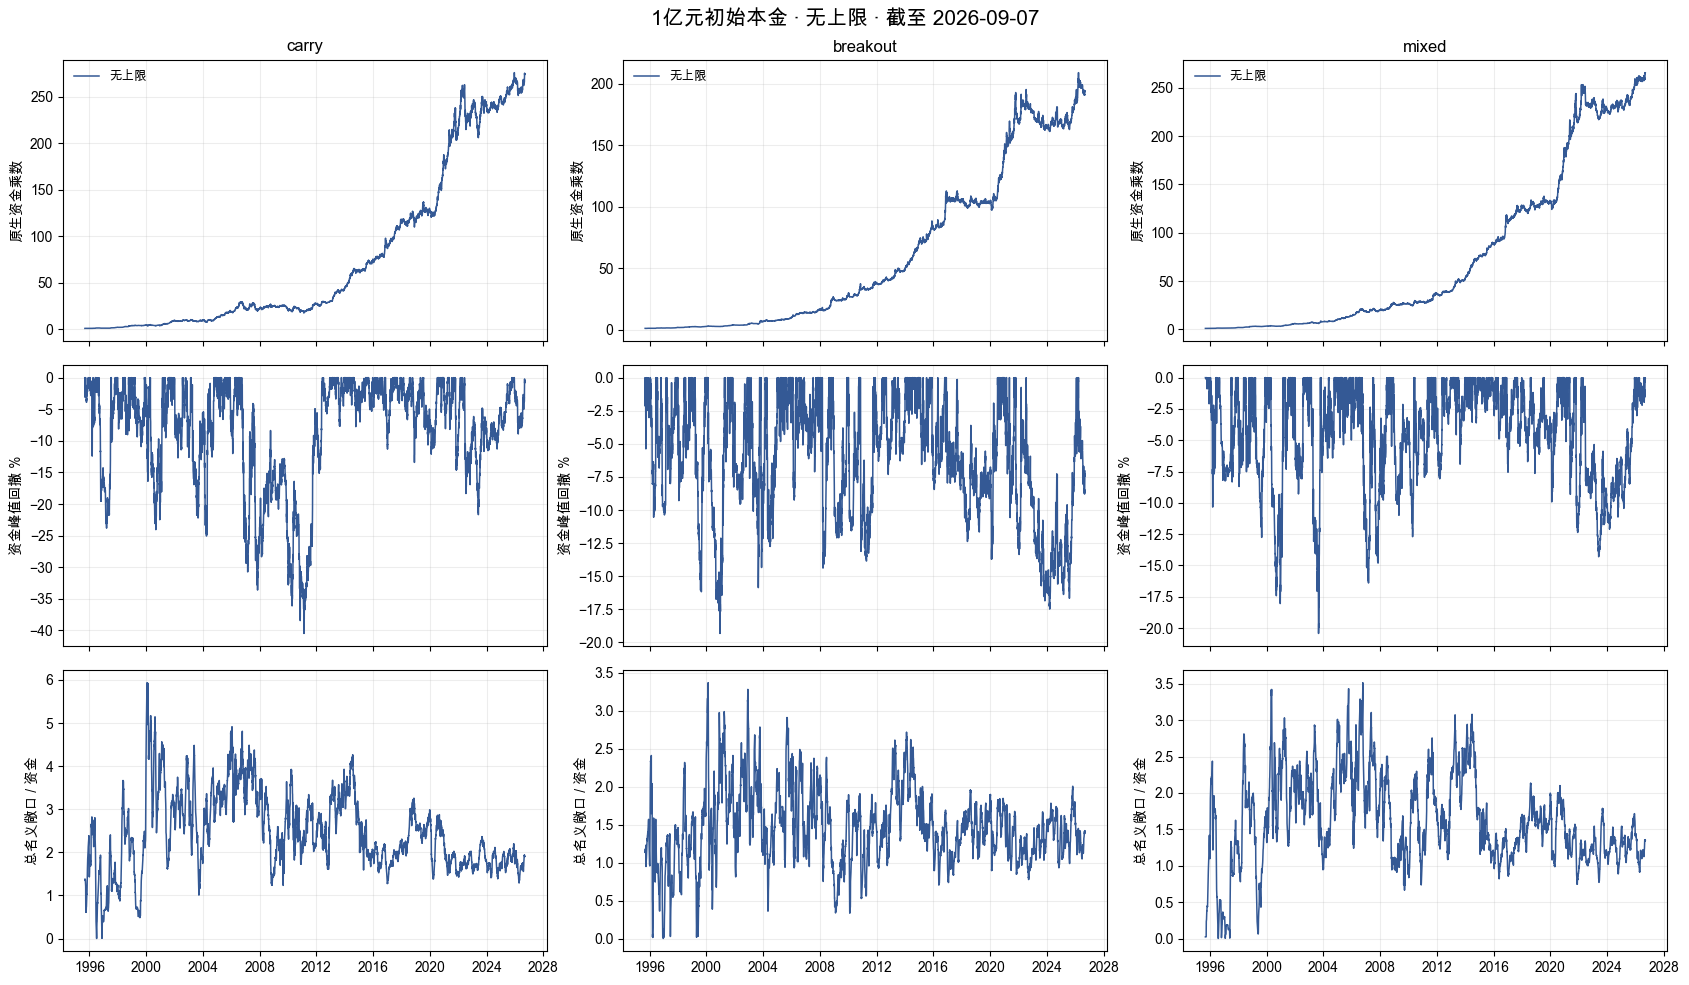

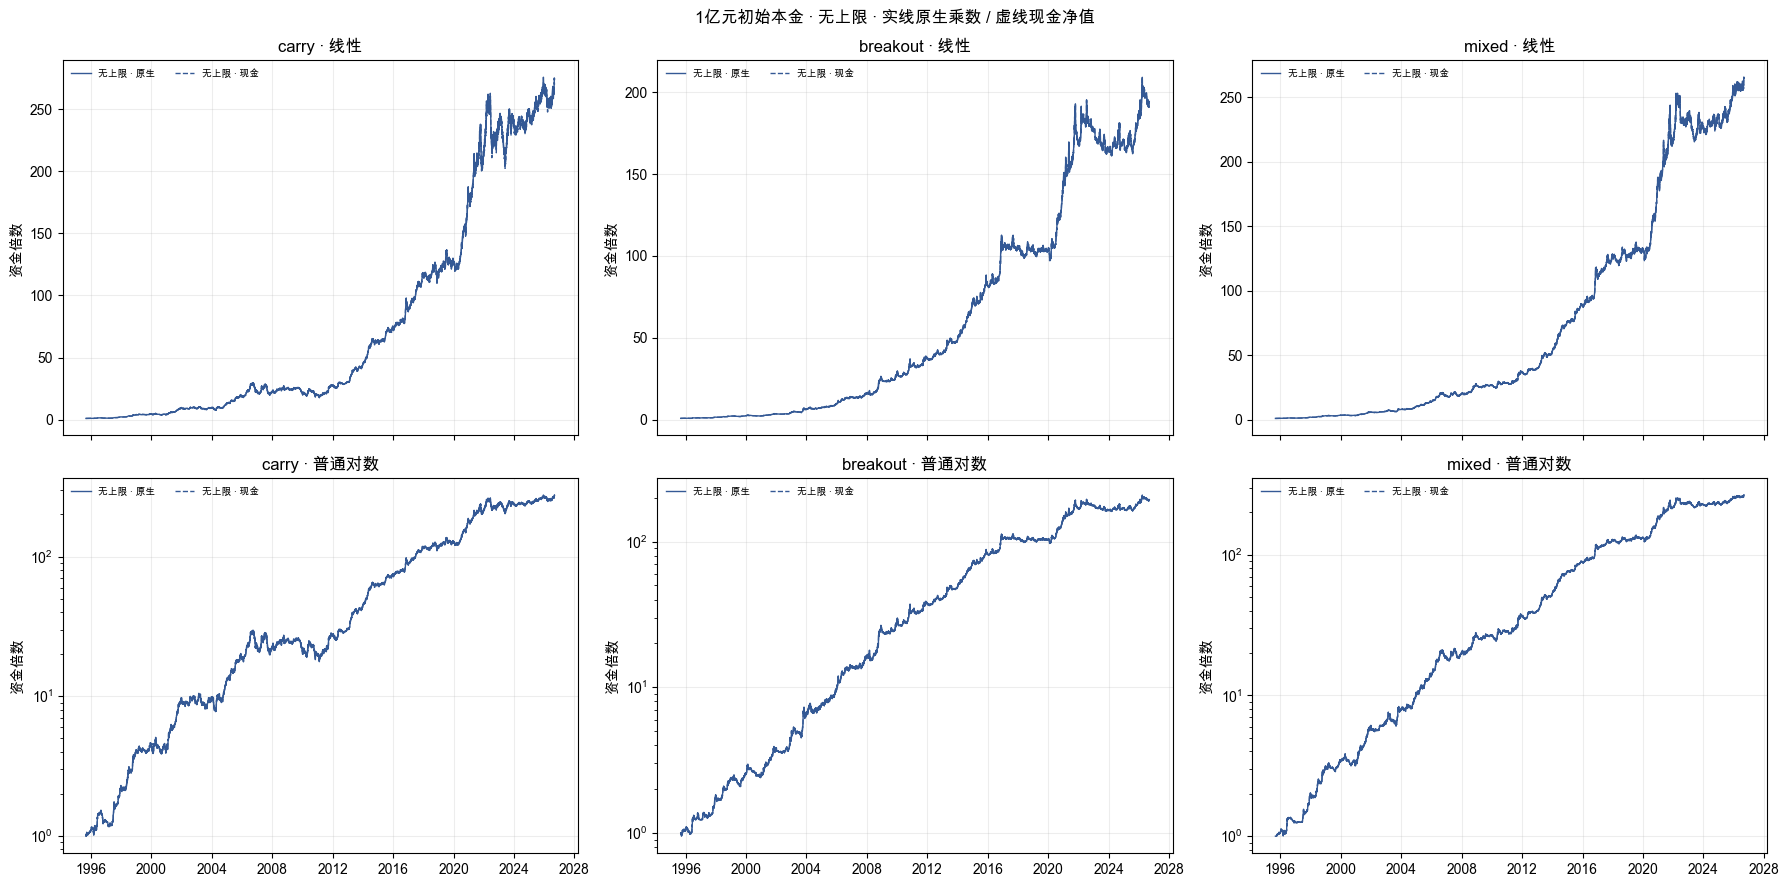

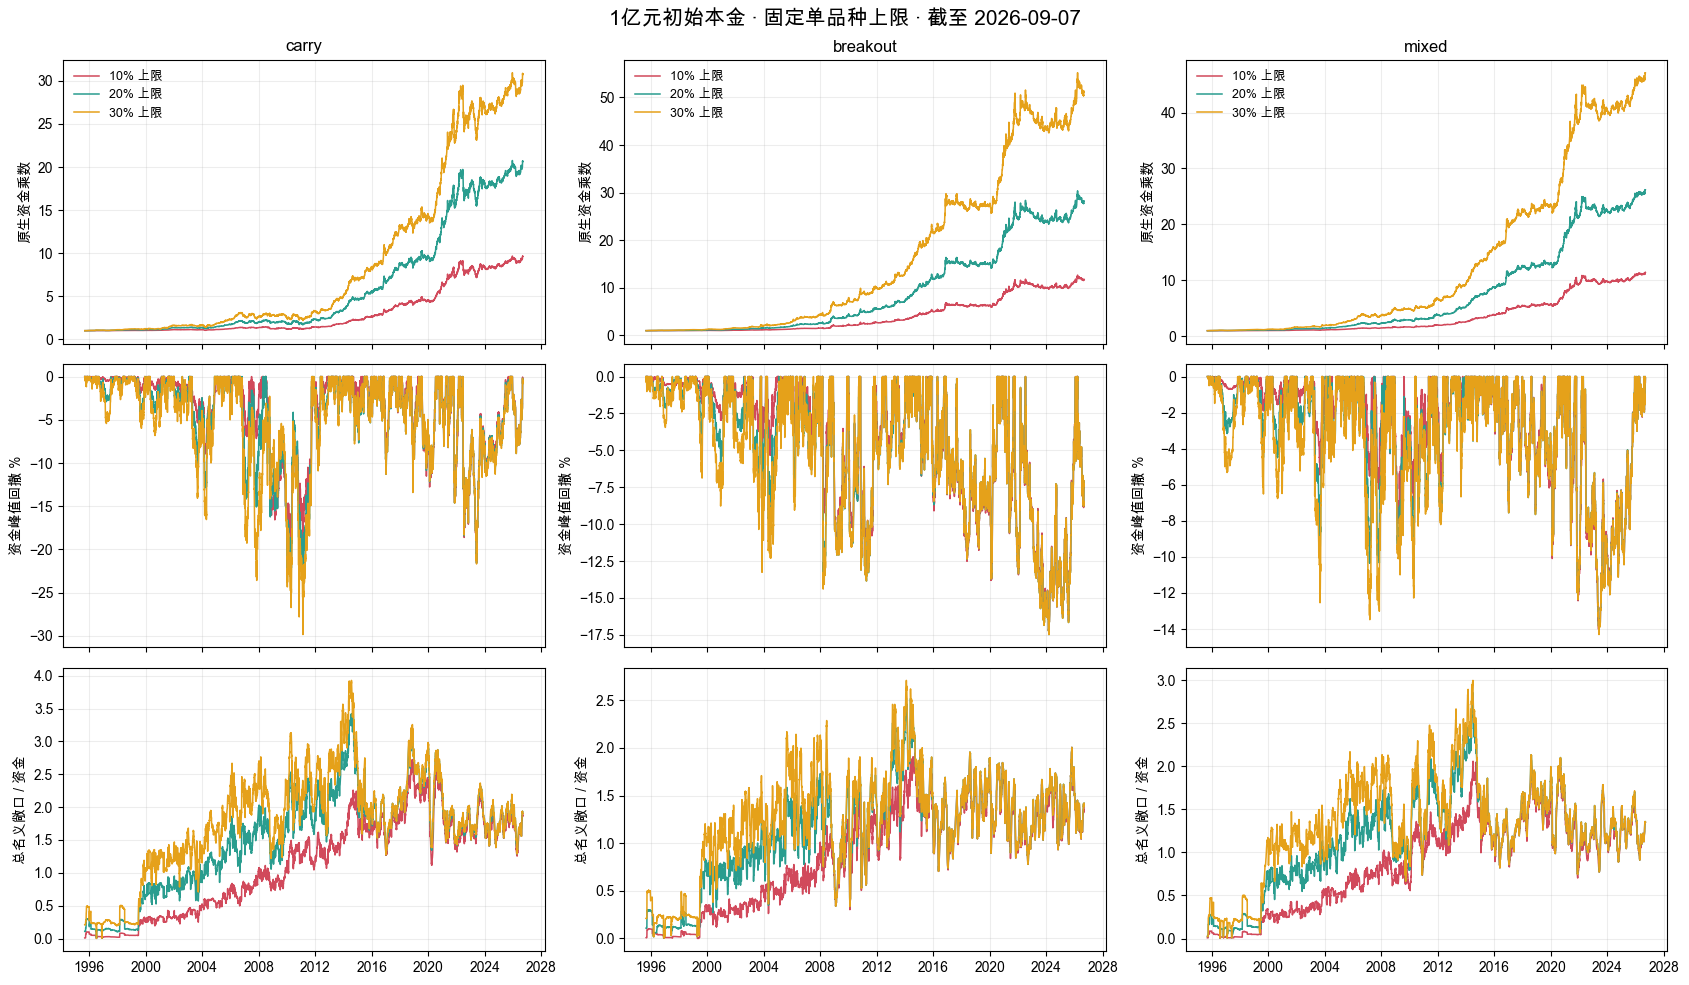

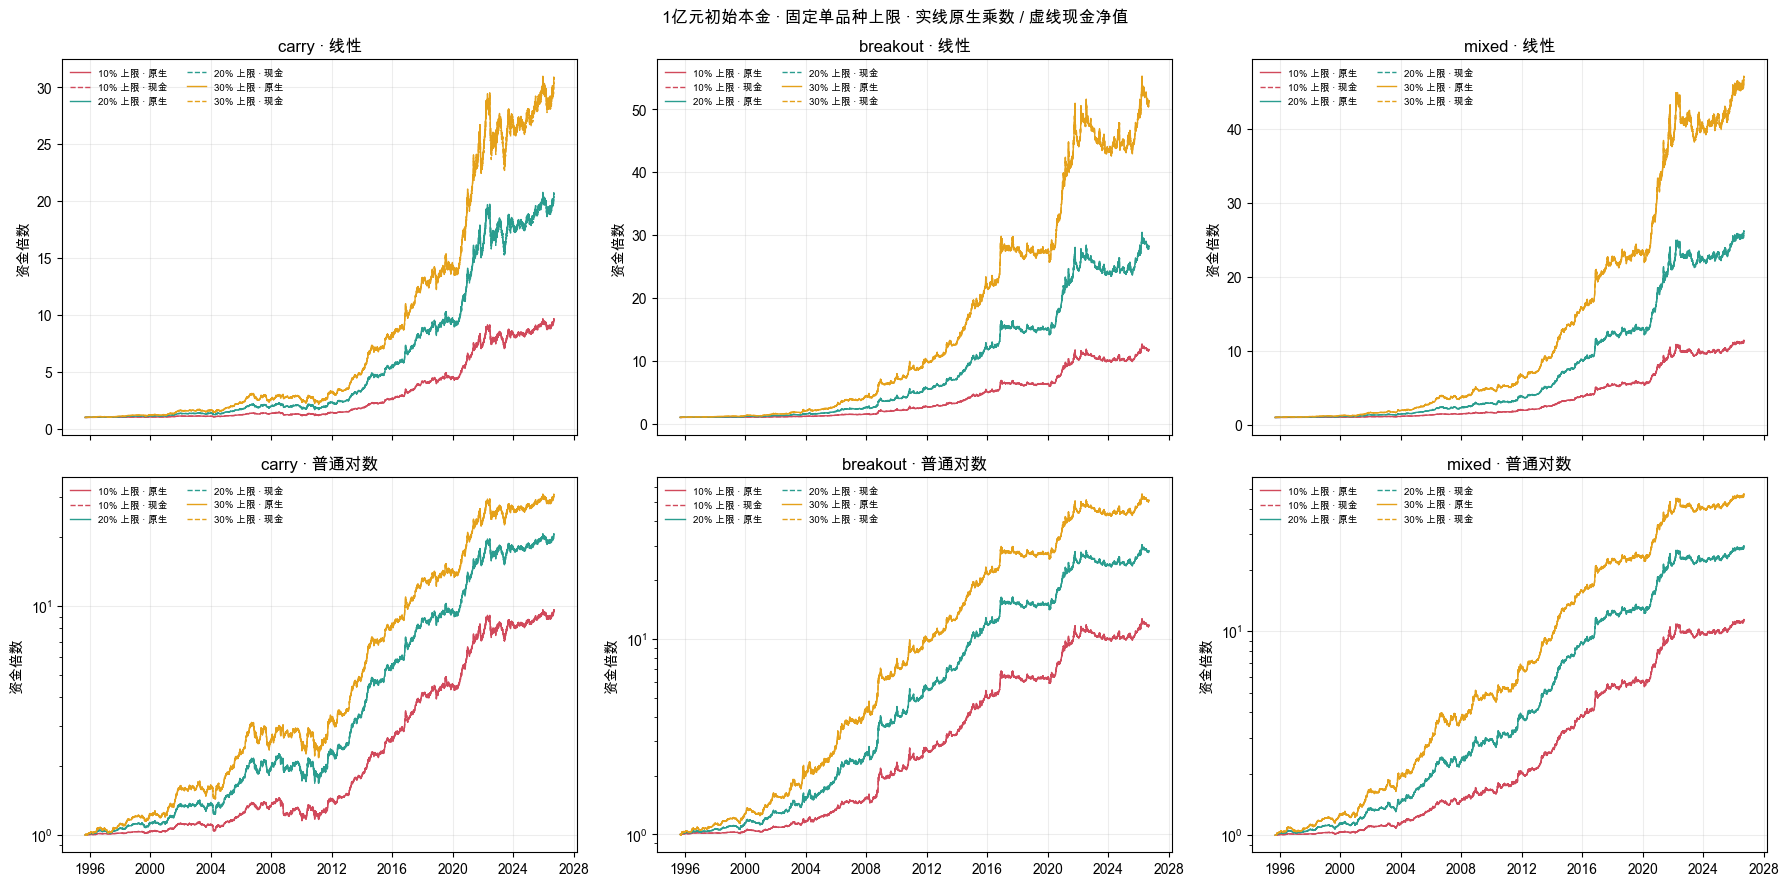

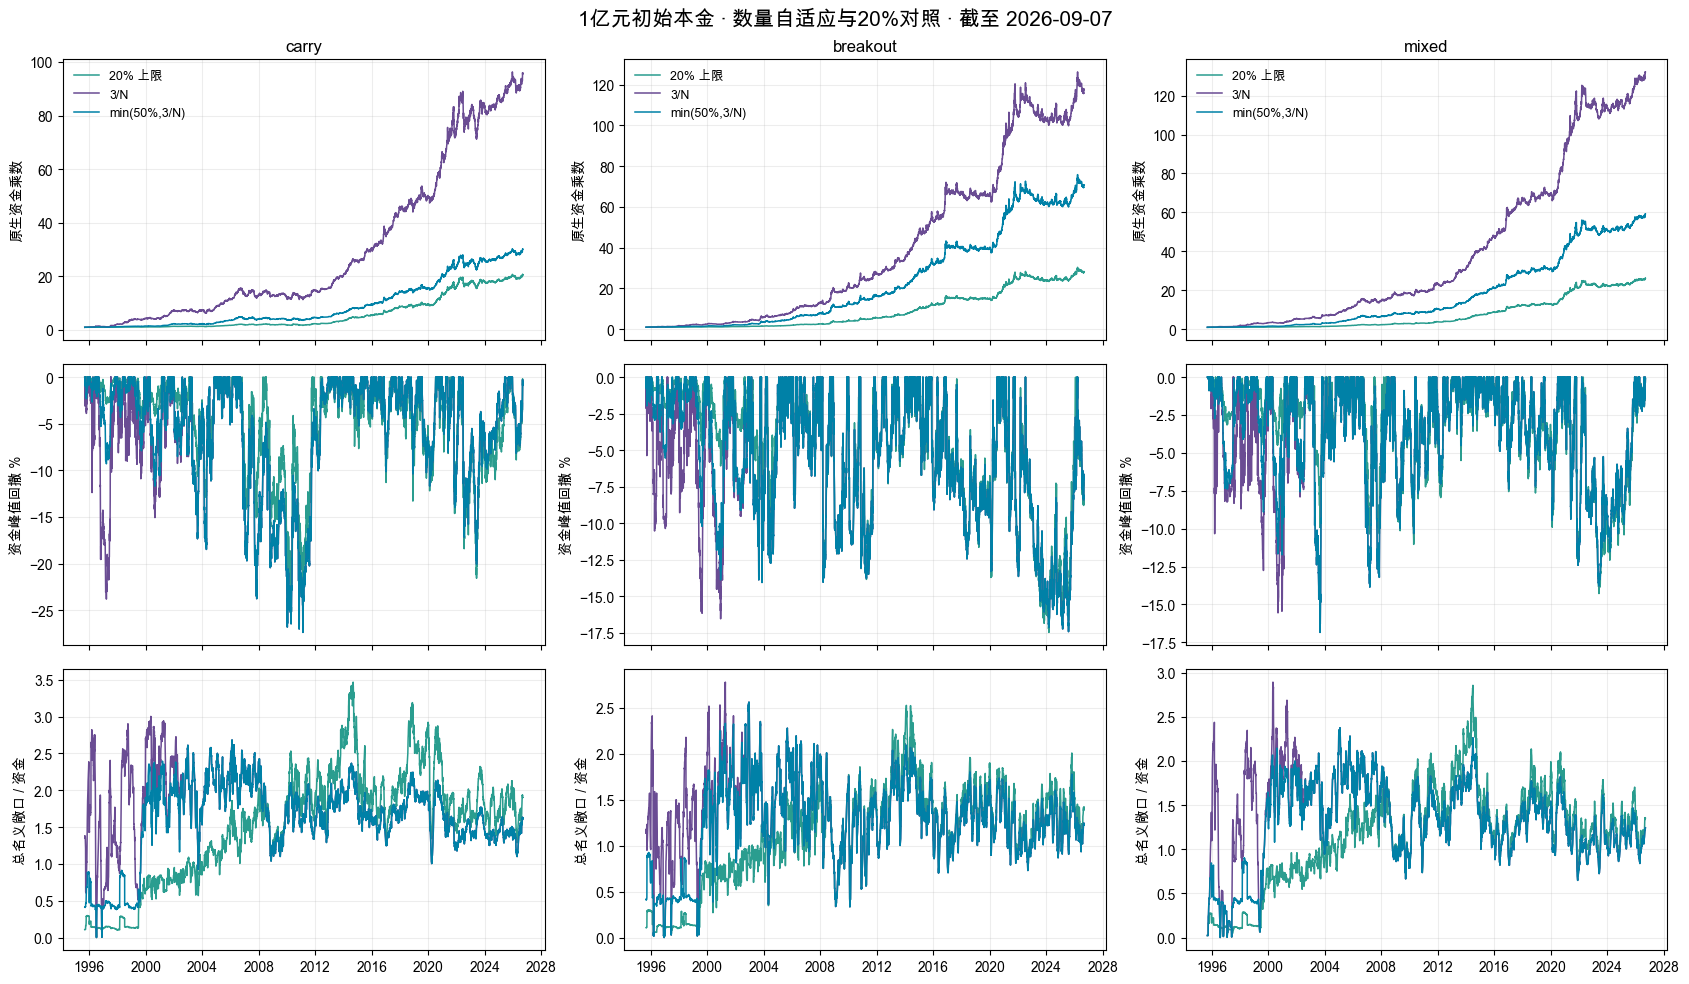

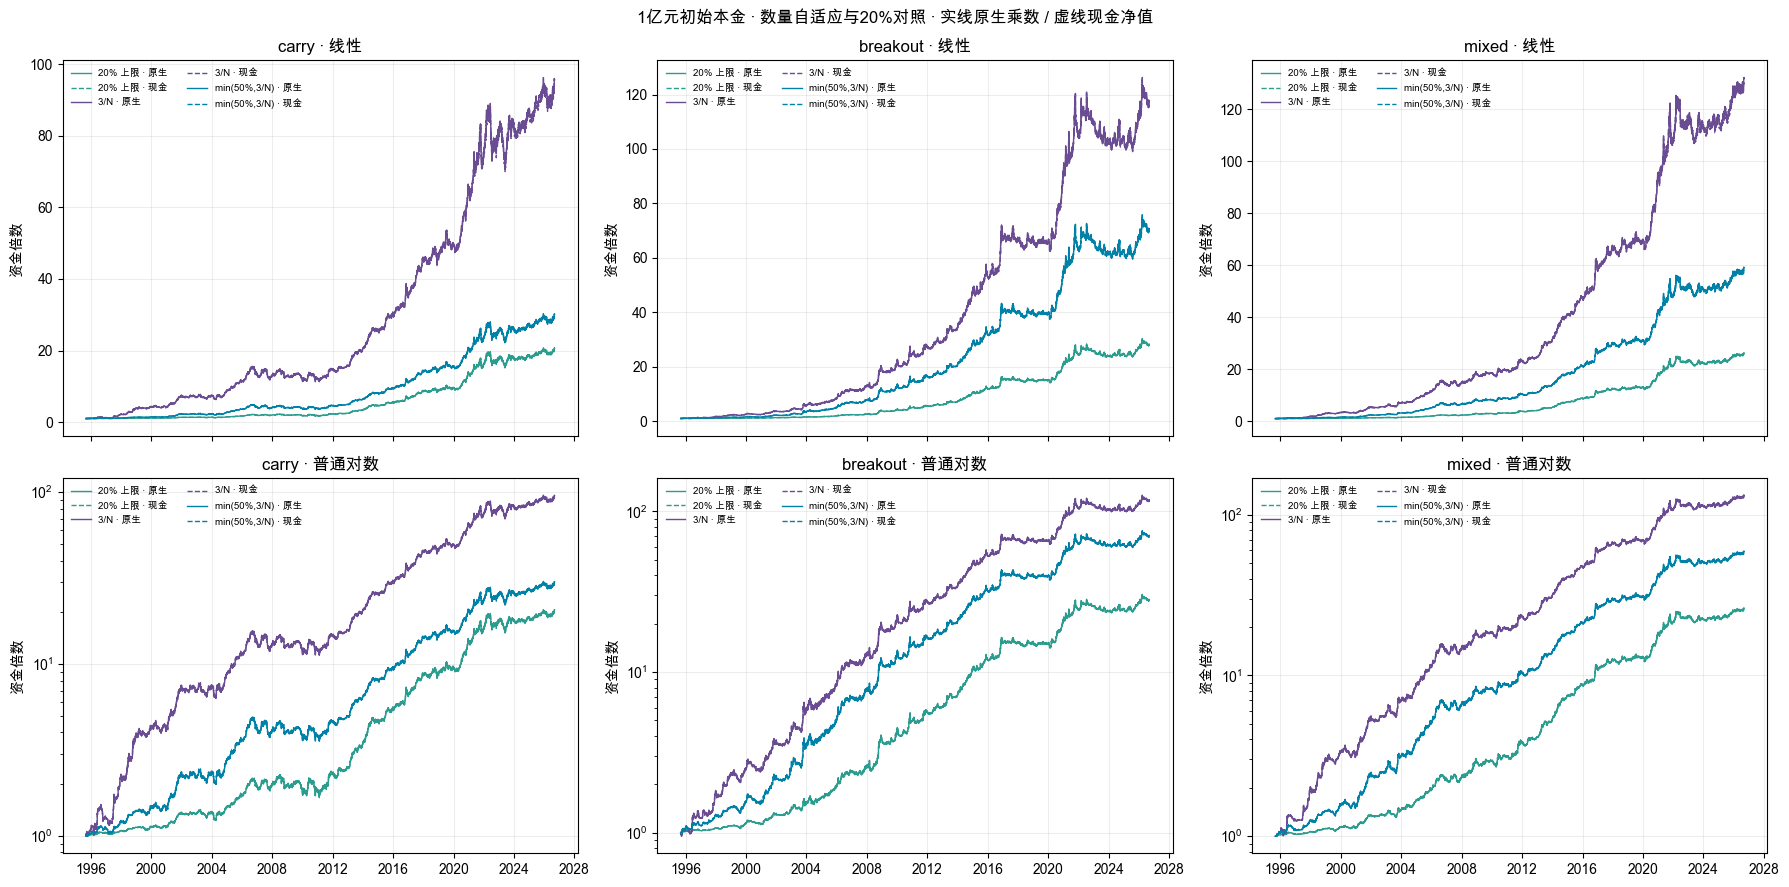

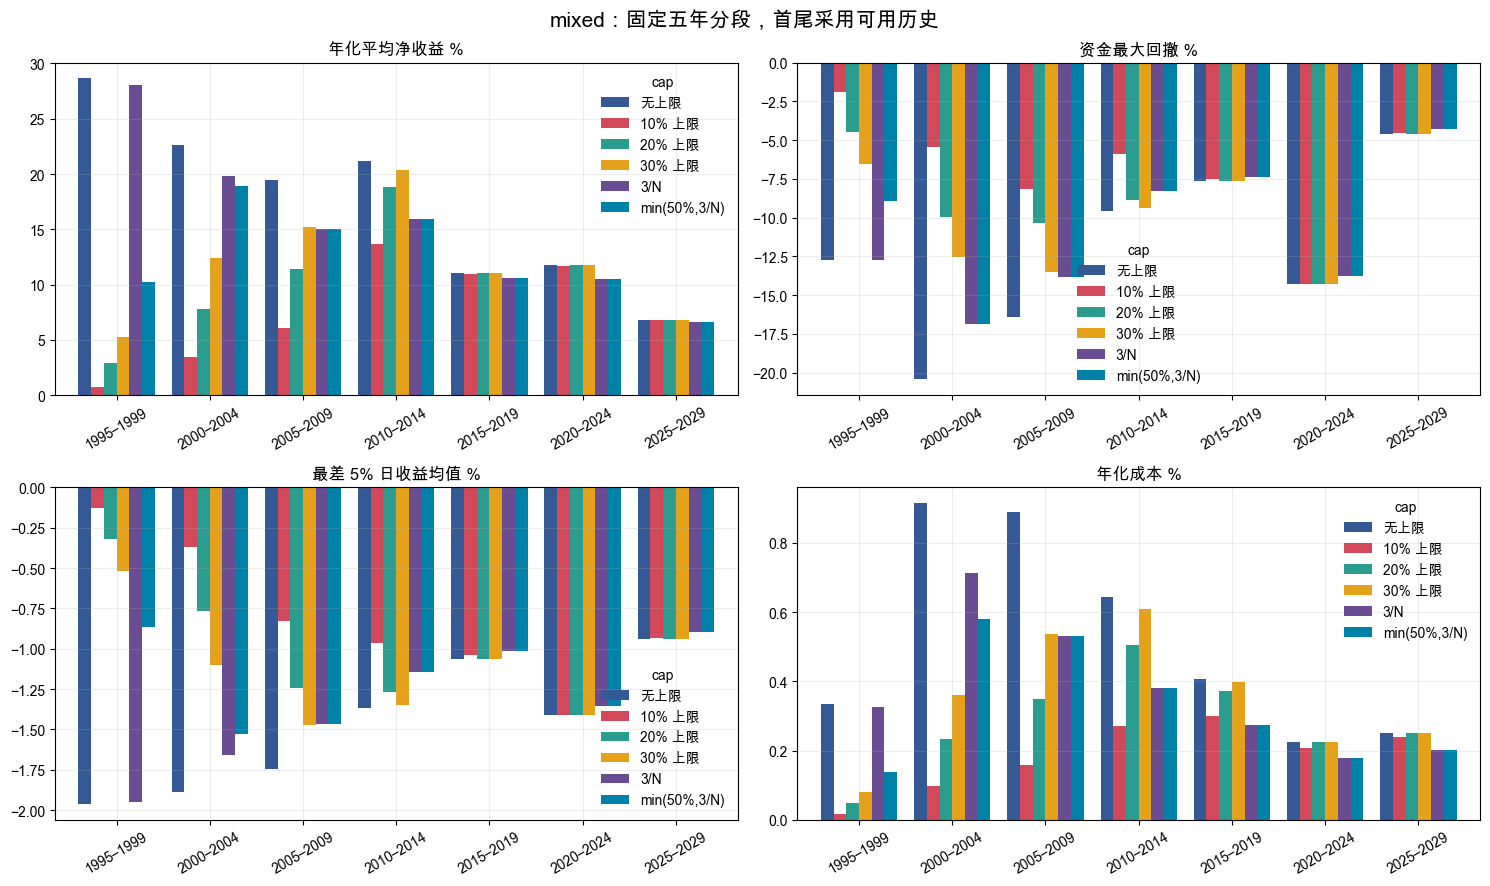

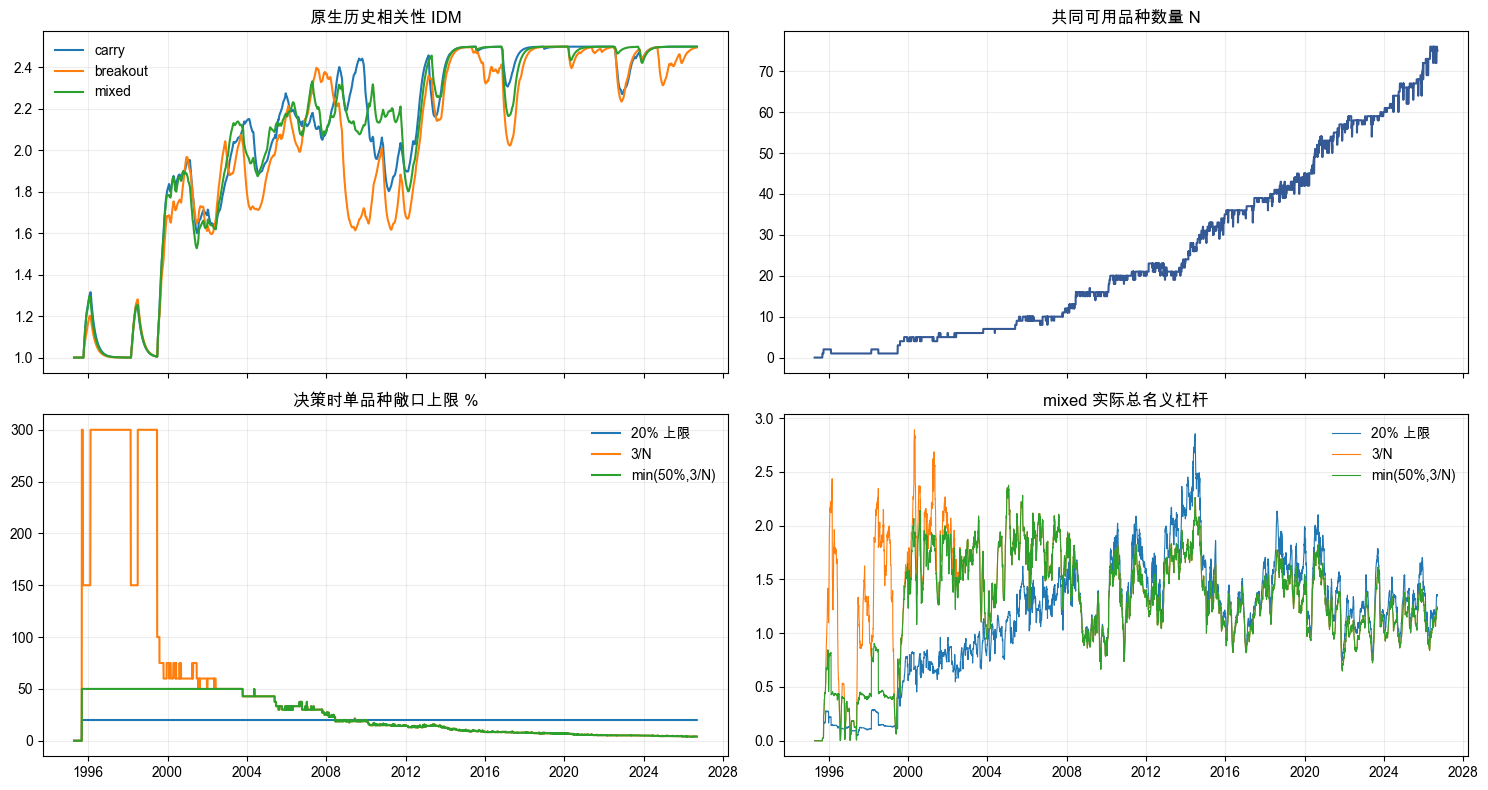

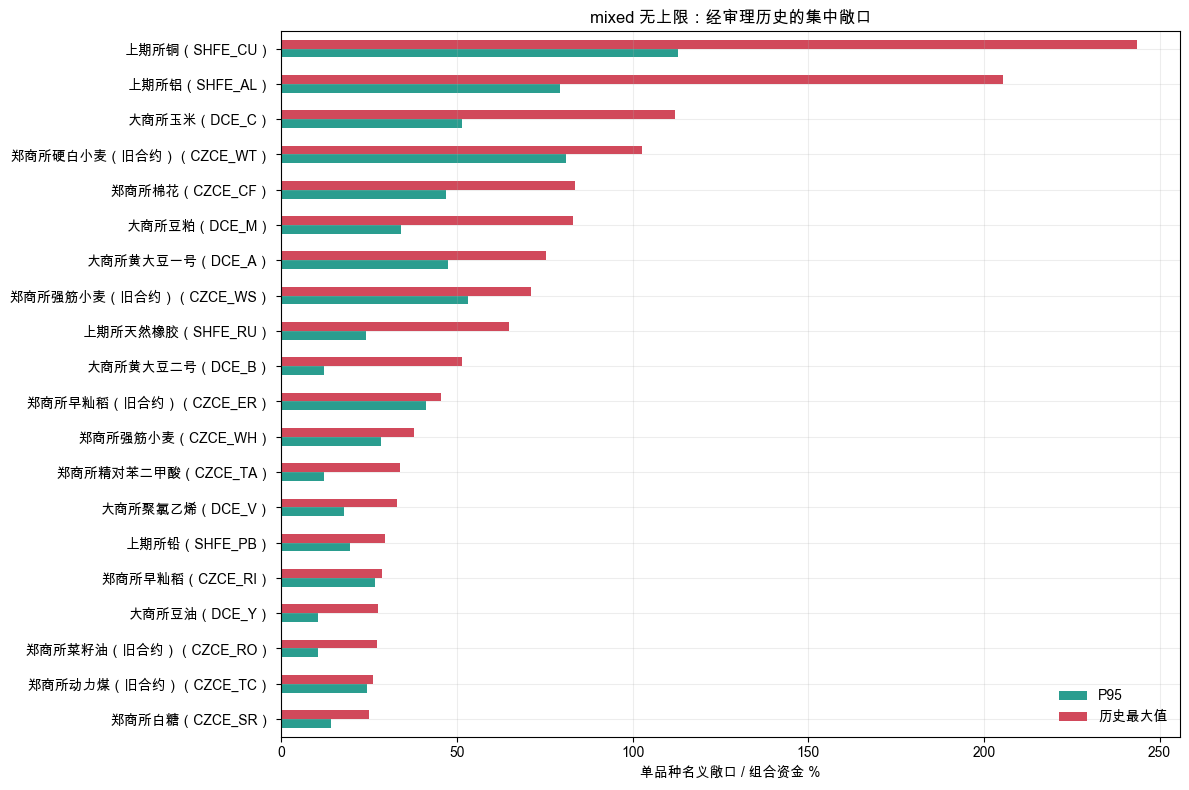

In [85]:
FIGURES = RUN_ROOT/'figures'
labels = CAP_LABELS
colours = dict(zip(CAPS,['#345995','#D1495B','#2A9D8F','#E5A11A','#6A4C93','#0081A7']))
# 无上限、固定上限、自适应上限分别展示，纵轴保持线性。
for title, choices, filename in [
    ('无上限',['unlimited'],'portfolio_unlimited.png'),
    ('固定单品种上限',['cap10','cap20','cap30'],'portfolio_fixed_caps.png'),
    ('数量自适应与20%对照',['cap20','equal3','bounded3'],'portfolio_adaptive_caps.png')]:
    fig, axes = plt.subplots(3,3,figsize=(17,10),sharex=True)
    for column, case in enumerate(CASES):
        for cap_name in choices:
            f = portfolio_frames[(case,cap_name)].loc[lambda x:x.normal]
            for row, metric in enumerate(['multiplier','drawdown_pct','gross_leverage']):
                axes[row,column].plot(f.index,f[metric],label=labels[cap_name],color=colours[cap_name],lw=1.1)
        axes[0,column].set_title(case)
        axes[0,column].legend(fontsize=9)
        for row, ylabel in enumerate(['原生资金乘数','资金峰值回撤 %','总名义敞口 / 资金']):
            axes[row,column].set_ylabel(ylabel)
            axes[row,column].set_yscale('linear')
    fig.suptitle('1亿元初始本金 · '+title+' · 截至 '+AS_OF,fontsize=15)
    fig.tight_layout()
    fig.savefig(FIGURES/filename,bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # 同一组资金曲线同时看线性和对数：原生乘数实线，现金净值虚线。
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
    for column, case in enumerate(CASES):
        for cap_name in choices:
            f = portfolio_frames[(case, cap_name)].loc[lambda x:x.normal]
            for metric, style, meaning in [('multiplier','-','原生'), ('cash_nav_multiple','--','现金')]:
                values = f[metric]
                label = labels[cap_name] + ' · ' + meaning
                axes[0,column].plot(f.index, values, style, color=colours[cap_name], label=label, lw=1.)
                if np.isfinite(values).all() and values.gt(0).all():
                    axes[1,column].plot(f.index, values, style, color=colours[cap_name], label=label, lw=1.)
                else:
                    axes[1,column].text(.02,.04, '含非正值或缺失值的资金曲线未画对数',
                                        transform=axes[1,column].transAxes, fontsize=8)
        for row, scale in enumerate(['linear','log']):
            axes[row,column].set_yscale(scale)
            axes[row,column].set_title(case + (' · 线性' if row == 0 else ' · 普通对数'))
            axes[row,column].set_ylabel('资金倍数')
            axes[row,column].legend(fontsize=7, ncol=2)
    fig.suptitle('1亿元初始本金 · ' + title + ' · 实线原生乘数 / 虚线现金净值')
    fig.tight_layout()
    fig.savefig(FIGURES/filename.replace('.png','_linear_log.png'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

mixed_periods = summary.loc['mixed'].reset_index()
mixed_periods = mixed_periods.loc[~mixed_periods.period.isin(['完整历史','共同期间'])]
fig, axes = plt.subplots(2,2,figsize=(15,9))
for axis, metric, title in zip(axes.flat,
    ['annual_return_pct','max_drawdown_pct','worst_5pct_mean','annual_cost_pct'],
    ['年化平均净收益 %','资金最大回撤 %','最差 5% 日收益均值 %','年化成本 %']):
    table = mixed_periods.pivot(index='period',columns='cap',values=metric).reindex(columns=CAPS)
    table.rename(columns=labels).plot.bar(ax=axis,color=list(colours.values()),width=.82)
    axis.set_title(title)
    axis.tick_params(axis='x',rotation=30)
    axis.set_xlabel('')
    axis.axhline(0,color='black',lw=.6)
fig.suptitle('mixed：固定五年分段，首尾采用可用历史',fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES/'mixed_five_years.png',bbox_inches='tight')
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2,2,figsize=(15,8),sharex=True)
for case in CASES:
    f = portfolio_frames[(case,'unlimited')]
    axes[0,0].plot(f.index,f.idm,label=case)
axes[0,0].set_title('原生历史相关性 IDM')
axes[0,0].legend()
axes[0,1].plot(daily_n.index,daily_n,color='#345995')
axes[0,1].set_title('共同可用品种数量 N')
for cap_name in ['cap20','equal3','bounded3']:
    axes[1,0].plot(INDEX,100*cap_series[cap_name],label=labels[cap_name])
    f=portfolio_frames[('mixed',cap_name)]
    axes[1,1].plot(f.index,f.gross_leverage,label=labels[cap_name],lw=.8)
axes[1,0].set_title('决策时单品种敞口上限 %')
axes[1,1].set_title('mixed 实际总名义杠杆')
axes[1,0].legend(); axes[1,1].legend()
fig.tight_layout()
fig.savefig(FIGURES/'universe_and_limits.png',bbox_inches='tight')
plt.show()
plt.close(fig)

top = exposure.loc[('mixed','unlimited')].nlargest(20,'maximum').sort_values('maximum').copy()
top.index = [metadata.loc[c,'Description']+'（'+c+'）' for c in top.index]
fig, axis = plt.subplots(figsize=(12,8))
(100*top[['p95','maximum']]).rename(columns={'p95':'P95','maximum':'历史最大值'}).plot.barh(ax=axis,color=['#2A9D8F','#D1495B'])
axis.set_xlabel('单品种名义敞口 / 组合资金 %')
axis.set_title('mixed 无上限：经审理历史的集中敞口')
fig.tight_layout()
fig.savefig(FIGURES/'concentration.png',bbox_inches='tight')
plt.show()
plt.close(fig)

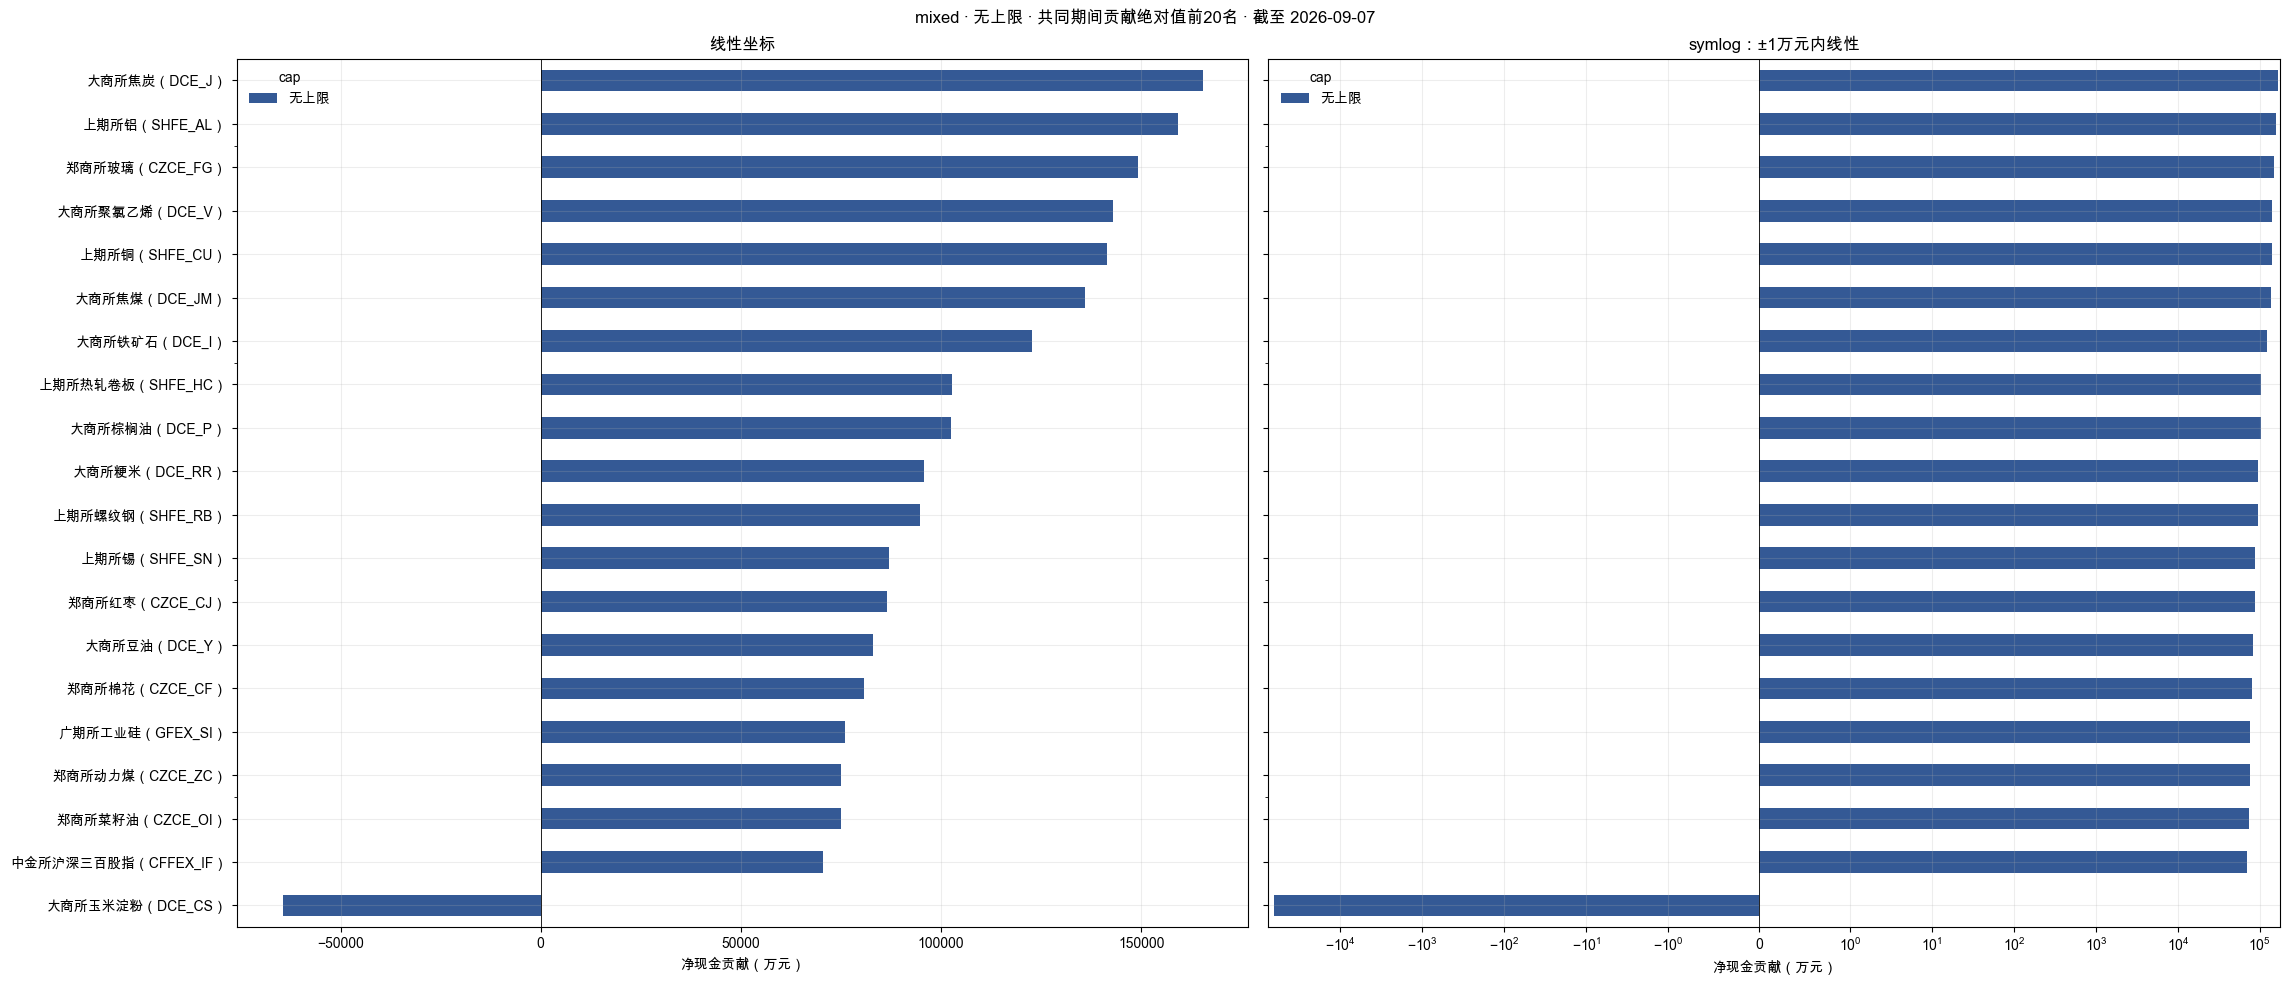

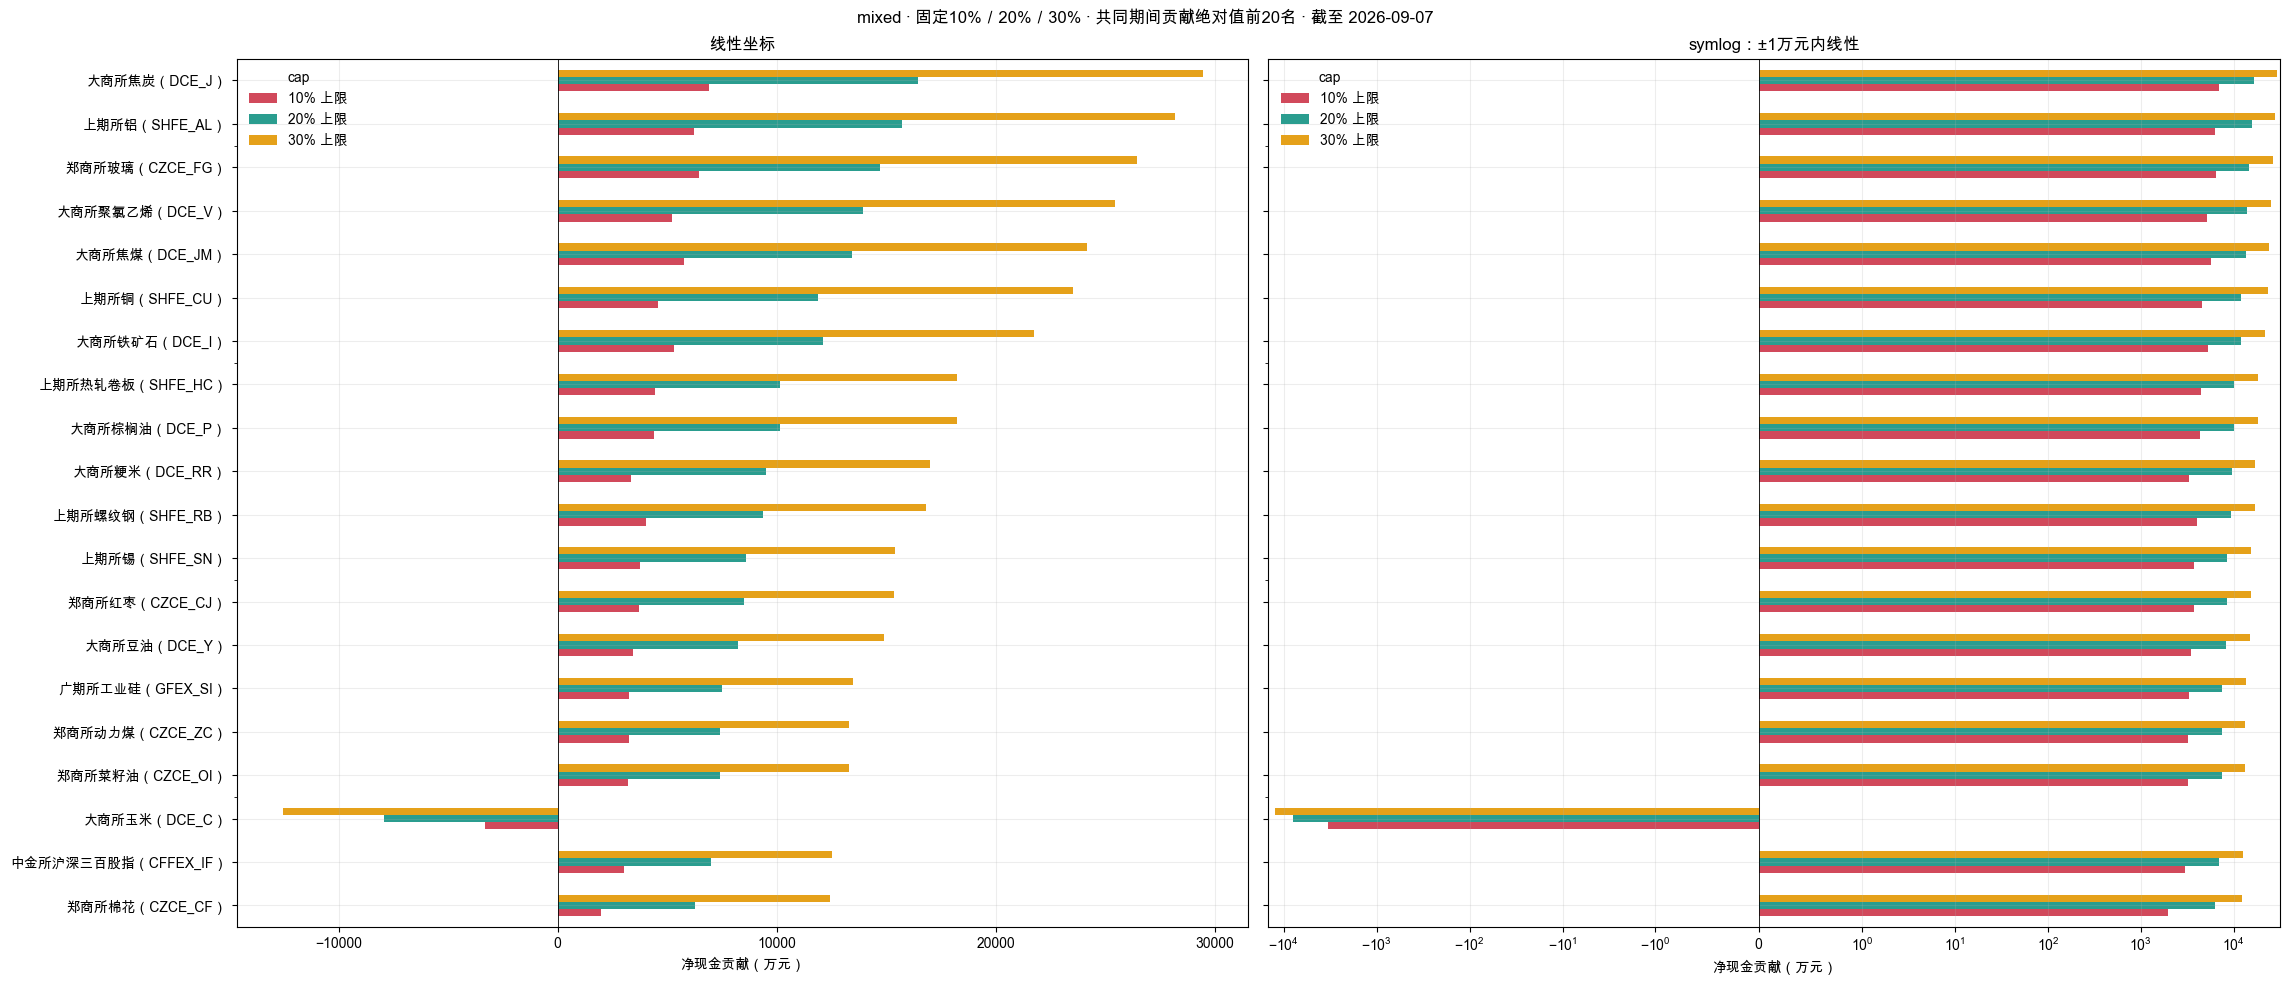

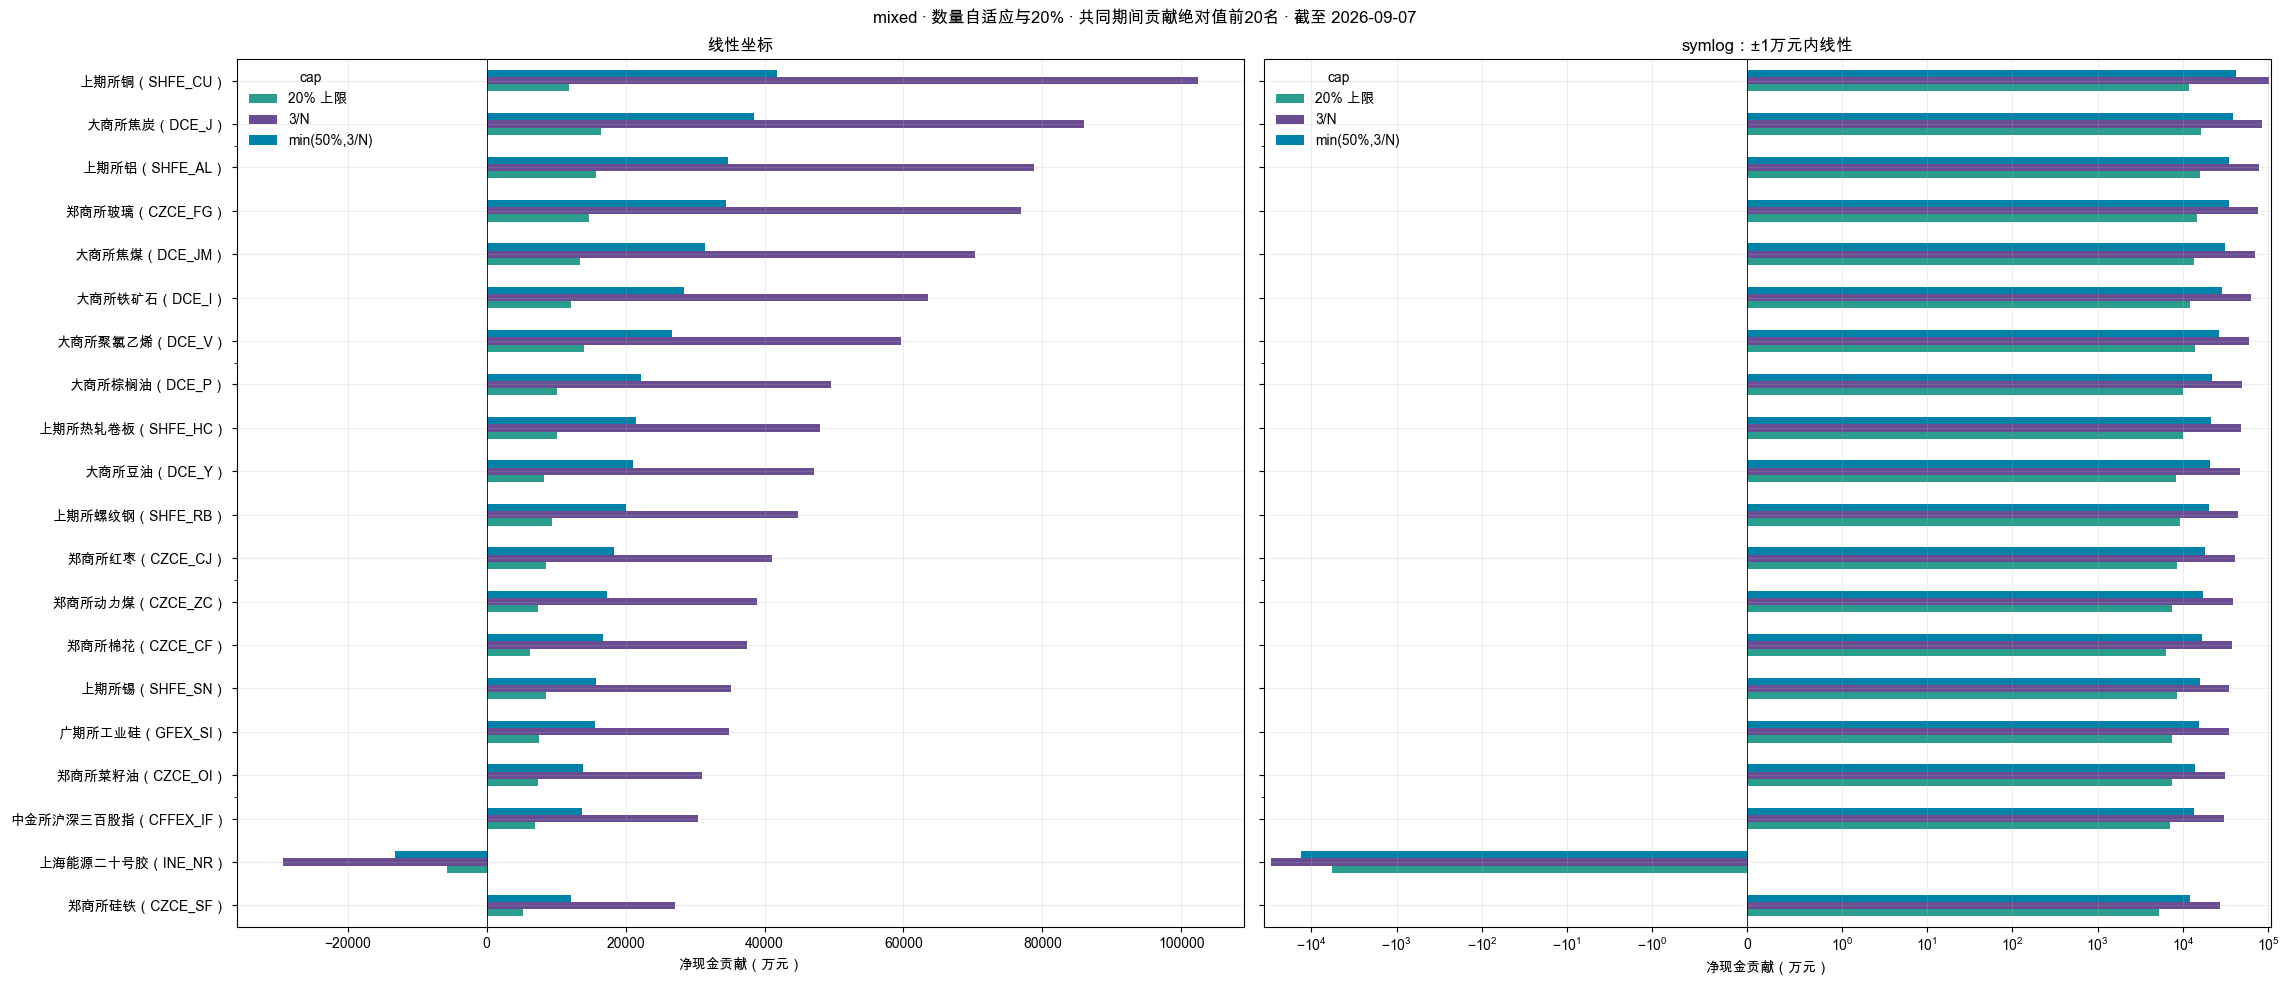

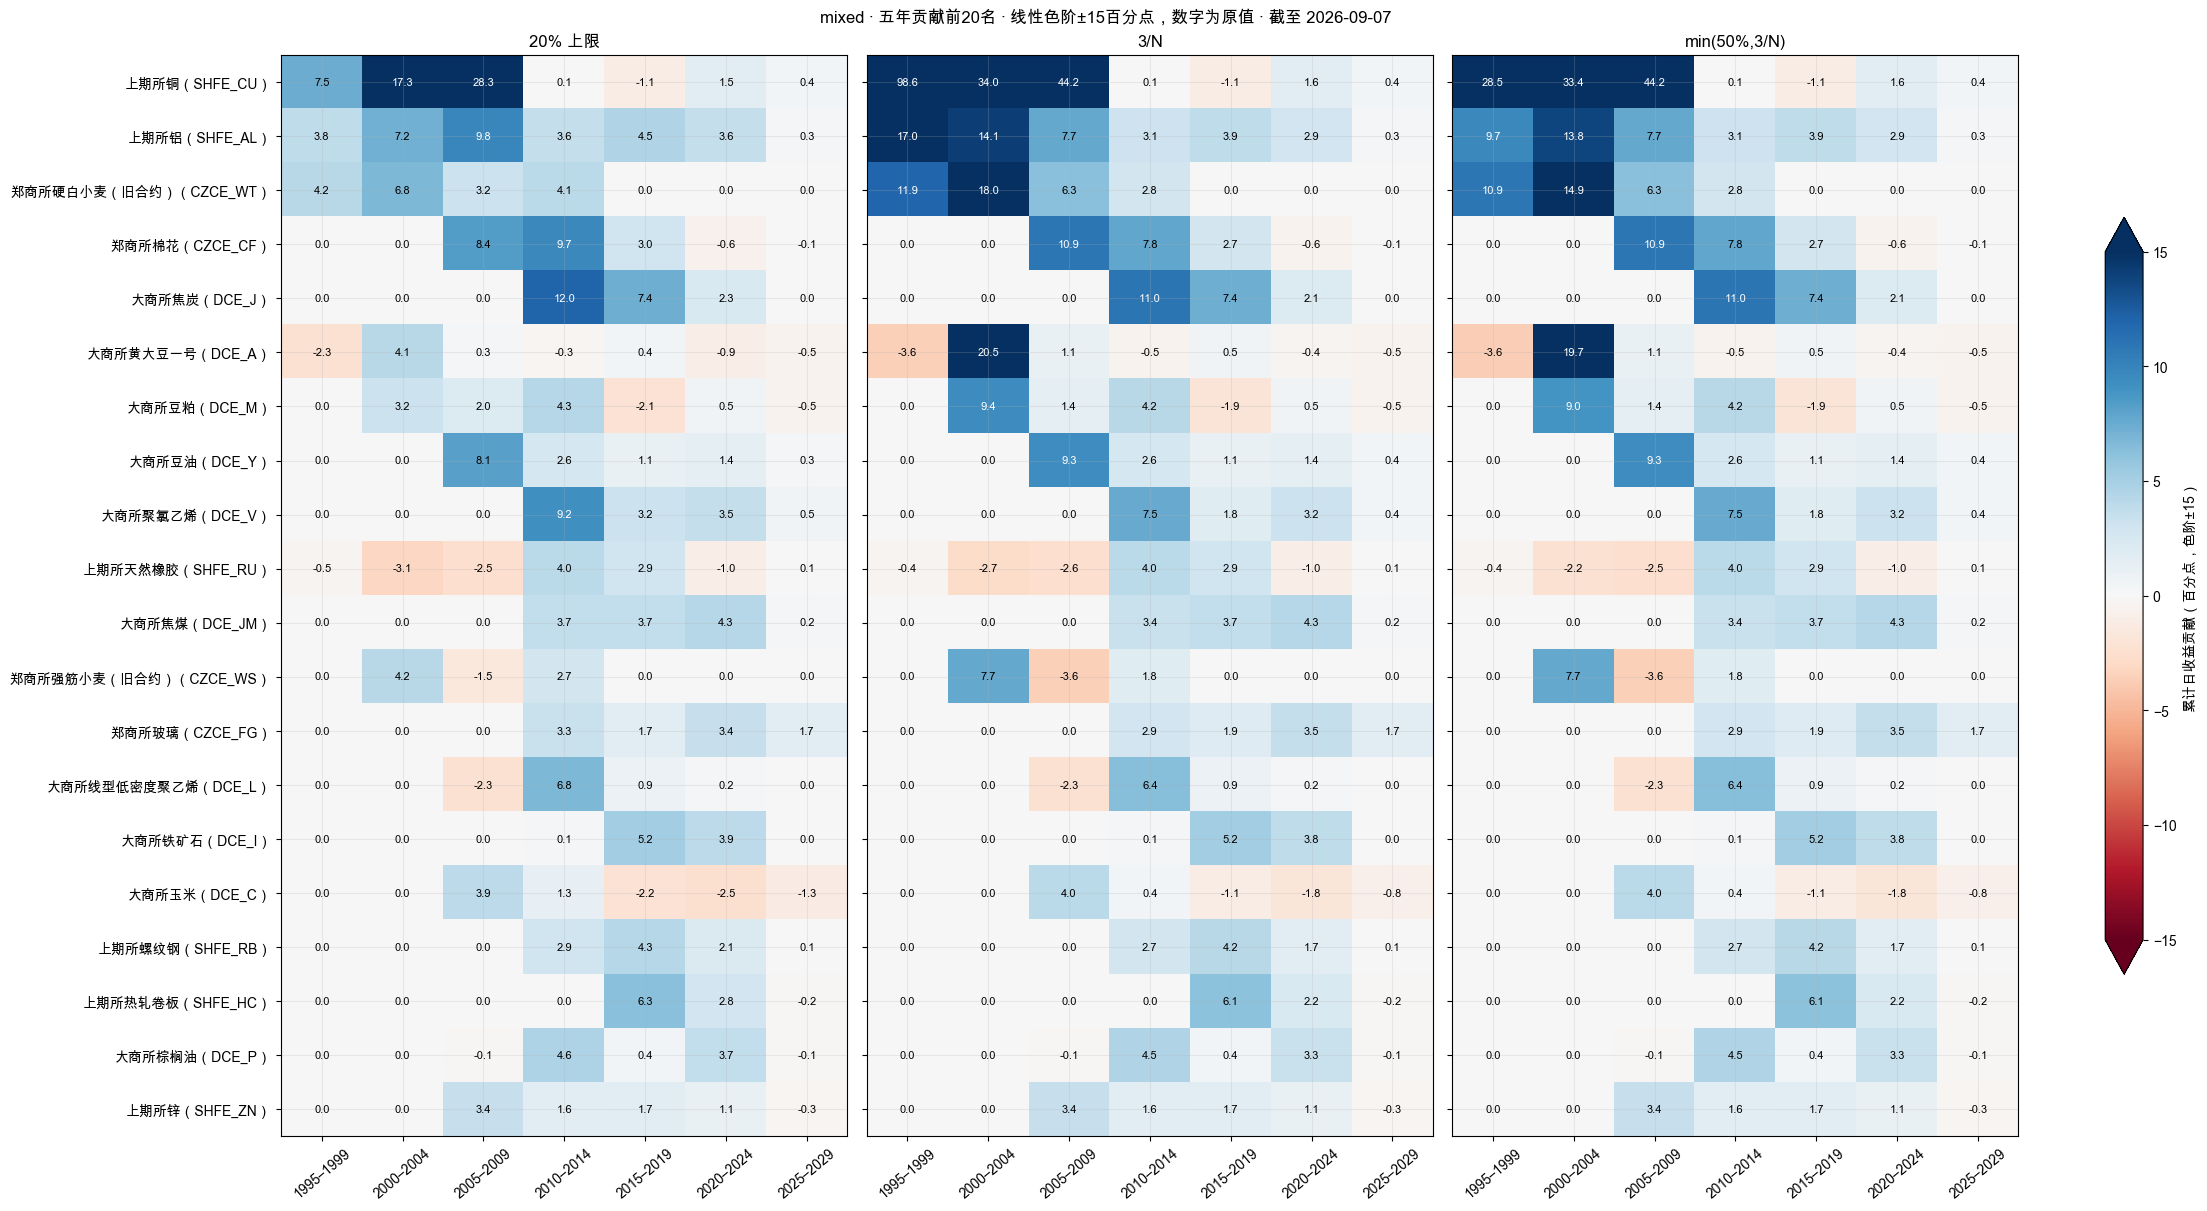

In [86]:
# 每个品种的日收益贡献按当日原生实际资金归一，累计单位为百分点。
contribution_rows = []
for cap_name in CAPS:
    port = portfolio_frames[('mixed',cap_name)]
    periods = [('完整历史',port.index[port.normal]),('共同期间',common_dates)]
    for year in range(1990,2030,5):
        dates = port.index[port.normal & (port.index.year>=year) & (port.index.year<year+5)]
        if len(dates):
            periods.append((f'{year}–{year+4}',dates))
    for period, dates in periods:
        for code in eligible_codes:
            part = instrument_frames[('mixed',cap_name,code)].reindex(dates)
            contribution_rows.append(dict(cap=cap_name,period=period,instrument=code,
                cash_wan=part.net_cnh.sum()/10_000,
                cumulative_daily_pct_points=part.daily_contribution_pct.sum()))
contributions = pd.DataFrame(contribution_rows)
contributions.to_csv(RUN_ROOT/'mixed_period_contributions.csv',index=False)
for title, choices, filename in [
    ('无上限',['unlimited'],'mixed_cash_unlimited.png'),
    ('固定10%／20%／30%',['cap10','cap20','cap30'],'mixed_cash_fixed.png'),
    ('数量自适应与20%',['cap20','equal3','bounded3'],'mixed_cash_adaptive.png')]:
    chosen = contributions.loc[(contributions.period=='共同期间') & contributions.cap.isin(choices)]
    table = chosen.pivot(index='instrument',columns='cap',values='cash_wan').reindex(columns=choices)
    top_codes = table.abs().max(axis=1).nlargest(20).index
    table = table.loc[top_codes].iloc[::-1]
    table.index = [metadata.loc[c,'Description']+'（'+c+'）' for c in table.index]
    fig, axes = plt.subplots(1,2,figsize=(23,10),sharey=True)
    for axis, scale in zip(axes, ['linear','symlog']):
        table.rename(columns=CAP_LABELS).plot.barh(ax=axis,color=[colours[c] for c in choices])
        axis.set_xlabel('净现金贡献（万元）')
        axis.set_title('线性坐标' if scale == 'linear' else 'symlog：±1万元内线性')
        if scale == 'symlog':
            axis.set_xscale('symlog',linthresh=1.)
        axis.axvline(0,color='black',lw=.6)
    fig.suptitle('mixed · '+title+' · 共同期间贡献绝对值前20名 · 截至 '+AS_OF)
    fig.tight_layout()
    fig.savefig(FIGURES/filename,bbox_inches='tight')
    plt.show()
    plt.close(fig)

# 五年分段的贡献使用相同色阶，便于比较不同品种与限额。
selected = contributions.loc[~contributions.period.isin(['完整历史','共同期间'])
                             & contributions.cap.isin(['cap20','equal3','bounded3'])]
top_codes = selected.groupby('instrument').cumulative_daily_pct_points.apply(lambda x:x.abs().sum()).nlargest(20).index
tables = [selected.loc[selected.cap.eq(c)].pivot(index='instrument',columns='period',
          values='cumulative_daily_pct_points').reindex(top_codes).fillna(0.) for c in ['cap20','equal3','bounded3']]
colour_limit = 15.  # 线性色阶在±15百分点饱和，单元格保留真实数值。
fig, axes = plt.subplots(1,3,figsize=(22,12),sharey=True,constrained_layout=True)
for axis, cap_name, table in zip(axes,['cap20','equal3','bounded3'],tables):
    mesh = axis.imshow(table.values,cmap='RdBu',vmin=-colour_limit,vmax=colour_limit,aspect='auto')
    axis.set_xticks(range(len(table.columns)),table.columns,rotation=40)
    axis.set_yticks(range(len(table)),[metadata.loc[c,'Description']+'（'+c+'）' for c in table.index])
    axis.set_title(CAP_LABELS[cap_name])
    for i in range(len(table)):
        for j in range(len(table.columns)):
            axis.text(j,i,f'{table.iloc[i,j]:.1f}',ha='center',va='center',fontsize=8,
                      color='white' if abs(table.iloc[i,j])>.6*colour_limit else 'black')
fig.colorbar(mesh,ax=axes,label='累计日收益贡献（百分点，色阶±15）',shrink=.7,extend='both')
fig.suptitle('mixed · 五年贡献前20名 · 线性色阶±15百分点，数字为原值 · 截至 '+AS_OF)
fig.savefig(FIGURES/'mixed_five_year_contributions.png',bbox_inches='tight')
plt.show()
plt.close(fig)

In [87]:
# 独立重算截断历史，核对波动率和七条规则。
prefix_date = pd.Timestamp('2026-06-30 23:59:59.999999999')
check_rows = []
for code in ['SHFE_RB','DCE_FB','DCE_FB_OLD','CZCE_LR','CZCE_RS']:
    for _, window in trading_windows.loc[trading_windows.Instrument.eq(code)].iterrows():
        if window.Start > prefix_date:
            continue
        selected = pd.DataFrame([window])
        cfg = Config(deepcopy(BASE_CONFIG))
        cfg.instruments = [code]
        cfg.trading_rules = deepcopy(RULES)
        local = System([WindowRawData(),Rules()],ResearchData(windows=selected,end=prefix_date),cfg)
        prices = local.rawdata.get_daily_prices(code)
        vol = local.rawdata.daily_returns_volatility(code)
        pd.testing.assert_series_equal(vol,market[code].used_vol_points.reindex(vol.index),check_names=False)
        assert vol.dropna().ge(VOL_FLOOR_POINTS[code]).all()
        assert vol.iloc[:10].isna().all()
        for name in RULES:
            forecast = local.rules.get_raw_forecast(code,name)
            pd.testing.assert_series_equal(forecast,raw_rule_frames[code][name].reindex(forecast.index),check_names=False)
        check_rows.append({'instrument':code,'start':window.Start,'end':prices.index.max(),'status':'通过'})
        local.data.data.close()
for code in eligible_codes:
    f = market[code]
    assert f.returns.loc[f.window.isna()].isna().all()
    assert not eligibility[code].reindex(f.index).fillna(False).loc[f.window.isna()].any()
    for number in f.window.dropna().unique():
        assert pd.isna(f.loc[f.window.eq(number),'returns'].iloc[0])
for key,part in instrument_frames.items():
    held_allowed = eligibility[key[2]].reindex(part.index).fillna(False).shift(1).fillna(False)
    assert part.held.loc[~held_allowed].eq(0).all()
    assert np.allclose(part.target,part.target.round())
    for boundary in boundaries.loc[boundaries.instrument.eq(key[2])].itertuples():
        if boundary.exit_decision in part.index:
            assert part.at[boundary.exit_decision,'target'] == 0
        if boundary.last_fill in part.index:
            assert part.at[boundary.last_fill,'held'] == 0
    for _, segment in market[key[2]].groupby('window'):
        start = segment.index.min()
        if start in part.index:
            gross_cash = part.at[start,'net_cnh']-part.at[start,'cost_cnh']
            assert np.isclose(gross_cash,0.,atol=1e-8)
# IDM 的完整输入和2022年截断输入，在同一历史前缀应一致。
prefix_date = pd.Timestamp('2022-06-30 23:59:59.999999999')
saved_cutoff = CUTOFF
idms = {}
try:
    for label, limit_date in [('full',saved_cutoff),('prefix',prefix_date)]:
        CUTOFF = limit_date
        cfg = Config(deepcopy(BASE_CONFIG))
        codes = ['SHFE_RB','DCE_FB','CZCE_MA']
        cfg.instruments = codes
        cfg.instrument_weights = {c:1/len(codes) for c in codes}
        cfg.trading_rules = deepcopy(RULES)
        cfg.forecast_weights = deepcopy(WEIGHTS['mixed'])
        with redirect_stdout(StringIO()), warnings.catch_warnings(record=True):
            check = System([Account(),ReportPortfolio(),ReportPositionSizing(),ReportRawData(),
                            ForecastCombine(),ForecastScaleCap(),ReportRules()],ResearchData(),cfg)
            idms[label] = check.portfolio.get_instrument_diversification_multiplier().loc[:prefix_date]
        check.data.data.close()
finally:
    CUTOFF = saved_cutoff
pd.testing.assert_series_equal(idms['full'].reindex(idms['prefix'].index),idms['prefix'],check_names=False,atol=1e-8,rtol=1e-8)
from systems.accounts.account_buffering_subsystem import apply_buffer_single_period
flat = pd.Series(100.,index=pd.bdate_range('2020-01-01',periods=120))
zero = mixed_vol_calc(flat.diff(),days=35,min_periods=10,slow_vol_years=20,
                      proportion_of_slow_vol=.35,vol_abs_min=0.,backfill=False)
assert zero.dropna().eq(0).all()
assert warmed_breakout(flat,lookback=160).iloc[:79].isna().all()
for n in [0,1,2,5,20,72]:
    cap = min(.5,3/n) if n else 0.
    assert n*cap <= 3+1e-12
    for sign in [-1,1]:
        lots = np.floor(cap*1_000_000/(120*10))
        position = np.clip(sign*2000,-lots,lots)
        assert abs(position)*120*10 <= cap*1_000_000+1e-8
        buffered = apply_buffer_single_period(sign*2000,sign*100,lots,-lots,trade_to_edge=True)
        assert abs(buffered) <= lots
assert np.floor(.1*1_000_000/120_000) == 0
assert 83*130*10/900_000 > .1
assert set(excluded_low_vol) == set(coverage.index[coverage.raw_vol_median_pct.lt(5)])
assert all(np.isclose(sum(w.values()),1) for w in WEIGHTS.values())
assert len(portfolio_frames)==18 and len(instrument_frames)==18*len(eligible_codes)
display(pd.DataFrame(check_rows))
print('区间重置、历史截断、IDM、零波动、整手、多空、buffer和18组账户归因检查通过。')
assert all(hashlib.sha256(Path(path).read_bytes()).hexdigest() == digest
           for path,digest in input_hashes.items())
print('冻结输入内容核对通过：',len(input_hashes),'个文件。')
chinese_names = raw_data.db_futures_instrument_data.get_all_instrument_data_as_df().loc[mapping.Instrument,'Description']
assert len(chinese_names)==99
assert chinese_names.str.contains('[一-鿿]').all()
assert not chinese_names.str.contains('[A-Za-z]').any()
assert all(frame.index.max() <= CUTOFF for frame in market.values())
print('99个中文描述及固定截止日核对通过。')

,instrument,start,end,status
0,SHFE_RB,2009-10-16,2026-06-30,通过
1,DCE_FB,2019-12-02,2024-12-31,通过
2,DCE_FB,2025-01-14,2025-06-03,通过
3,DCE_FB,2025-06-06,2026-06-30,通过
4,DCE_FB_OLD,2014-03-17,2015-05-11,通过
5,DCE_FB_OLD,2018-11-22,2019-10-11,通过
6,CZCE_LR,2014-07-08,2015-01-15,通过
7,CZCE_LR,2018-05-03,2019-03-12,通过
8,CZCE_RS,2012-12-28,2013-09-10,通过
9,CZCE_RS,2014-04-28,2014-10-16,通过


区间重置、历史截断、IDM、零波动、整手、多空、buffer和18组账户归因检查通过。
冻结输入内容核对通过： 195 个文件。
99个中文描述及固定截止日核对通过。


In [107]:
# 区间函数的首日收益、日期边界和非正资金检查。
toy_dates = pd.bdate_range('2020-01-01', periods=3)
toy = pd.DataFrame({'normal': True, 'net_pct': [10., -10., 20.],
                    'cash_nav_multiple': [1.1, .99, 1.188],
                    'multiplier': [1.1, .99, 1.188]}, index=toy_dates)
toy_curves, toy_stats = period_data(toy, toy_dates[1], toy_dates[2])
np.testing.assert_allclose(toy_curves.cash_nav, [.9, 1.08])
np.testing.assert_allclose(toy_stats['现金净值累计收益%'], 8.)
np.testing.assert_allclose(toy_stats['现金净值最大回撤%'], -10.)
np.testing.assert_allclose(toy_stats['现金净值CAGR%'], 100*(1.08**(256/2)-1))
_, one_day = period_data(toy, toy_dates[0], toy_dates[0])
np.testing.assert_allclose(one_day['现金净值累计收益%'], 10.)
assert one_day['业务日数'] == 1
for start, end in [('2020-01-05','2020-01-01'), ('2021-01-01','2021-01-02'),
                   ('2020-01-04','2020-01-05')]:
    try:
        period_data(toy, start, end)
    except ValueError:
        pass
    else:
        raise AssertionError('倒置日期或无业务日区间应报错')
clipped, _ = period_data(toy, '2010-01-01', '2030-01-01')
assert clipped.index.equals(toy_dates)
nonpositive = toy.copy()
nonpositive['cash_nav_multiple'] = [1.1, 0., -.1]
bad_curves, bad_stats = period_data(nonpositive, toy_dates[0], toy_dates[-1])
assert pd.isna(bad_stats['现金净值CAGR%'])
edge_figure = plot_funds(bad_curves, '边界验证：现金净值非正时只画线性')
assert len(edge_figure.axes[0].lines) == 2 and len(edge_figure.axes[1].lines) == 1
plt.close(edge_figure)
for row in annual_statistics.itertuples(index=False):
    f = portfolio_frames[(row.strategy, row.cap)]
    selected = f.loc[f.normal & (f.index.year == row.year)]
    expected = ANNUAL_DAYS * selected.net_pct.mean()
    actual = annual_statistics.loc[(annual_statistics.strategy == row.strategy) &
             (annual_statistics.cap == row.cap) & (annual_statistics.year == row.year), '年化平均净收益%'].iloc[0]
    np.testing.assert_allclose(actual, expected)
assert annual_statistics.loc[annual_statistics.year.eq(2026), '年度说明'].eq('未完整年度').all()
signed = pd.Series([-100., -1., 0., 1., 100.])
fig, axes = plt.subplots(1,2,figsize=(8,3))
for axis, scale in zip(axes, ['linear','symlog']):
    axis.plot(signed.index, signed.values)
    if scale == 'symlog':
        axis.set_yscale(scale, linthresh=1.)
    np.testing.assert_allclose(axis.lines[0].get_ydata(), signed)
plt.close(fig)
assert all(hashlib.sha256(Path(path).read_bytes()).hexdigest() == digest
           for path, digest in input_hashes.items())
# 验证重新打开notebook时的磁盘读取路径，保持当前内存结果不变。
from unittest.mock import patch
expected_curves, expected_stats = period_data(portfolio_frames[('mixed','cap20')], '2021-01-01', '2025-12-31')
with patch.dict(portfolio_frames, {}, clear=True), patch.object(plt, 'show'):
    disk_curves, disk_stats = show_period('2021-01-01', '2025-12-31')
# Parquet不保存DatetimeIndex.freq，比较日期和值，忽略此元数据。
pd.testing.assert_frame_equal(disk_curves, expected_curves, check_freq=False)
pd.testing.assert_series_equal(disk_stats, expected_stats)
print('通过：区间首日收益、单日/空区间/倒置日期、CAGR、非正净值、年度一致性、磁盘读取及冻结输入哈希。')

,区间统计
实际开始,2021-01-01 00:00:00
实际结束,2025-12-31 00:00:00
业务日数,1304
年化平均净收益%,6.5483
账户全程正常,True
现金净值累计收益%,37.2927
现金净值CAGR%,6.4199
现金净值最大回撤%,-14.2813
原生乘数累计收益%,37.3993
原生乘数CAGR%,6.4361


通过：区间首日收益、单日/空区间/倒置日期、CAGR、非正净值、年度一致性、磁盘读取及冻结输入哈希。


## 逐品种图册

全部95品种的价格、波动率、forecast、敞口和贡献图保存在本地结果目录。Notebook内展示螺纹钢、纤维板和沪深300股指；完整图册为 `portfolio_capital_100m/instrument_atlas.html`。分批执行可按需更新对应品种。

In [108]:
def plot_instrument(code):
    m = market[code]
    fig, axes = plt.subplots(5,2,figsize=(14,14),sharex=True)
    ax = axes.ravel()
    ax[0].plot(m.index,m.adjusted_price,color='#345995',lw=1,marker='o' if m.adjusted_price.count()==1 else None)
    ax[1].plot(m.index,m.price,color='#345995',lw=1,marker='o' if m.price.count()==1 else None)
    ax[2].plot(m.index,m.raw_vol_pct,label='原始波动率',lw=1)
    ax[2].plot(m.index,m.used_vol_pct,label='应用下限后',lw=1)
    ax[2].legend(fontsize=8)
    ax[2].axhline(5,color='gray',ls='--',lw=.8)
    titles = ['加法复权价格','未复权合约价格','品种年化波动率 %','三组 forecast',
              'mixed：固定上限实际敞口 %','mixed：自适应实际敞口 %',
              'mixed 无上限：累计净贡献 / 万元','mixed 固定上限：累计净贡献 / 万元',
              'mixed 自适应：累计净贡献 / 万元','共同期间累计日收益贡献 / 百分点']
    for a,title in zip(ax,titles):
        a.set_title(title)
    if m.adjusted_price.count()==0:
        for a in ax[:3]:
            a.text(.5,.5,'无已审核活跃区间',transform=a.transAxes,ha='center',va='center')
    if code in eligible_codes:
        for case in CASES:
            forecast = forecast_frames[(case,code)].reindex(m.index).where(m.window.notna())
            ax[3].plot(forecast.index,forecast,label=case,lw=.9)
        for cap_name in CAPS:
            part = instrument_frames[('mixed',cap_name,code)]
            normal = portfolio_frames[('mixed',cap_name)].normal.reindex(part.index).fillna(False)
            cash = part.net_cnh.where(normal).cumsum()/10_000
            if cap_name=='unlimited':
                ax[6].plot(part.index,cash,label='无上限',color=colours[cap_name],lw=1)
            if cap_name in ['cap10','cap20','cap30']:
                ax[4].plot(part.index,100*part.leverage.where(normal),label=labels[cap_name],color=colours[cap_name],lw=.9)
                ax[7].plot(part.index,cash,label=labels[cap_name],color=colours[cap_name],lw=.9)
            if cap_name in ['cap20','equal3','bounded3']:
                ax[5].plot(part.index,100*part.leverage.where(normal),label=labels[cap_name],color=colours[cap_name],lw=.9)
                ax[8].plot(part.index,cash,label=labels[cap_name],color=colours[cap_name],lw=.9)
                common = part.daily_contribution_pct.reindex(common_dates).fillna(0).cumsum()
                ax[9].plot(common.index,common,label=labels[cap_name],color=colours[cap_name],lw=.9)
        for a in ax[3:]:
            a.legend(fontsize=8,ncol=2)
    else:
        for a in ax[3:]:
            a.text(.5,.5,coverage.loc[code,'decision'],transform=a.transAxes,ha='center',va='center')
    for a in ax:
        a.set_yscale('linear')
        a.set_xlabel('')
        a.tick_params(axis='x',rotation=20)
    first_date, last_date = m.index.min(), m.index.max()
    margin = pd.Timedelta(days=max(30,int((last_date-first_date).days*.03)))
    ax[0].set_xlim(first_date-margin,last_date+margin)
    description = metadata.loc[code,'Description']
    fig.suptitle(f'{description}（{code}） · {coverage.loc[code,"decision"]} · 报价 {coverage.loc[code,"observed_days"]} 日 · 可用业务日 {coverage.loc[code,"eligible_decision_days"]}',fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES/(code+'.png'),bbox_inches='tight')
    if code in ['SHFE_RB','DCE_FB','CFFEX_IF']:
        plt.show()
    plt.close(fig)
    # 贡献可以为负：双坐标只改变展示尺度，不平移、不删负数、不构造虚拟本金。
    fig, axes = plt.subplots(4, 2, figsize=(15, 13), sharex=True)
    groups = [
        ('mixed 无上限：累计净贡献 / 万元', ['unlimited'], 'cash', 1.),
        ('mixed 固定上限：累计净贡献 / 万元', ['cap10','cap20','cap30'], 'cash', 1.),
        ('mixed 自适应：累计净贡献 / 万元', ['cap20','equal3','bounded3'], 'cash', 1.),
        ('共同期间累计日收益贡献 / 百分点', ['cap20','equal3','bounded3'], 'pct', .1),
    ]
    for row, (title, choices, measure, threshold) in enumerate(groups):
        for column, scale in enumerate(['linear', 'symlog']):
            axis = axes[row,column]
            if code in eligible_codes:
                for cap_name in choices:
                    part = instrument_frames[('mixed',cap_name,code)]
                    if measure == 'cash':
                        normal = portfolio_frames[('mixed',cap_name)].normal.reindex(part.index).fillna(False)
                        values = part.net_cnh.where(normal).cumsum()/10_000
                    else:
                        values = part.daily_contribution_pct.reindex(common_dates).fillna(0).cumsum()
                    axis.plot(values.index, values, label=labels[cap_name], color=colours[cap_name], lw=1.)
                axis.legend(fontsize=8,ncol=2)
            else:
                axis.text(.5,.5,coverage.loc[code,'decision'],transform=axis.transAxes,ha='center')
            if scale == 'symlog':
                axis.set_yscale('symlog', linthresh=threshold)
            axis.axhline(0,color='gray',lw=.6)
            suffix = '线性' if scale == 'linear' else f'symlog：±{threshold:g}内线性'
            axis.set_title(title + ' · ' + suffix,fontsize=10)
            axis.tick_params(axis='x',rotation=20)
    axes[0,0].set_xlim(first_date-margin,last_date+margin)
    fig.suptitle(f'{description}（{code}） · 初始本金1亿元 · 累计贡献双坐标',fontsize=14)
    fig.tight_layout()
    fig.savefig(FIGURES/(code+'_contribution_scales.png'),bbox_inches='tight')
    if code in ['SHFE_RB','DCE_FB','CFFEX_IF']:
        plt.show()
    plt.close(fig)

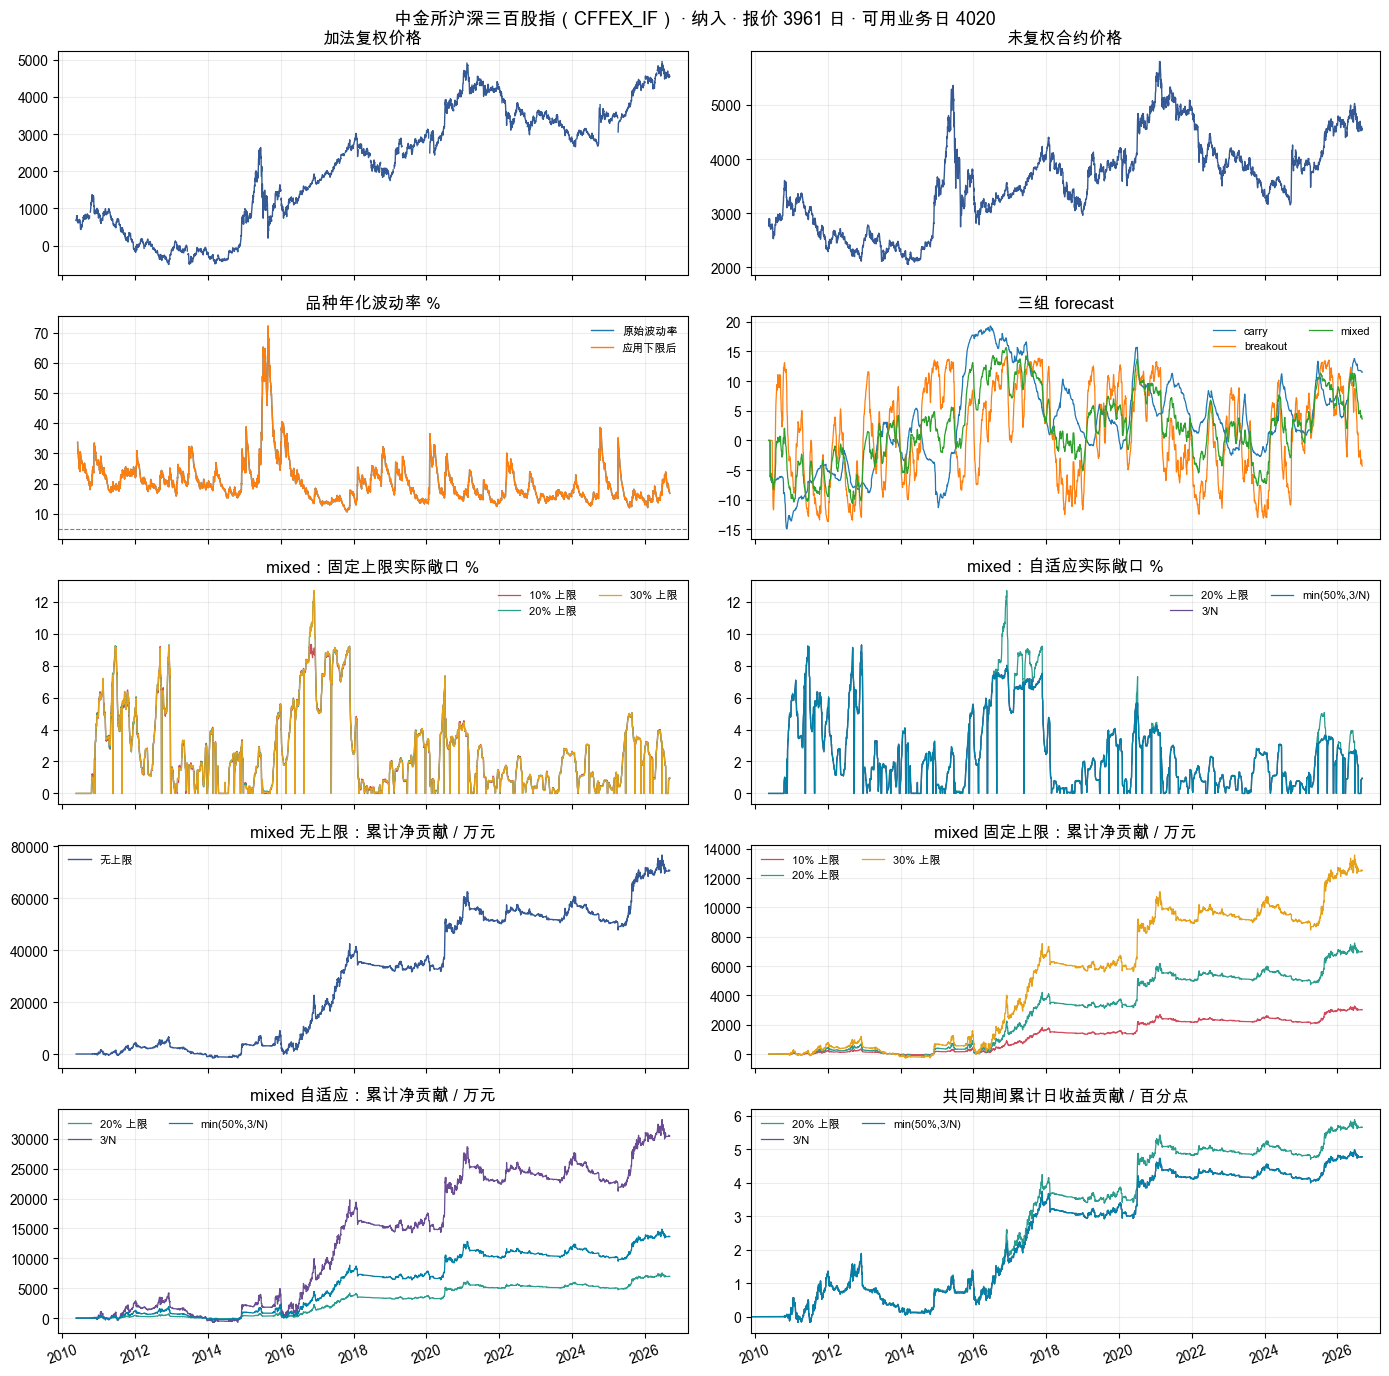

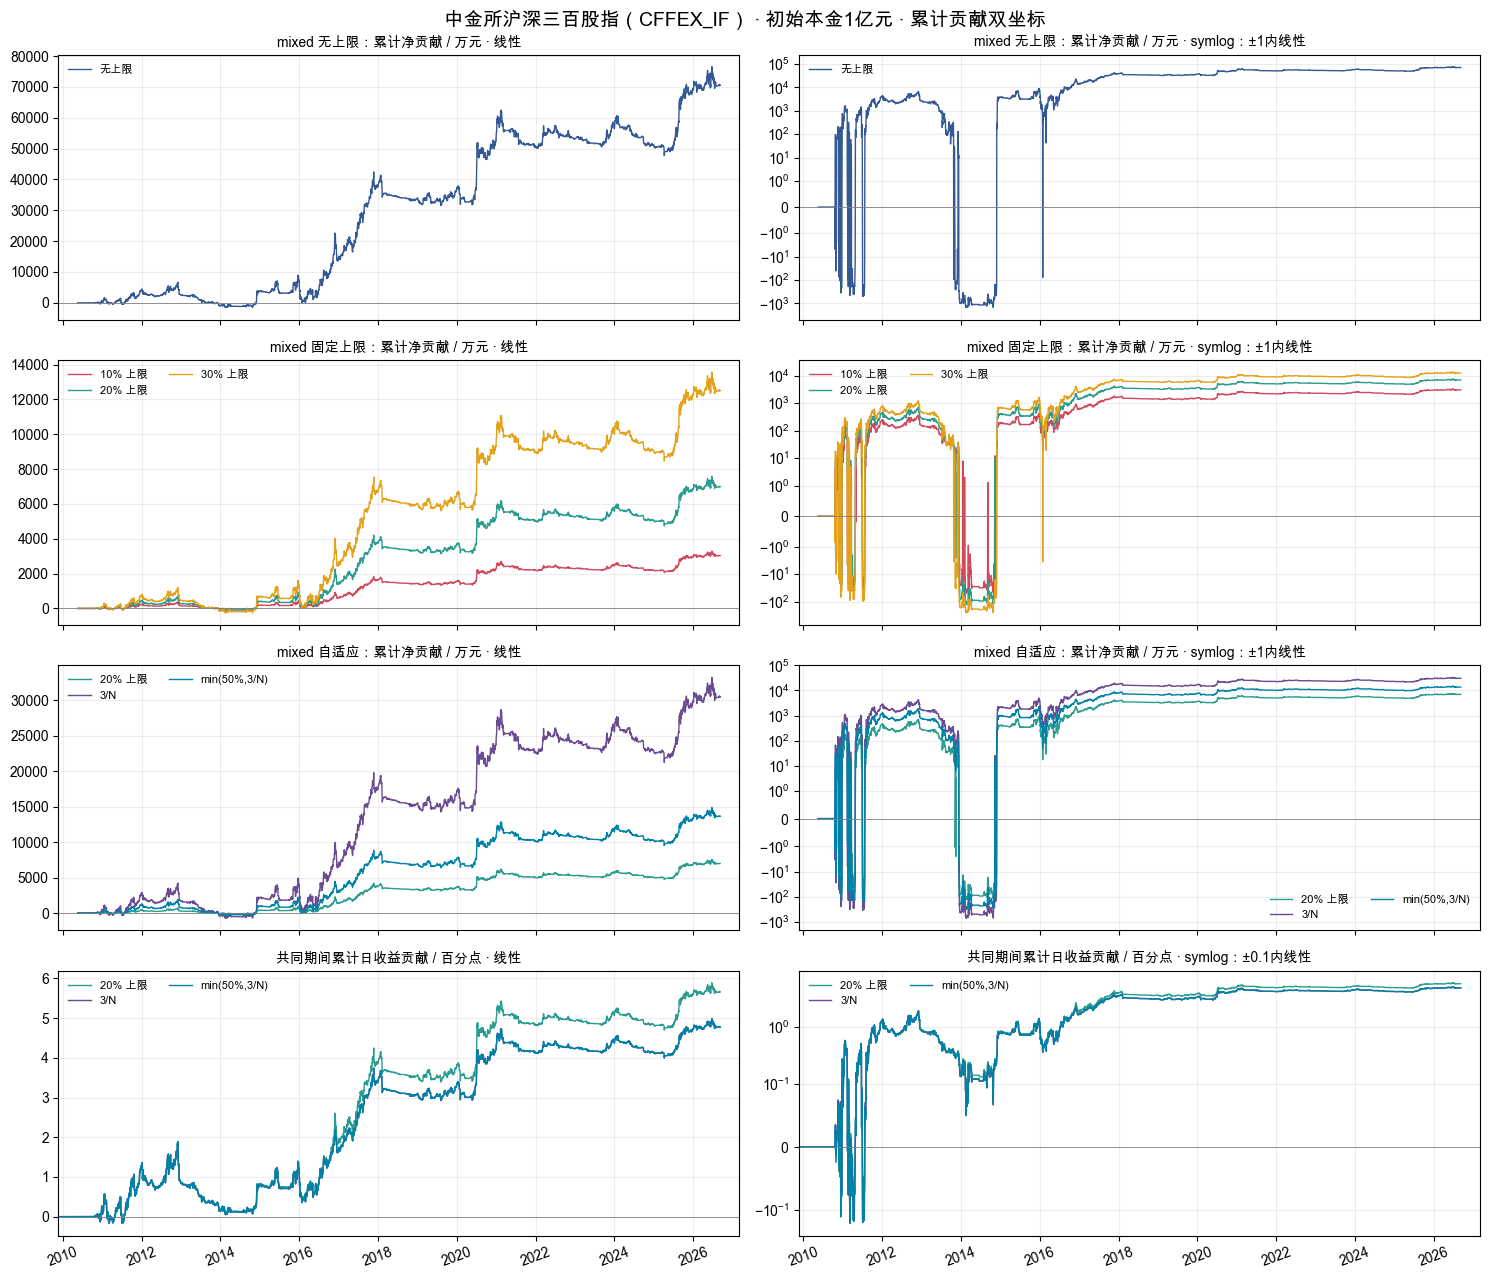

In [109]:
for code in instruments[0:12]:
    plot_instrument(code)

In [110]:
for code in instruments[12:24]:
    plot_instrument(code)

In [111]:
for code in instruments[24:36]:
    plot_instrument(code)

In [112]:
for code in instruments[36:48]:
    plot_instrument(code)

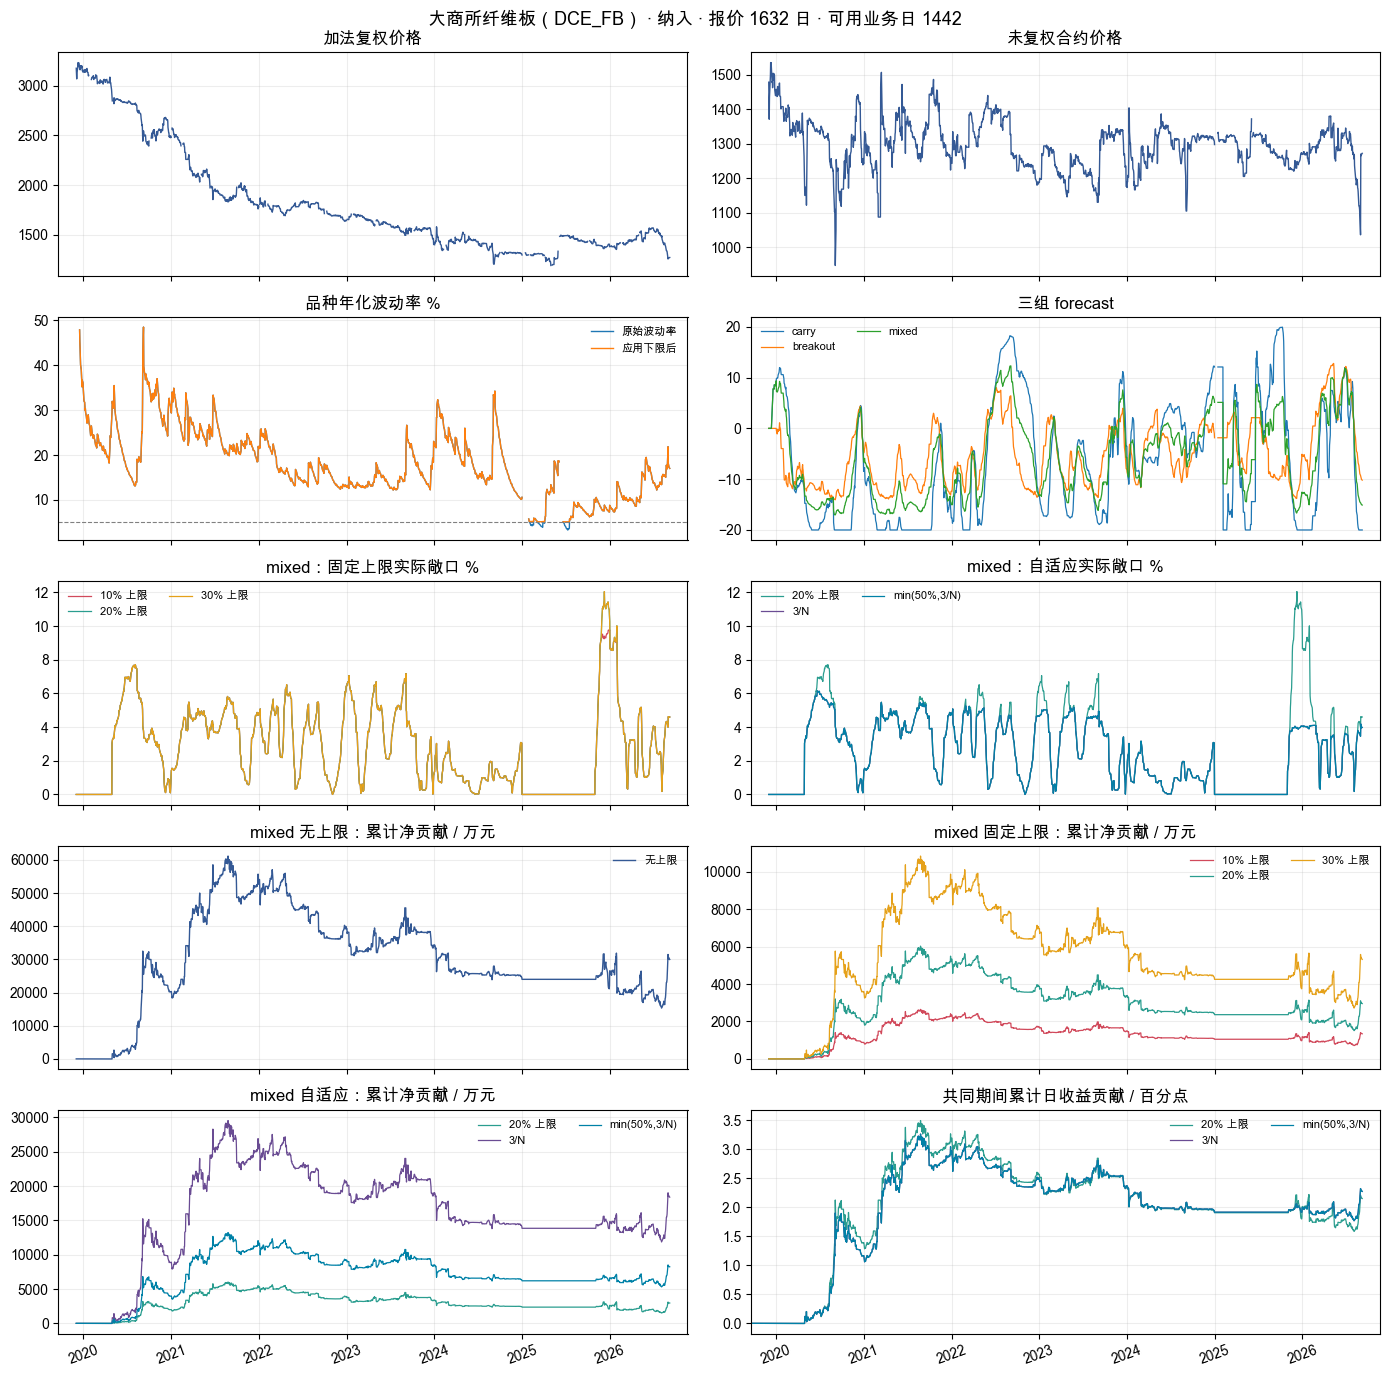

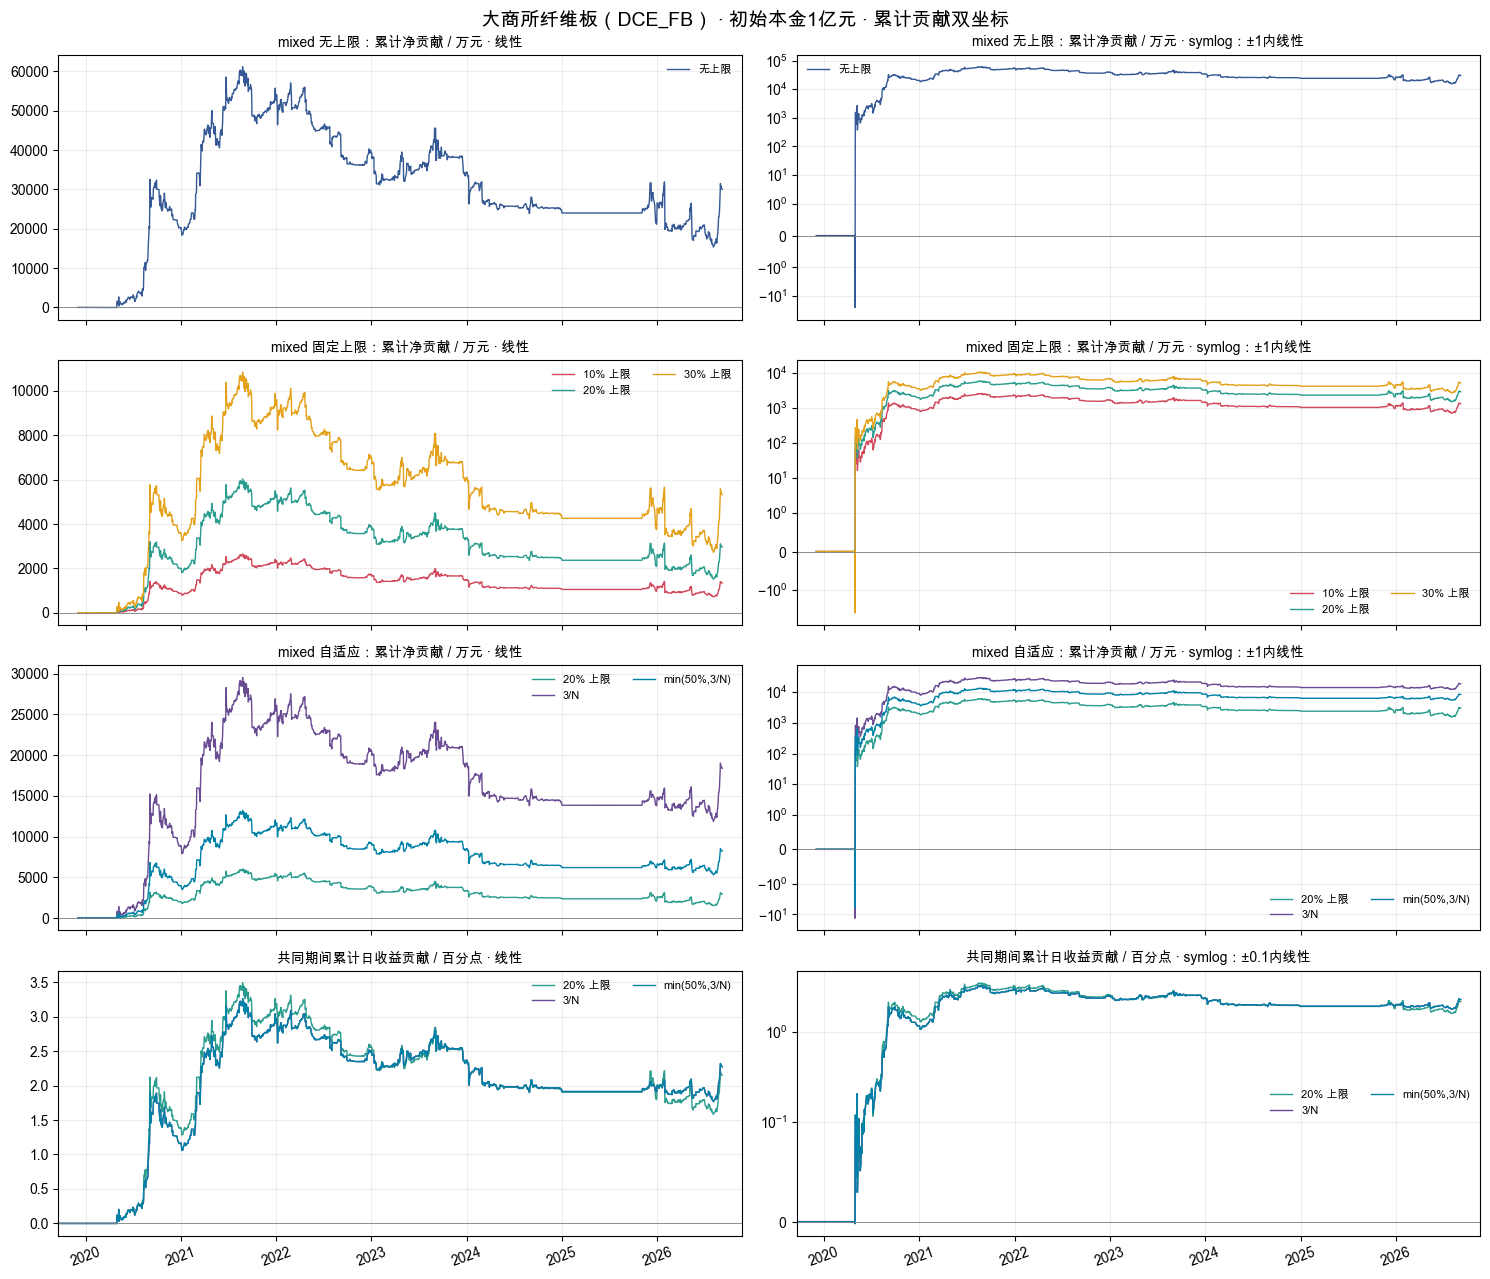

In [113]:
for code in instruments[48:60]:
    plot_instrument(code)

In [114]:
for code in instruments[60:72]:
    plot_instrument(code)

In [115]:
for code in instruments[72:84]:
    plot_instrument(code)

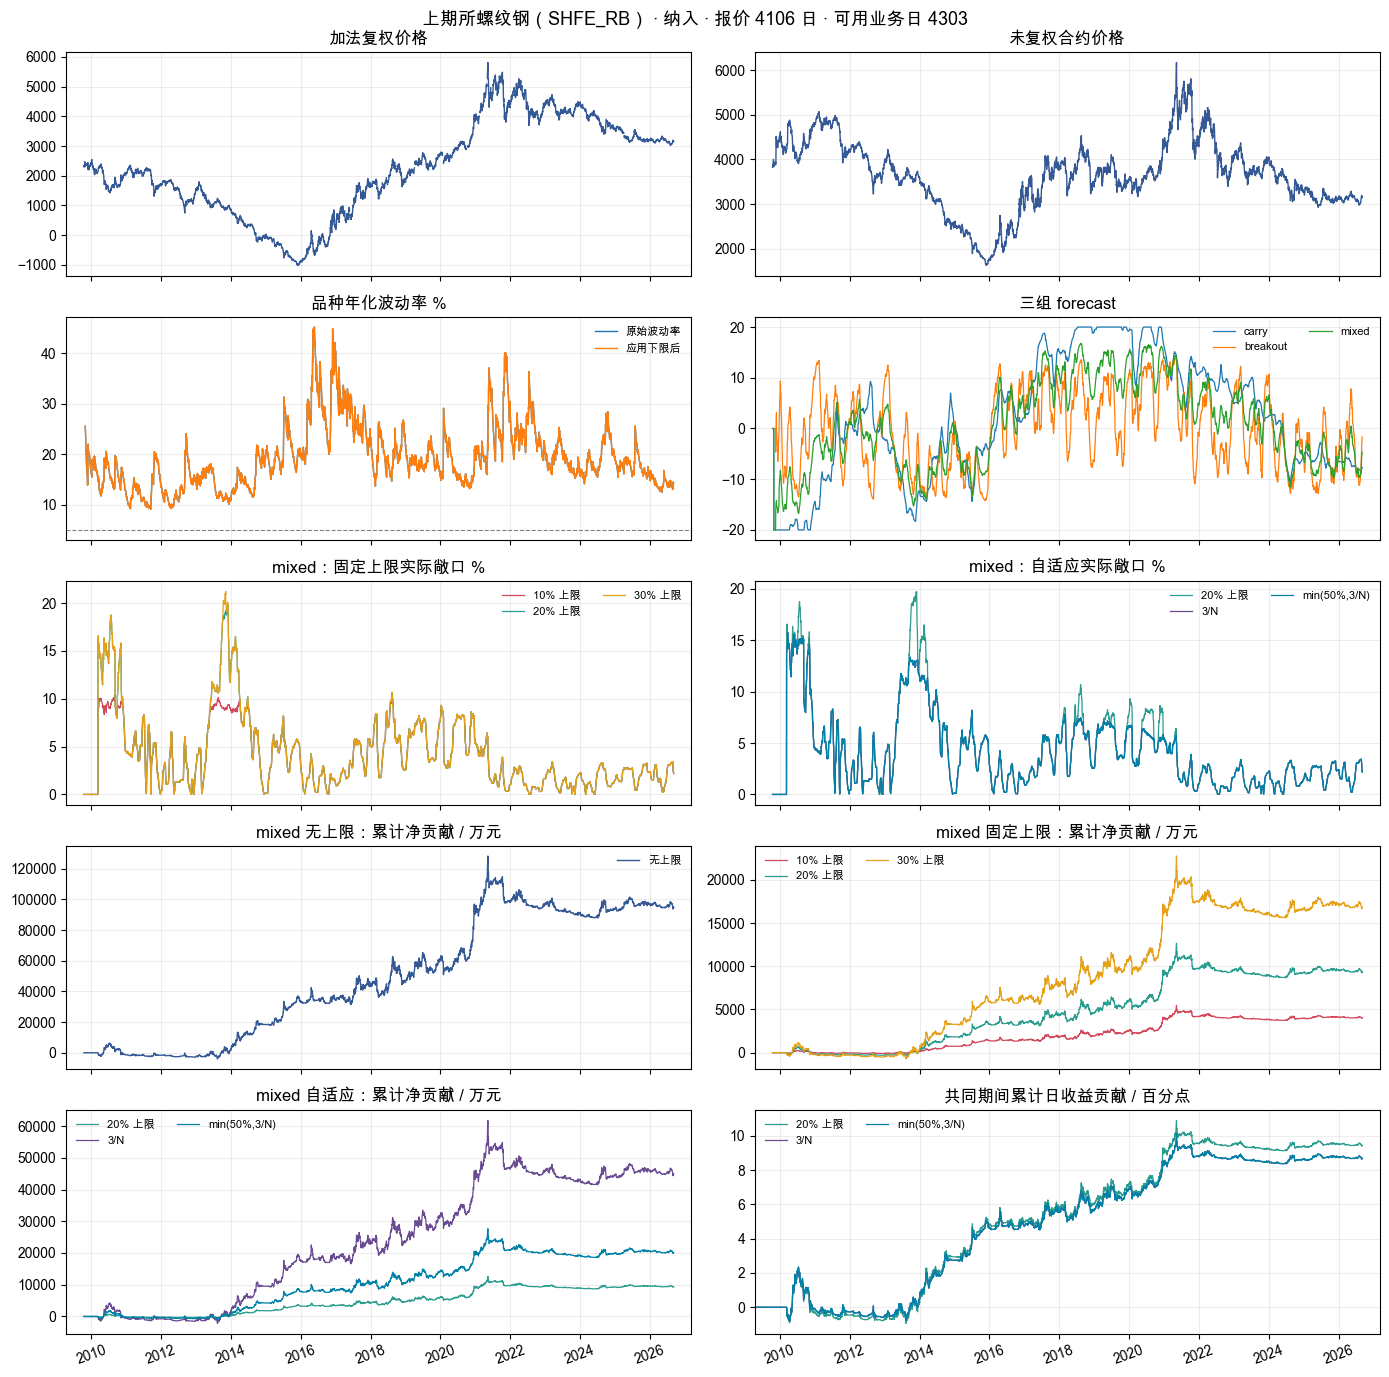

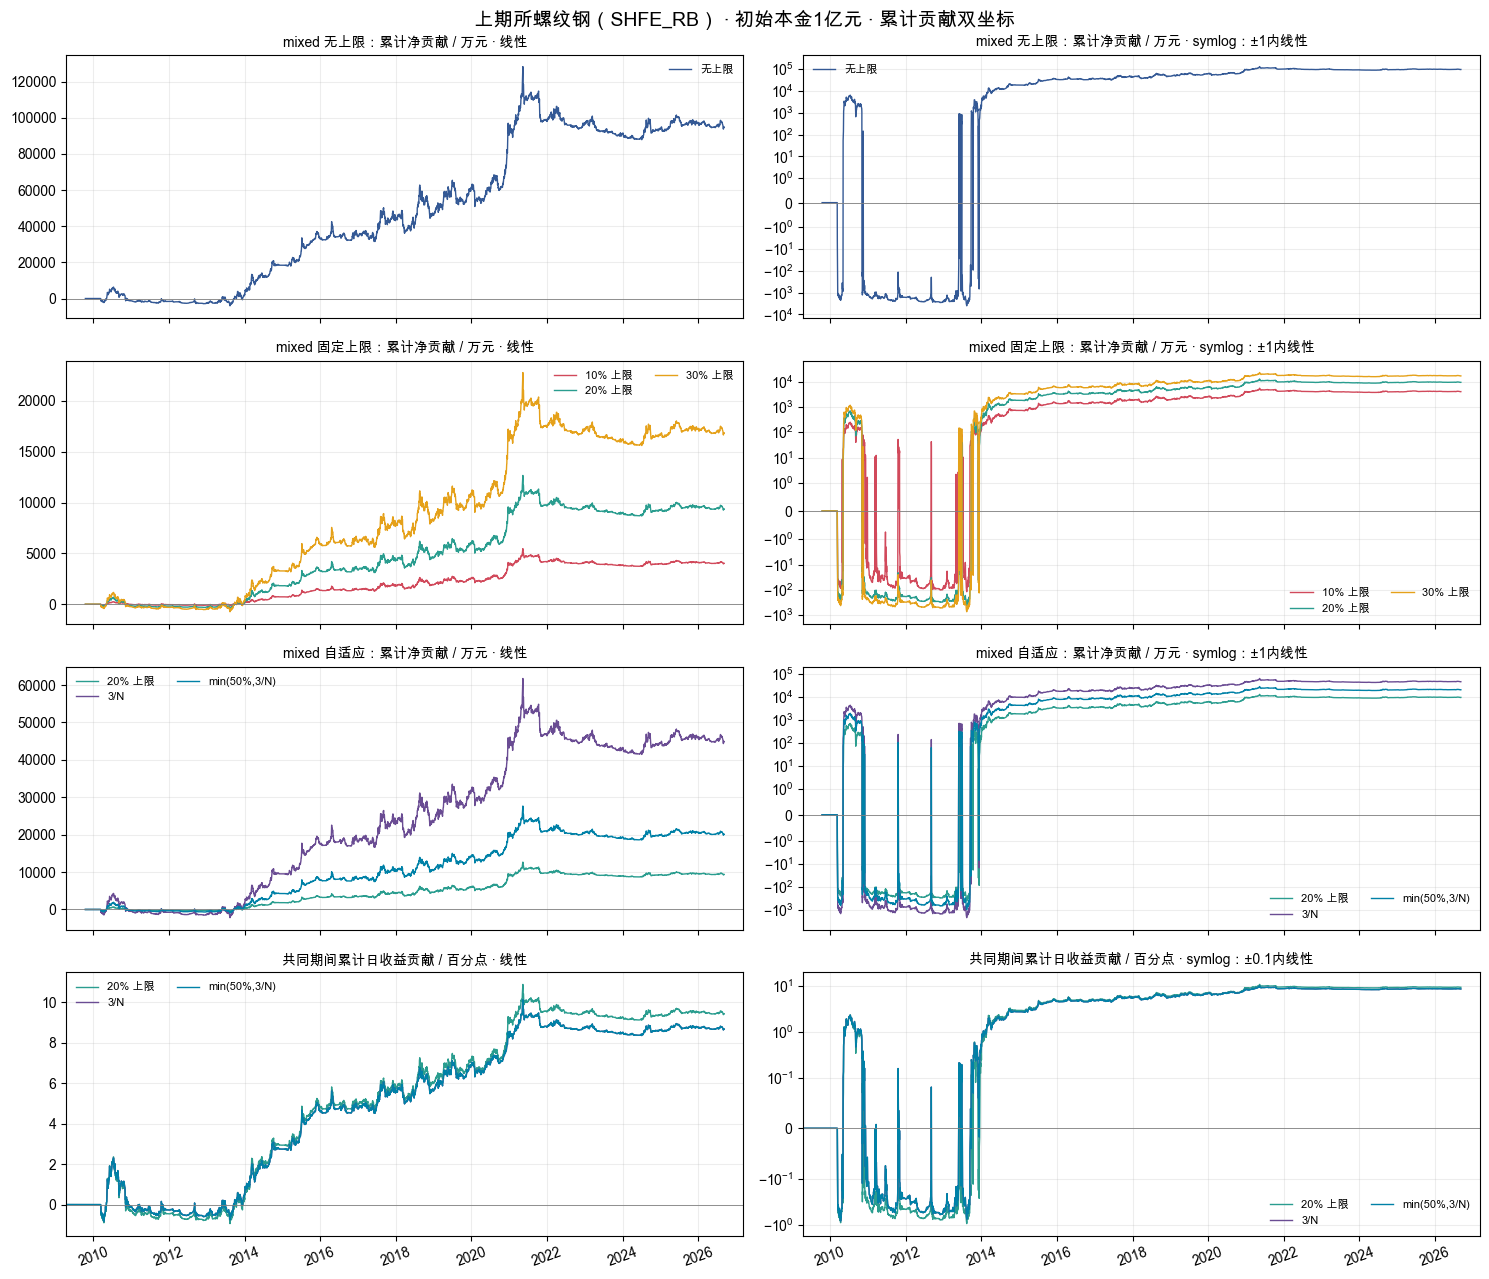

95品种完整图册： /Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/portfolio_capital_100m/instrument_atlas.html


In [116]:
for code in instruments[84:95]:
    plot_instrument(code)
pages = []
for code in instruments:
    name = metadata.loc[code,'Description']
    pages.append(f'<section><h2>{name}（{code}）</h2><img loading="lazy" src="figures/{code}.png"><img loading="lazy" src="figures/{code}_contribution_scales.png"></section>')
html = '<!doctype html><meta charset="utf-8"><title>95品种组合诊断</title><style>body{font-family:system-ui;max-width:1300px;margin:auto}img{width:100%}</style>'+''.join(pages)
(RUN_ROOT/'instrument_atlas.html').write_text(html)
print('95品种完整图册：',RUN_ROOT/'instrument_atlas.html')


## 10. 研究结论

共同可计算历史参与组合，短样本、缺失 carry 与历史边界分别保留诊断。以下结论来自十八组原生账户、共同期间和固定五年分段。

In [106]:
# 结论只引用当前1亿元、v2数据的结果。
mixed = summary.xs(('mixed','共同期间'),level=('strategy','period')).reindex(CAPS)
retained = coverage.index[coverage.decision.eq('纳入')].tolist()
low_vol = coverage.index[coverage.decision.eq('低波动剔除')].tolist()
unavailable = coverage.index[~coverage.decision.isin(['纳入','低波动剔除'])].tolist()
lines = [f'# 单品种敞口研究（{AS_OF}，1亿元）',
    f'18组原生组合；纳入{len(retained)}个品种，低波动剔除{low_vol}，数据不足{unavailable}。',
    '历史资格和低波动门槛为全历史事后诊断。以下为mixed共同期间；各时期明细单列。',
    '|上限|年化平均净收益%|净Sharpe|现金最大回撤%|实际波动率%|',
    '|---|---:|---:|---:|---:|']
for cap,row in mixed.iterrows():
    lines.append(f'|{CAP_LABELS[cap]}|{row.annual_return_pct:.2f}|{row.net_sharpe:.3f}|{row.cash_nav_max_drawdown_pct:.2f}|{row.annual_vol_pct:.2f}|')
lines += [f'当前所有合格历史至少容纳一手所需的最高固定本金为{minimum_capital.required_capital_cnh.max()/10000:.2f}万元。',
    '固定名义上限在早期品种少时影响较大；3/N允许单品种承担更多名义敞口，min(50%,3/N)增加绝对集中度限制。具体收益与回撤变化需结合共同历史、2021年以来和五年分段判断。',
    '订单参与率超过滞后成交量10%及零量/缺失报价日期均在容量表中列出。日线固定成本模型未根据参与率增加冲击成本。',
    'period_data和show_period保留首日原生收益；现金权益、原生资本乘数与年化平均收益分别标识。2026年为不完整年度。',
    '40%carry的CAGR、风险匹配和年度选择结果见独立专题报告。']
report_text = '\n\n'.join(lines).replace('|\n\n|','|\n|')
(RUN_ROOT/'conclusions.md').write_text(report_text,encoding='utf-8')
display(Markdown(report_text))
assert len(portfolio_frames)==18 and run_receipt.status.eq('ok').all()
assert all(hashlib.sha256(Path(path).read_bytes()).hexdigest()==digest for path,digest in input_hashes.items())
import json
receipt = dict(cutoff=AS_OF,initial_capital_cnh=CAPITAL,systems=18,included=len(retained),
    low_vol_excluded=low_vol,unavailable=unavailable,reviewed_windows=len(trading_windows),
    account_failures=len(failure_events),order_violations=int(exposure.order_violations.sum()),
    frozen_inputs_unchanged=True,archived_baselines_required=False)
(RUN_ROOT/'research_receipt.json').write_text(json.dumps(receipt,ensure_ascii=False,indent=2))
print('当前18组结果与冻结输入核验完成。')

# 单品种敞口研究（2026-09-07，1亿元）

18组原生组合；纳入90个品种，低波动剔除['CFFEX_T', 'CFFEX_TF', 'CFFEX_TS']，数据不足['CZCE_JR', 'CZCE_PM']。

历史资格和低波动门槛为全历史事后诊断。以下为mixed共同期间；各时期明细单列。

|上限|年化平均净收益%|净Sharpe|现金最大回撤%|实际波动率%|
|---|---:|---:|---:|---:|
|无上限|18.23|1.570|-20.40|11.61|
|10% 上限|7.87|1.207|-14.18|6.52|
|20% 上限|10.58|1.338|-14.28|7.91|
|30% 上限|12.51|1.420|-14.29|8.81|
|3/N|15.86|1.519|-16.87|10.44|
|min(50%,3/N)|13.22|1.460|-16.79|9.05|

当前所有合格历史至少容纳一手所需的最高固定本金为4540.24万元。

固定名义上限在早期品种少时影响较大；3/N允许单品种承担更多名义敞口，min(50%,3/N)增加绝对集中度限制。具体收益与回撤变化需结合共同历史、2021年以来和五年分段判断。

订单参与率超过滞后成交量10%及零量/缺失报价日期均在容量表中列出。日线固定成本模型未根据参与率增加冲击成本。

period_data和show_period保留首日原生收益；现金权益、原生资本乘数与年化平均收益分别标识。2026年为不完整年度。

40%carry的CAGR、风险匹配和年度选择结果见独立专题报告。

当前18组结果与冻结输入核验完成。
